# Week 13 숙제: Optimizer 비교 실험

## 학습 목표

- SGD / Momentum / RMSProp / Adam 의 **수식을 직접 구현**
- IRIS / MNIST 에서 4 종 optimizer 의 **수렴 속도와 최종 성능** 비교
- 학습률(`lr`) 변화에 대한 **민감도** 측정

## 제출 방법

- 이 노트북을 끝까지 실행한 결과를 저장해서 제출 (채점자가 결과를 추가 실행 없이 확인할 수 있게)
- 코드 빈칸을 모두 채우고
- 마지막 **분석 질문 4 개**에 본인 의견을 작성

---

## 시작 전 확인

`neural_network_v2.py` 가 노트북과 같은 폴더에 있어야 한다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from neural_network_v2 import (
    Network, Dense, ReLU, SoftmaxCE, fit,
    Optimizer,         # base class
)

np.random.seed(0)


---
## Part 1: Optimizer 4 종 직접 구현 (20 점)

`neural_network_v2.py` 의 `Optimizer` base class 를 상속해서 4개 optimizer 를
**직접 구현**한다. 라이브러리의 `SGD/Momentum/RMSProp/Adam` 을 import 하지 **않고**,
수식을 보며 본인이 처음부터 짠다.

### `Optimizer` base class 의 인터페이스

```python
class Optimizer:
    def step(self, net):
        for layer in net.layers:
            for param, grad in layer.params_and_grads():
                self._update(param, grad)

    def _update(self, param, grad):
        raise NotImplementedError
```

- `step(net)` 은 base class 에 이미 구현되어 있음
- **여러분은 `_update(self, param, grad)` 만 override** 하면 됨
- `param` 은 numpy array — `param -= lr * grad` 처럼 **in-place** 로 갱신

### 상태 저장이 필요한 optimizer (Momentum/RMSProp/Adam)

같은 파라미터에 대해 이전 step 의 velocity / 누적 g² 가 필요하다.
`id(param)` 을 key 로 한 dict 로 저장:

```python
self.v = {}
def _update(self, param, grad):
    key = id(param)
    if key not in self.v:
        self.v[key] = np.zeros_like(param)
    # 여기서 self.v[key] 업데이트
```

### 1.1 MySGD (5 점)

$$\theta \leftarrow \theta - \eta \cdot \nabla L$$

In [2]:
class MySGD(Optimizer):
    def __init__(self, lr=0.01):
        self.lr = lr

    def _update(self, param, grad):
        # 구현: SGD update
        param -= self.lr * grad


### 1.2 MyMomentum (5 점)

$$v \leftarrow \mu \cdot v - \eta \cdot \nabla L$$
$$\theta \leftarrow \theta + v$$

In [3]:
class MyMomentum(Optimizer):
    def __init__(self, lr=0.01, mu=0.9):
        self.lr = lr
        self.mu = mu
        self.v = {}   # id(param) → velocity

    def _update(self, param, grad):
        key = id(param)
        if key not in self.v:
            self.v[key] = np.zeros_like(param)
        # 구현: velocity update
        self.v[key] = self.mu * self.v[key] - self.lr * grad
        # 구현: parameter update (in-place)
        param += self.v[key]


### 1.3 MyRMSProp (5 점)

$$s \leftarrow \rho \cdot s + (1-\rho) \cdot g^2$$
$$\theta \leftarrow \theta - \eta \cdot \frac{g}{\sqrt{s} + \epsilon}$$

In [4]:
class MyRMSProp(Optimizer):
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr = lr
        self.rho = rho
        self.eps = eps
        self.s = {}

    def _update(self, param, grad):
        key = id(param)
        if key not in self.s:
            self.s[key] = np.zeros_like(param)
        # 구현: squared-gradient moving average
        self.s[key] = self.rho * self.s[key] + (1 - self.rho) * (grad ** 2)
        # 구현: parameter update (in-place)
        param -= self.lr * grad / (np.sqrt(self.s[key]) + self.eps)


### 1.4 MyAdam (5 점)

$$m \leftarrow \beta_1 \cdot m + (1-\beta_1) \cdot g$$
$$v \leftarrow \beta_2 \cdot v + (1-\beta_2) \cdot g^2$$
$$\hat{m} = m / (1 - \beta_1^t), \quad \hat{v} = v / (1 - \beta_2^t)$$
$$\theta \leftarrow \theta - \eta \cdot \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

**주의**: 시간 step `t` 가 필요. `step()` 호출마다 1 씩 증가하도록 `step` 을 override.

In [5]:
class MyAdam(Optimizer):
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = {}     # 1차 모멘트
        self.v = {}     # 2차 모멘트
        self.t = 0      # time step

    def step(self, net):
        # 구현: time step 증가 후 base optimizer step 호출
        self.t += 1
        super().step(net)

    def _update(self, param, grad):
        key = id(param)
        if key not in self.m:
            self.m[key] = np.zeros_like(param)
            self.v[key] = np.zeros_like(param)
        # 구현: first/second moment update
        self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * grad
        self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (grad ** 2)
        # 구현: bias correction
        m_hat = self.m[key] / (1 - self.beta1 ** self.t)
        v_hat = self.v[key] / (1 - self.beta2 ** self.t)
        # 구현: parameter update (in-place)
        param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


### 1.5 동작 확인 (검증용)

XOR 에서 4개 모두 학습되는지 확인. 1000 epoch 안에 loss < 0.05 가 나와야 정상.

In [6]:
def test_xor(OptCls, name, lr, **kw):
    np.random.seed(0)
    X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
    Y = np.array([[0],[1],[1],[0]], dtype=float)
    from neural_network_v2 import MSELoss
    net = Network()
    net.add(Dense(2, 8, seed=0))
    net.add(ReLU())
    net.add(Dense(8, 1, seed=1))
    loss_fn = MSELoss()
    opt = OptCls(lr=lr, **kw)
    for _ in range(1500):
        pred = net.forward(X)
        l = loss_fn.forward(pred, Y)
        net.backward(loss_fn.backward())
        opt.step(net)
    status = '✓' if l < 0.05 else '✗'
    print(f"{status} {name:10s} (lr={lr}): final loss={l:.4f}")

test_xor(MySGD,      'MySGD',      0.1)
test_xor(MyMomentum, 'MyMomentum', 0.01, mu=0.9)
test_xor(MyRMSProp,  'MyRMSProp',  0.05)
test_xor(MyAdam,     'MyAdam',     0.05)


✓ MySGD      (lr=0.1): final loss=0.0000
✓ MyMomentum (lr=0.01): final loss=0.0000
✓ MyRMSProp  (lr=0.05): final loss=0.0023
✓ MyAdam     (lr=0.05): final loss=0.0000


---
## Part 2: IRIS optimizer 비교 (25 점)

같은 네트워크 (4→16→3), 같은 데이터, 같은 epoch 수에서 4 개 optimizer 의 학습 곡선을 비교.

**공정한 비교를 위해**:
- 매 실험마다 `np.random.seed(0)` 으로 가중치 초기화 고정
- 같은 미니배치 순서를 위해 학습 안에서도 seed 고정

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
Y = np.eye(3)[iris.target]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=iris.target)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (105, 4), Test: (45, 4)


### 2.1 4 종 비교 실험 (15 점)

각 optimizer 의 학습률은 아래 표를 사용 (수업 슬라이드 권장값):

| Optimizer | lr | 기타 |
|-----------|----|------|
| MySGD | 0.05 | |
| MyMomentum | 0.01 | mu=0.9 |
| MyRMSProp | 0.005 | rho=0.9 |
| MyAdam | 0.01 | beta1=0.9, beta2=0.999 |
이 표는 같은 learning rate로 optimizer만 바꾼 순수 비교가 아니라, 과제에서 권장한 optimizer별 lr configuration 비교다. 같은 lr grid에서의 민감도는 Part 4에서 MySGD와 MyAdam을 따로 비교한다.


In [8]:
def train_iris(OptCls, **kw):
    # 구현: Iris optimizer 비교 학습 루프
    # 1) np.random.seed(0)  ← 가중치 초기화 고정
    np.random.seed(0)
    # 2) Network 조립: Dense(4,16) → ReLU → Dense(16,3)
    net = Network()
    net.add(Dense(4, 16))
    net.add(ReLU())
    net.add(Dense(16, 3))
    # 3) loss_fn = SoftmaxCE()
    loss_fn = SoftmaxCE()
    # 4) opt = OptCls(**kw)
    opt = OptCls(**kw)
    # 5) np.random.seed(0)  ← 미니배치 순서 고정
    np.random.seed(0)
    # 6) fit(...) 호출하고 history 반환
    history = fit(net, X_train, Y_train, loss_fn, opt, epochs=100, batch_size=16, verbose=False)
    # 7) test accuracy 계산
    y_pred = net.forward(X_test).argmax(axis=1)
    y_true = Y_test.argmax(axis=1)
    test_acc = np.mean(y_pred == y_true)
    # 반환: (history['loss'], test_acc)
    return history["loss"], test_acc

configs = [
    ('MySGD',      MySGD,      dict(lr=0.05)),
    ('MyMomentum', MyMomentum, dict(lr=0.01, mu=0.9)),
    ('MyRMSProp',  MyRMSProp,  dict(lr=0.005)),
    ('MyAdam',     MyAdam,     dict(lr=0.01)),
]

results = {}
for name, OptCls, kw in configs:
    losses, acc = train_iris(OptCls, **kw)
    results[name] = (losses, acc)
    print(f"{name:11s}  final loss={losses[-1]:.4f}  test_acc={acc:.1%}")


MySGD        final loss=0.0854  test_acc=97.8%
MyMomentum   final loss=0.0574  test_acc=97.8%
MyRMSProp    final loss=0.0505  test_acc=97.8%
MyAdam       final loss=0.0394  test_acc=97.8%


### 2.2 학습 곡선 시각화 (10 점)

4 개 optimizer 의 loss curve 를 한 그림에 그린다. y 축은 log scale.

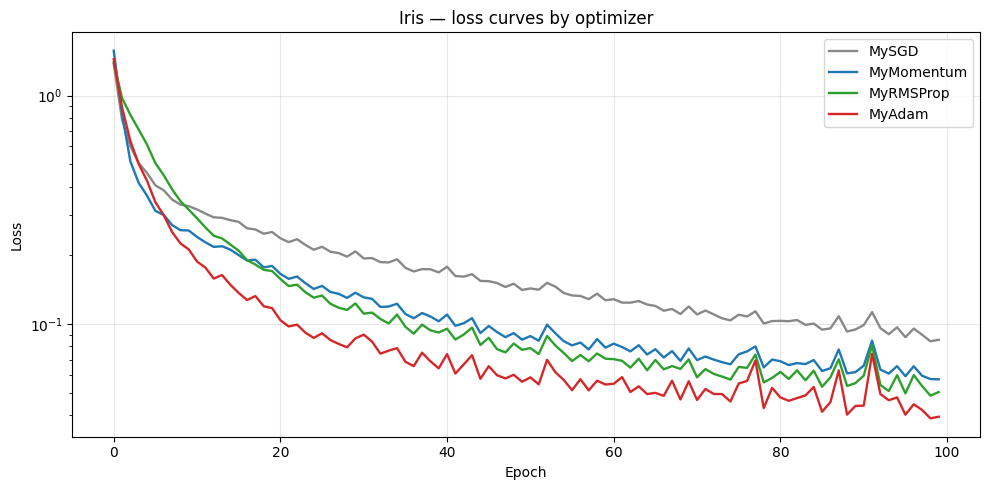

In [9]:
#아래 코드를 이용하거나 별도의 코드를 작성
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'MySGD': '#888', 'MyMomentum': '#1f77b4',
          'MyRMSProp': '#2ca02c', 'MyAdam': '#d62728'}
for name, (losses, _) in results.items():
    ax.plot(losses, label=name, color=colors[name], lw=1.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Iris — loss curves by optimizer')
plt.tight_layout(); plt.show()


---
## Part 3: MNIST optimizer 비교 (25 점)

더 어려운 문제에서 차이가 더 뚜렷해진다. Iris 와 같은 4 종 optimizer 를 MNIST 에서 비교.

> 주의: MNIST cell은 실행 결과를 저장해 제출하며, fresh environment에서는 TensorFlow/Keras MNIST cache 또는 internet access가 필요할 수 있다.

### 3.1 데이터 로드

In [10]:
import os
import sys
from contextlib import contextmanager

# TensorFlow/Keras loader가 CPU/GPU 정보 로그를 stderr에 길게 남기지 않도록 먼저 설정한다.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

@contextmanager
def suppress_stderr_fd():
    try:
        stderr_fd = sys.stderr.fileno()
    except Exception:
        yield
        return
    saved_fd = os.dup(stderr_fd)
    try:
        with open(os.devnull, "w") as devnull:
            os.dup2(devnull.fileno(), stderr_fd)
            yield
    finally:
        os.dup2(saved_fd, stderr_fd)
        os.close(saved_fd)

X = y = None

if X is None:
    try:
        with suppress_stderr_fd():
            from tensorflow.keras.datasets import mnist as keras_mnist
            (X_tr, y_tr), (X_te, y_te) = keras_mnist.load_data()
        X = np.concatenate([X_tr, X_te]).reshape(-1, 784)
        y = np.concatenate([y_tr, y_te])
    except Exception: pass

if X is None:
    try:
        from torchvision import datasets
        root = os.path.expanduser("~/.cache/mnist")
        train = datasets.MNIST(root, train=True,  download=True)
        test  = datasets.MNIST(root, train=False, download=True)
        X = np.concatenate([train.data.numpy(), test.data.numpy()]).reshape(-1, 784)
        y = np.concatenate([train.targets.numpy(), test.targets.numpy()])
    except Exception: pass

if X is None:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data
    y = mnist.target.astype(int)

X = X.astype(np.float32) / 255.0
Y = np.eye(10)[y]

# 빠른 실험을 위해 부분 사용 (학습 8000, 테스트 2000)
n_train, n_test = 8000, 2000
X_train_m = X[:n_train];          Y_train_m = Y[:n_train]
X_test_m  = X[60000:60000+n_test]; Y_test_m  = Y[60000:60000+n_test]
print(f"MNIST train: {X_train_m.shape}, test: {X_test_m.shape}")


MNIST train: (8000, 784), test: (2000, 784)


### 3.2 4 종 비교 학습 (15 점)

네트워크: 784 → 64 → 32 → 10 (작게 잡아 학습 시간 단축).
각 optimizer 5 epoch 만 돌려도 차이가 보임.

In [11]:
def train_mnist(OptCls, **kw):
    # 구현: MNIST optimizer 비교 학습 루프
    #   Dense(784, 64) → ReLU → Dense(64, 32) → ReLU → Dense(32, 10)
    np.random.seed(0)
    net = Network()
    net.add(Dense(784, 64))
    net.add(ReLU())
    net.add(Dense(64, 32))
    net.add(ReLU())
    net.add(Dense(32, 10))
    loss_fn = SoftmaxCE()
    opt = OptCls(**kw)
    np.random.seed(0)
    # epochs=5, batch_size=64 권장
    history = fit(net, X_train_m, Y_train_m, loss_fn, opt, epochs=5, batch_size=64, verbose=False)
    y_pred = net.forward(X_test_m).argmax(axis=1)
    y_true = Y_test_m.argmax(axis=1)
    test_acc = np.mean(y_pred == y_true)
    # 반환: (history['loss'], test_acc)
    return history["loss"], test_acc

mnist_configs = [
    ('MySGD',      MySGD,      dict(lr=0.01)),
    ('MyMomentum', MyMomentum, dict(lr=0.005, mu=0.9)),
    ('MyRMSProp',  MyRMSProp,  dict(lr=0.001)),
    ('MyAdam',     MyAdam,     dict(lr=0.001)),
]

import time
mnist_results = {}
for name, OptCls, kw in mnist_configs:
    t0 = time.time()
    losses, acc = train_mnist(OptCls, **kw)
    mnist_results[name] = (losses, acc)
    print(f"{name:11s}  final loss={losses[-1]:.4f}  test_acc={acc:.1%}  ({time.time()-t0:.1f}s)")


MySGD        final loss=0.4785  test_acc=83.4%  (0.5s)


MyMomentum   final loss=0.2426  test_acc=89.1%  (0.5s)


MyRMSProp    final loss=0.1566  test_acc=90.7%  (0.6s)


MyAdam       final loss=0.1509  test_acc=90.5%  (0.6s)


### 3.3 결과 시각화 (10 점)

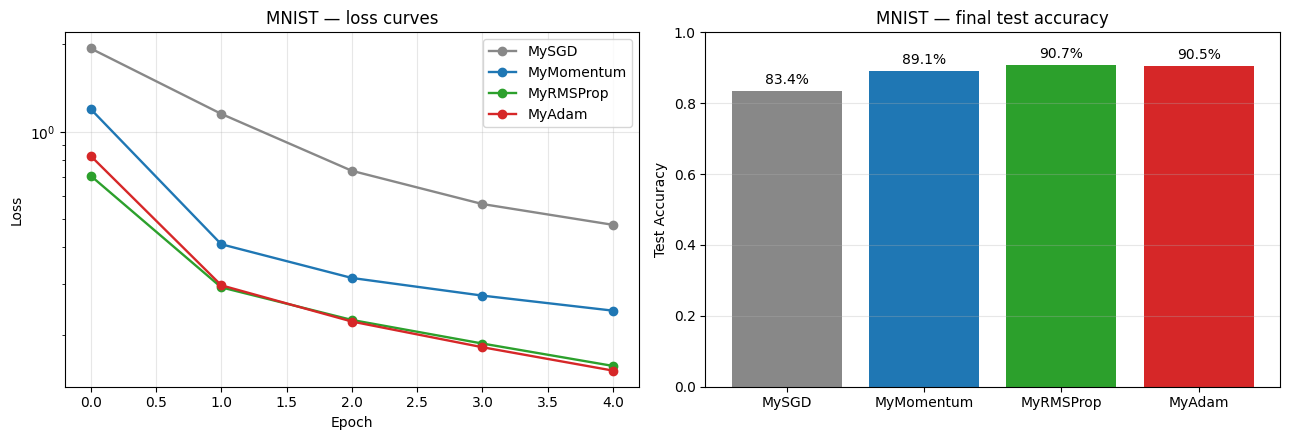

In [12]:
#아래 코드를 이용하거나 별도의 코드를 작성
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = {'MySGD': '#888', 'MyMomentum': '#1f77b4',
          'MyRMSProp': '#2ca02c', 'MyAdam': '#d62728'}

for name, (losses, _) in mnist_results.items():
    axes[0].plot(losses, 'o-', label=name, color=colors[name], lw=1.7)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('MNIST — loss curves')

names = list(mnist_results.keys())
accs  = [mnist_results[n][1] for n in names]
axes[1].bar(names, accs, color=[colors[n] for n in names])
axes[1].set_ylabel('Test Accuracy'); axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.3, axis='y')
axes[1].set_title('MNIST — final test accuracy')
for i, a in enumerate(accs):
    axes[1].text(i, a + 0.02, f'{a:.1%}', ha='center')
plt.tight_layout(); plt.show()


---
## Part 4: 학습률 민감도 (10 점)

같은 optimizer 라도 학습률에 따라 결과가 크게 달라진다.
**Adam** vs **SGD** 의 학습률 민감도를 비교한다.

각 optimizer 를 학습률 4개 (`1e-4, 1e-3, 1e-2, 1e-1`) 로 IRIS 학습. 최종 test accuracy 를 plot.

lr=0.0001  MySGD=42.2%  MyAdam=44.4%


lr=0.001  MySGD=68.9%  MyAdam=95.6%
lr=0.01  MySGD=91.1%  MyAdam=97.8%
lr=0.1  MySGD=97.8%  MyAdam=97.8%


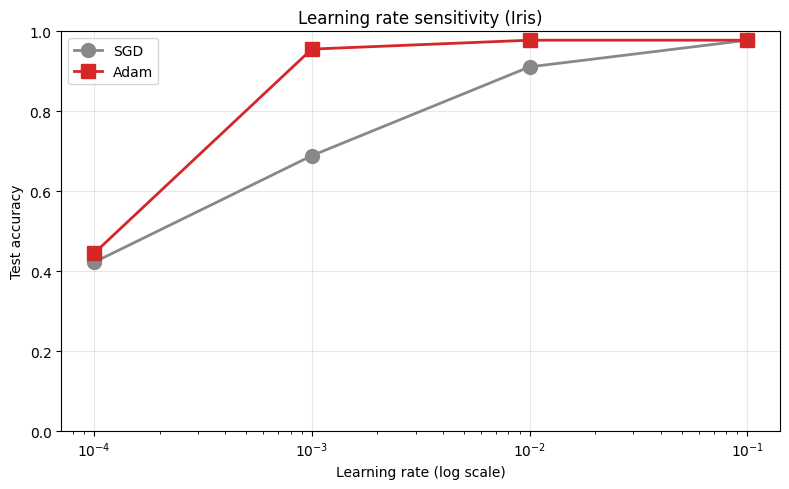

In [13]:
lrs = [1e-4, 1e-3, 1e-2, 1e-1]

# 구현: 각 lr에 대해 MySGD와 MyAdam test_acc 수집
# (Part 2 의 train_iris 사용)
sgd_accs = []
adam_accs = []
for lr in lrs:
    _, sgd_acc = train_iris(MySGD, lr=lr)
    _, adam_acc = train_iris(MyAdam, lr=lr)
    sgd_accs.append(sgd_acc)
    adam_accs.append(adam_acc)
    print(f"lr={lr:g}  MySGD={sgd_acc:.1%}  MyAdam={adam_acc:.1%}")

# 구현: x축 lr(log scale), y축 test accuracy plot
# 아래 코드를 이용하거나 별도의 코드 작성
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(lrs, sgd_accs,  'o-', label='SGD',  color='#888', lw=2, ms=10)
ax.semilogx(lrs, adam_accs, 's-', label='Adam', color='#d62728', lw=2, ms=10)
ax.set_xlabel('Learning rate (log scale)')
ax.set_ylabel('Test accuracy')
ax.set_title('Learning rate sensitivity (Iris)')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()


---
### Experiment Protocol Note

This notebook keeps the original homework protocol for official grading. Official Part 2 and Part 3 report test accuracy because the homework requires it. For research interpretation, optimizer/lr selection should be based on validation curves, and test should be used only once after model choice. Therefore, the Appendix provides validation-only diagnostics and split-before-fit checks, but these do not replace the official homework results. Official Iris preprocessing follows the homework scaffold, but methodologically scaler fitting should be done on train only.

### Problem Design Summary

| Dataset | X shape | y / Y shape | Task | Output layer | Loss | Metric |
|---|---:|---:|---|---|---|---|
| Iris | `(150, 4)` raw, `(105, 4)` train, `(45, 4)` test | `(150, 3)` one-hot | 3-class classification | `Dense(16, 3)` logits | `SoftmaxCE` | accuracy |
| MNIST subset | `(8000, 784)` train, `(2000, 784)` test | `(8000, 10)` train one-hot, `(2000, 10)` test one-hot | 10-class classification | `Dense(32, 10)` logits | `SoftmaxCE` | accuracy |

### Optimizer Comparison Scope

The Part 2/3 comparison is not a pure same-lr optimizer comparison. It compares the homework-recommended configuration for each optimizer. Part 4 separately checks lr sensitivity for MySGD and MyAdam under the same lr grid. Optimizer responsibility is also separated from data/loss responsibility: `X` and `Y` create logits, loss, and gradients through forward/backward, while `Optimizer.step(net)` reads only `(param, grad)` from layers and updates parameters in-place.

## Part 5: 분석 (간단 서술, 각 5 점 — 총 20 점)

위 실험 결과를 보고 다음 4 개 질문에 본인 의견을 작성하세요.
정답이 정해진 문제가 아니며, **그래프에서 근거를 찾아** 설명하면 됩니다.

### Q1. SGD vs Adam — 어느 쪽이 더 빨리 수렴했는가? IRIS 와 MNIST 그래프에서 본 차이는?

> 관찰: Iris에서는 네 optimizer의 test accuracy가 모두 97.8%로 포화되어 accuracy만으로 수렴 속도를 구분할 수 없다. 다만 같은 epoch budget 이후 final cross-entropy loss는 Adam이 0.0394로 가장 낮았고 SGD가 0.0854로 가장 높았다. 따라서 이 실험 조건에서는 Adam이 loss를 더 효율적으로 낮춘 것으로 해석할 수 있다. MNIST subset에서는 RMSProp과 Adam이 SGD보다 높은 test accuracy와 낮은 loss를 보였으므로 adaptive 계열이 더 유리했다.
>
> 원인: SGD는 현재 gradient에 learning rate를 곱해 바로 이동하므로 feature scale과 curvature 영향을 크게 받는다. Adam은 first moment와 second moment를 사용해 좌표별 effective step을 조절하므로 같은 epoch budget에서 loss를 더 효율적으로 줄일 수 있다.
>
> 제한: 빠른 수렴을 엄밀히 주장하려면 threshold 도달 epoch, loss AUC, early epoch loss를 따로 비교해야 한다. Iris는 쉬운 데이터라 accuracy가 포화되고, MNIST는 train 8000/test 2000 subset을 5 epoch만 사용한 조건이므로 일반적인 optimizer 우열을 단정할 수는 없다.
>
> 결론: 이 실험에서는 Adam이 “가장 빠르게 수렴했다”고 단정하기보다, Iris fixed epoch budget에서 final loss를 가장 낮게 만든 optimizer로 해석하겠다. MNIST subset에서는 RMSProp과 Adam이 거의 비슷하게 강하며 SGD보다 우세했다.

### Q2. 같은 lr=0.1 을 줬을 때 SGD 와 Adam 중 어느 쪽이 더 잘 작동했는가? 왜?

> 관찰: Part 4에서 lr=0.1일 때 MySGD와 MyAdam 모두 Iris test accuracy 97.8%에 도달했다. 따라서 이 지점만 보면 정확도 차이는 없다.
>
> 원인: Iris는 class separation이 비교적 쉬워 큰 learning rate에서도 최종 accuracy가 포화될 수 있다. 하지만 SGD는 step이 `-lr * grad`로 직접 정해져 큰 lr에서 흔들릴 가능성이 크고, Adam은 gradient moment로 step scale을 조절해 큰 lr의 영향을 일부 완충한다.
>
> 제한: test accuracy 하나만 보면 loss curve의 안정성, overshoot, update norm 차이를 놓친다. Iris 한 split의 결과이므로 일반화된 결론도 아니다.
>
> 결론: lr=0.1의 최종 accuracy는 동률이지만, 새 문제에서는 loss curve와 validation 안정성까지 함께 보고 Adam 쪽을 더 안전한 초기 후보로 보겠다.

### Q3. Adam 은 학습률 변화에 둔감하다고 알려져 있다. Part 4 의 그래프가 이 주장을 지지하는가?

> 관찰: Part 4에서 lr=0.001일 때 MyAdam은 95.6%까지 올라가지만 MySGD는 68.9%에 머문다. lr=0.01과 0.1에서도 Adam은 높은 성능을 유지한다. 다만 lr=0.0001에서는 Adam도 44.4%로 낮다.
>
> 원인: Adam은 gradient의 1차/2차 이동평균을 사용해 좌표별 step 크기를 조절하므로 SGD보다 learning rate 변화에 덜 민감하게 보일 수 있다.
>
> 제한: 실험한 lr 후보가 네 개뿐이고 Iris 하나만 본 결과다. 또한 sensitivity range는 MySGD 0.5556, MyAdam 0.5333으로 큰 차이는 아니므로 강한 증거라고 보기는 어렵다.
>
> 결론: Part 4는 Adam이 SGD보다 learning rate 변화에 약간 더 안정적인 경향을 보여주지만, 동시에 Adam도 lr tuning이 필요하다는 점을 보여준다.

### Q4. 만약 본인이 새 문제를 풀어야 한다면 어떤 optimizer 부터 시도해보겠는가? 왜?

> 관찰: Iris에서는 accuracy가 동률이라 loss와 diagnostics를 함께 봐야 했고, MNIST에서는 RMSProp과 Adam이 SGD/Momentum보다 좋은 결과를 보였다. Dense2 뒤 ReLU ablation처럼 architecture 선택도 loss geometry에 큰 영향을 줄 수 있었다.
>
> 원인: Adam은 초반 수렴이 빠르고 learning rate 변화에 비교적 안정적이며, 별도 튜닝이 부족한 초기 baseline에서 강하다. 하지만 데이터 구조, scaling, batch size, output activation placement에 따라 RMSProp이나 Momentum이 더 나을 수 있다.
>
> 제한: test set을 optimizer 선택에 반복 사용하면 leakage가 된다. 또한 official Iris preprocessing은 homework scaffold를 유지했지만, 방법론적으로 scaler fitting은 train에서만 하고 validation/test에는 transform만 적용해야 한다. 따라서 연구형 결론에서는 train으로 학습하고 validation으로 optimizer/lr를 고른 뒤 test는 마지막에 한 번만 사용해야 한다.
>
> 결론: 새 문제에서는 먼저 Adam으로 baseline을 만들고, validation 기준으로 RMSProp/Momentum/SGD를 추가 비교하겠다. 최종 선택은 test accuracy가 아니라 validation loss, macro-F1, confusion matrix, loss curve 안정성을 함께 보고 결정하겠다. Official 결과와 research-grade protocol의 차이는 Appendix의 validation-only diagnostics와 split-before-fit check로 분리해 확인했다.

---

## 채점 기준 (총 100 점)

| 항목 | 배점 |
|------|------|
| Part 1: Optimizer 4 종 구현 | 20 |
| Part 2: IRIS 비교 + 시각화 | 25 |
| Part 3: MNIST 비교 + 시각화 | 25 |
| Part 4: 학습률 민감도 | 10 |
| Part 5: 분석 질문 4 개 | 20  |


---
## [INSERTED] Appendix: research diagnostics and evidence boards

위 28개 cell은 원본 homework 공식 제출 흐름이다. 아래 Appendix는 연구형 진단과 시각화 근거이며, 공식 Part 1~5 요구사항을 대체하지 않는다.


## [INSERTED] SSOT and no-rewrite contract

- `week13_homework (1).ipynb`를 SSOT로 고정했다.
- 원본 Part 순서, heading, markdown table, scoring table, 질문 문구, code cell 위치는 보존한다.
- 원본 scaffold code cell은 구현 위치만 채웠고, 원본 signature/config/plot skeleton은 유지한다.
- 이 노트북의 `[INSERTED]` cell은 보조 연구·진단 확장이다. 원본 Part 1~5 공식 결과를 대체하지 않는다.
- 연구 확장에서는 validation/test 분리와 split-before-fit 원칙을 별도로 설명하지만, 원본 homework가 요구한 official test accuracy 산출은 원문 구조를 따른다.


## [INSERTED] Optimizer responsibility audit

이 확장 cell은 Part 1 구현이 `Optimizer.step(net)` 책임을 지키는지 확인한다. Optimizer는 `X`와 `y`를 직접 보지 않고, 각 layer의 `params_and_grads()`가 내보내는 `W, b, dW, db`만 읽어 in-place update를 수행한다.


,optimizer,loss_before_step,param_grad_pairs,param_norm,grad_norm,update_norm,state_dict_sizes,optimizer_reads_X_y_directly
0,MySGD,0.376016,4,4.073706,0.989027,0.098903,no state dict,False
1,MyMomentum,0.376016,4,4.073706,0.989027,0.009890,v:4,False
2,MyRMSProp,0.376016,4,4.073706,0.989027,0.418330,s:4,False
3,MyAdam,0.376016,4,4.073706,0.989027,0.132288,v:4; m:4,False


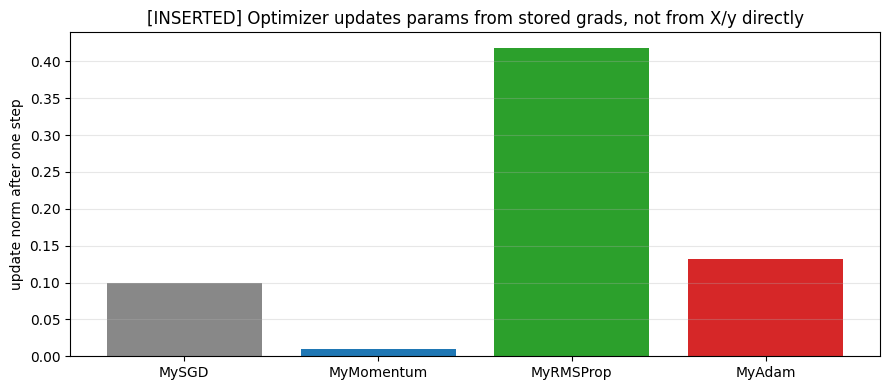

In [14]:
# [INSERTED] Optimizer responsibility audit
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd
import json

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
config_dir_ext = artifact_root_ext / "configs"
for _d_ext in [artifact_root_ext, fig_dir_ext, csv_dir_ext, config_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

from neural_network_v2 import MSELoss

optimizer_audit_rows_ext = []
X_audit_ext = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
Y_audit_ext = np.array([[0], [1], [1], [0]], dtype=float)

def flatten_params_ext(net_ext):
    chunks_ext = []
    for layer_ext in net_ext.layers:
        for param_ext, _ in layer_ext.params_and_grads():
            chunks_ext.append(param_ext.ravel())
    return np.concatenate(chunks_ext) if chunks_ext else np.array([])

for opt_name_ext, OptCls_ext, kw_ext in [
    ("MySGD", MySGD, dict(lr=0.1)),
    ("MyMomentum", MyMomentum, dict(lr=0.01, mu=0.9)),
    ("MyRMSProp", MyRMSProp, dict(lr=0.05)),
    ("MyAdam", MyAdam, dict(lr=0.05)),
]:
    np.random.seed(123)
    net_audit_ext = Network()
    net_audit_ext.add(Dense(2, 4, seed=2))
    net_audit_ext.add(ReLU())
    net_audit_ext.add(Dense(4, 1, seed=3))
    loss_audit_ext = MSELoss()
    opt_audit_ext = OptCls_ext(**kw_ext)
    pred_audit_ext = net_audit_ext.forward(X_audit_ext)
    loss_value_ext = loss_audit_ext.forward(pred_audit_ext, Y_audit_ext)
    net_audit_ext.backward(loss_audit_ext.backward())
    before_params_ext = flatten_params_ext(net_audit_ext).copy()
    grad_chunks_ext = []
    param_chunks_ext = []
    pair_count_ext = 0
    for layer_ext in net_audit_ext.layers:
        for param_ext, grad_ext in layer_ext.params_and_grads():
            pair_count_ext += 1
            grad_chunks_ext.append(grad_ext.ravel())
            param_chunks_ext.append(param_ext.ravel())
    grad_vec_ext = np.concatenate(grad_chunks_ext)
    param_vec_ext = np.concatenate(param_chunks_ext)
    opt_audit_ext.step(net_audit_ext)
    after_params_ext = flatten_params_ext(net_audit_ext).copy()
    update_vec_ext = after_params_ext - before_params_ext
    state_keys_ext = []
    for attr_ext in ["v", "s", "m"]:
        obj_ext = getattr(opt_audit_ext, attr_ext, None)
        if isinstance(obj_ext, dict):
            state_keys_ext.append(f"{attr_ext}:{len(obj_ext)}")
    optimizer_audit_rows_ext.append({
        "optimizer": opt_name_ext,
        "loss_before_step": float(loss_value_ext),
        "param_grad_pairs": pair_count_ext,
        "param_norm": float(np.linalg.norm(param_vec_ext)),
        "grad_norm": float(np.linalg.norm(grad_vec_ext)),
        "update_norm": float(np.linalg.norm(update_vec_ext)),
        "state_dict_sizes": "; ".join(state_keys_ext) if state_keys_ext else "no state dict",
        "optimizer_reads_X_y_directly": False,
    })

optimizer_audit_df_ext = pd.DataFrame(optimizer_audit_rows_ext)
display(optimizer_audit_df_ext)
optimizer_audit_df_ext.to_csv(csv_dir_ext / "optimizer_responsibility_audit.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(optimizer_audit_df_ext["optimizer"], optimizer_audit_df_ext["update_norm"], color=["#888", "#1f77b4", "#2ca02c", "#d62728"])
ax.set_ylabel("update norm after one step")
ax.set_title("[INSERTED] Optimizer updates params from stored grads, not from X/y directly")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir_ext / "optimizer_responsibility_update_norm.png", dpi=160)
plt.show()


## [INSERTED] Optimizer visualization candidate map

이 보드는 optimizer가 등장하는 모든 파트에서 어떤 시각화를 쓸 수 있는지 후보군을 정리한다. 원본 공식 실험을 바꾸지 않고, 각 후보가 어떤 질문을 해결하는지와 3D로 확장할 때 어떤 축을 써야 하는지 명시한다.

핵심 원칙은 다음이다.

```text
Layer/Network는 forward/backward로 prediction, loss, gradient를 만든다.
Optimizer는 X/y를 직접 보지 않는다.
Optimizer는 param과 grad를 읽고 update rule/state로 param을 움직인다.
```


In [15]:
# [INSERTED] Optimizer visualization candidate map
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: optimizer 관련 모든 파트에서 어떤 시각화를 쓸 수 있는지 후보군을 일목요연하게 정리한다.
# 원본 과제 요구사항을 바꾸지 않고, 각 후보가 어떤 학습 질문에 답하는지 명시한다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
csv_dir_ext = artifact_root_ext / "csv"
csv_dir_ext.mkdir(parents=True, exist_ok=True)

# [코드 해설 | optimizer_visual_candidate_ext]
# row 하나가 하나의 파트/시각화 후보군이다.
# 3D axes column은 실제 3D로 만들 때 무엇을 x/y/z로 둘지 적는다.
# status는 이미 구현했는지, 또는 notebook 안정성을 위해 후보로만 남겼는지 구분한다.
optimizer_visual_candidate_ext = pd.DataFrame([
    ["Part 1", "optimizer responsibility", "param/update norm bar + state dict table", "param index or optimizer / grad-update scale / state size", "optimizer가 X/y가 아니라 param/grad만 읽는가", "implemented"],
    ["Part 1", "one-step update geometry", "single-step arrow on tiny 2D parameter plane", "w0 / w1 / loss or update norm", "SGD/Momentum/RMSProp/Adam이 같은 grad를 첫 step에서 어떻게 다르게 쓰는가", "candidate"],
    ["Part 2", "Iris optimizer comparison", "loss curve + final loss delta bar + CE boxplot", "epoch / optimizer / loss or per-sample CE", "accuracy가 포화될 때 loss/CE로 차이를 어떻게 읽는가", "implemented + scoped"],
    ["Part 2", "Iris decision-space", "PCA 2D/3D decision-space with correct/wrong overlay", "PC1 / PC2 / PC3", "test/validation 오류가 feature geometry 어디에서 생기는가", "candidate extension-only"],
    ["Part 3", "MNIST optimizer comparison", "loss curve + zoomed final-accuracy bar + per-class bar", "epoch or class / optimizer / accuracy", "짧은 epoch budget에서 optimizer별 차이가 어느 class에서 드러나는가", "implemented + scoped"],
    ["Part 4", "LR sensitivity", "semilog curve + delta bar + 3D surface trajectory", "w0 / w1 / loss", "학습률 차이가 update norm과 overshoot를 어떻게 바꾸는가", "implemented"],
    ["V04-style", "optimizer multi-view", "3D surface, top contour, front w0-loss, side w1-loss", "w0 / w1 / L(w)", "같은 surface와 시작점에서 update rule/state가 path를 어떻게 갈라놓는가", "implemented"],
    ["V05-style", "gradient-flow audit", "grad norm line + update/param ratio line + ReLU gate line/box", "epoch / dense layer / diagnostic value", "loss curve의 원인을 dW/db와 실제 update 크기로 설명할 수 있는가", "implemented"],
    ["V05-style", "Dense2 ReLU placement", "loss/accuracy curves + score distribution + zero-ratio bar", "epoch or score / variant / metric", "출력층 ReLU가 class score geometry를 어떻게 제한하는가", "implemented"],
    ["Part 5", "answer evidence board", "question-evidence-caution table", "question / evidence / conclusion", "그래프를 관찰-원인-제한-결론 답안으로 바꿀 수 있는가", "implemented"],
], columns=["part", "optimizer-related focus", "visual candidate", "3D axes if applicable", "question answered", "status"])
display(optimizer_visual_candidate_ext)
optimizer_visual_candidate_ext.to_csv(csv_dir_ext / "optimizer_visualization_candidate_map_ext.csv", index=False)

# [해석 후보군 | 3D view를 어떻게 설계할 것인가]
# 3D가 필요한 곳과 불필요한 곳을 분리한다. 모든 plot을 3D로 만들면 오히려 해석력이 떨어진다.
optimizer_3d_design_ext = pd.DataFrame([
    ["synthetic quadratic", "w0", "w1", "loss L(w)", "optimizer path를 표면 위에 얹는다", "공간감, valley, overshoot 후보"],
    ["top contour", "w0", "w1", "contour color", "3D를 위에서 눌러 본다", "zig-zag와 overshoot를 가장 선명하게 본다"],
    ["front projection", "w0", "loss", "optimizer color", "w1을 버린다", "완만한 축 w0의 진척을 본다"],
    ["side projection", "w1", "loss", "optimizer color", "w0를 버린다", "가파른 축 w1의 초반 감소/진동을 본다"],
    ["parameter PCA candidate", "PC1(param)", "PC2(param)", "loss", "고차원 parameter를 PCA로 2D 압축한다", "실제 network trajectory 후보이지만 계산/저장 비용이 큼"],
], columns=["3D/camera design", "x axis", "y axis", "z or color", "how to build", "why/when useful"])
display(optimizer_3d_design_ext)
optimizer_3d_design_ext.to_csv(csv_dir_ext / "optimizer_3d_design_candidates_ext.csv", index=False)


,part,optimizer-related focus,visual candidate,3D axes if applicable,question answered,status
0,Part 1,optimizer responsibility,param/update norm bar + state dict table,param index or optimizer / grad-update scale /...,optimizer가 X/y가 아니라 param/grad만 읽는가,implemented
1,Part 1,one-step update geometry,single-step arrow on tiny 2D parameter plane,w0 / w1 / loss or update norm,SGD/Momentum/RMSProp/Adam이 같은 grad를 첫 step에서 어...,candidate
2,Part 2,Iris optimizer comparison,loss curve + final loss delta bar + CE boxplot,epoch / optimizer / loss or per-sample CE,accuracy가 포화될 때 loss/CE로 차이를 어떻게 읽는가,implemented + scoped
3,Part 2,Iris decision-space,PCA 2D/3D decision-space with correct/wrong ov...,PC1 / PC2 / PC3,test/validation 오류가 feature geometry 어디에서 생기는가,candidate extension-only
4,Part 3,MNIST optimizer comparison,loss curve + zoomed final-accuracy bar + per-c...,epoch or class / optimizer / accuracy,짧은 epoch budget에서 optimizer별 차이가 어느 class에서 드러나는가,implemented + scoped
5,Part 4,LR sensitivity,semilog curve + delta bar + 3D surface trajectory,w0 / w1 / loss,학습률 차이가 update norm과 overshoot를 어떻게 바꾸는가,implemented
6,V04-style,optimizer multi-view,"3D surface, top contour, front w0-loss, side w...",w0 / w1 / L(w),같은 surface와 시작점에서 update rule/state가 path를 어떻게...,implemented
7,V05-style,gradient-flow audit,grad norm line + update/param ratio line + ReL...,epoch / dense layer / diagnostic value,loss curve의 원인을 dW/db와 실제 update 크기로 설명할 수 있는가,implemented
8,V05-style,Dense2 ReLU placement,loss/accuracy curves + score distribution + ze...,epoch or score / variant / metric,출력층 ReLU가 class score geometry를 어떻게 제한하는가,implemented
9,Part 5,answer evidence board,question-evidence-caution table,question / evidence / conclusion,그래프를 관찰-원인-제한-결론 답안으로 바꿀 수 있는가,implemented


,3D/camera design,x axis,y axis,z or color,how to build,why/when useful
0,synthetic quadratic,w0,w1,loss L(w),optimizer path를 표면 위에 얹는다,"공간감, valley, overshoot 후보"
1,top contour,w0,w1,contour color,3D를 위에서 눌러 본다,zig-zag와 overshoot를 가장 선명하게 본다
2,front projection,w0,loss,optimizer color,w1을 버린다,완만한 축 w0의 진척을 본다
3,side projection,w1,loss,optimizer color,w0를 버린다,가파른 축 w1의 초반 감소/진동을 본다
4,parameter PCA candidate,PC1(param),PC2(param),loss,고차원 parameter를 PCA로 2D 압축한다,실제 network trajectory 후보이지만 계산/저장 비용이 큼


## [INSERTED] Virtual 3D optimizer contour analysis

이 확장 cell은 Part 1 직후에 optimizer 비교분석의 공간감을 먼저 잡기 위한 가상 실험이다. 실제 Iris/MNIST parameter는 수백~수천 차원이지만, 여기서는 대표 축 `w0`, `w1`, `w2` 세 개만 잡아 anisotropic quadratic loss를 만든다.

```text
3D parameter path:
세 optimizer가 같은 시작점과 같은 loss/gradient 함수를 쓰지만 update rule/state 때문에 다른 경로를 밟는지 본다.

contour slice:
w0-w1, w0-w2, w1-w2 평면으로 잘라서 어느 축에서 zig-zag, overshoot, slow drift가 생기는지 본다.

evaluation table:
final_loss, path_length, overshoot_count, gradient/update norm을 표로 비교한다.
```

주의: 이것은 실제 Iris loss surface가 아니다. 고차원 optimizer 동작을 이해하기 위한 `3D surrogate loss geometry`이며, 하단 V04 dashboard의 수치해석을 초반부에서 미리 읽게 하는 bridge다.


,optimizer,start_loss,final_loss,loss_drop_ratio,final_distance_to_origin,path_length_3d,max_update_norm,mean_grad_norm,overshoot_count_loss_increase
1,Momentum,12.7721,0.005271,0.999587,0.136949,13.910064,1.001571,1.731060,22
0,SGD,12.7721,0.192473,0.984930,1.797365,7.006806,1.818174,0.719351,0
3,Adam,12.7721,0.199644,0.984369,1.529728,5.898985,0.181865,2.385507,0
2,RMSProp,12.7721,0.258842,0.979734,2.068047,5.006764,0.410792,1.958052,0


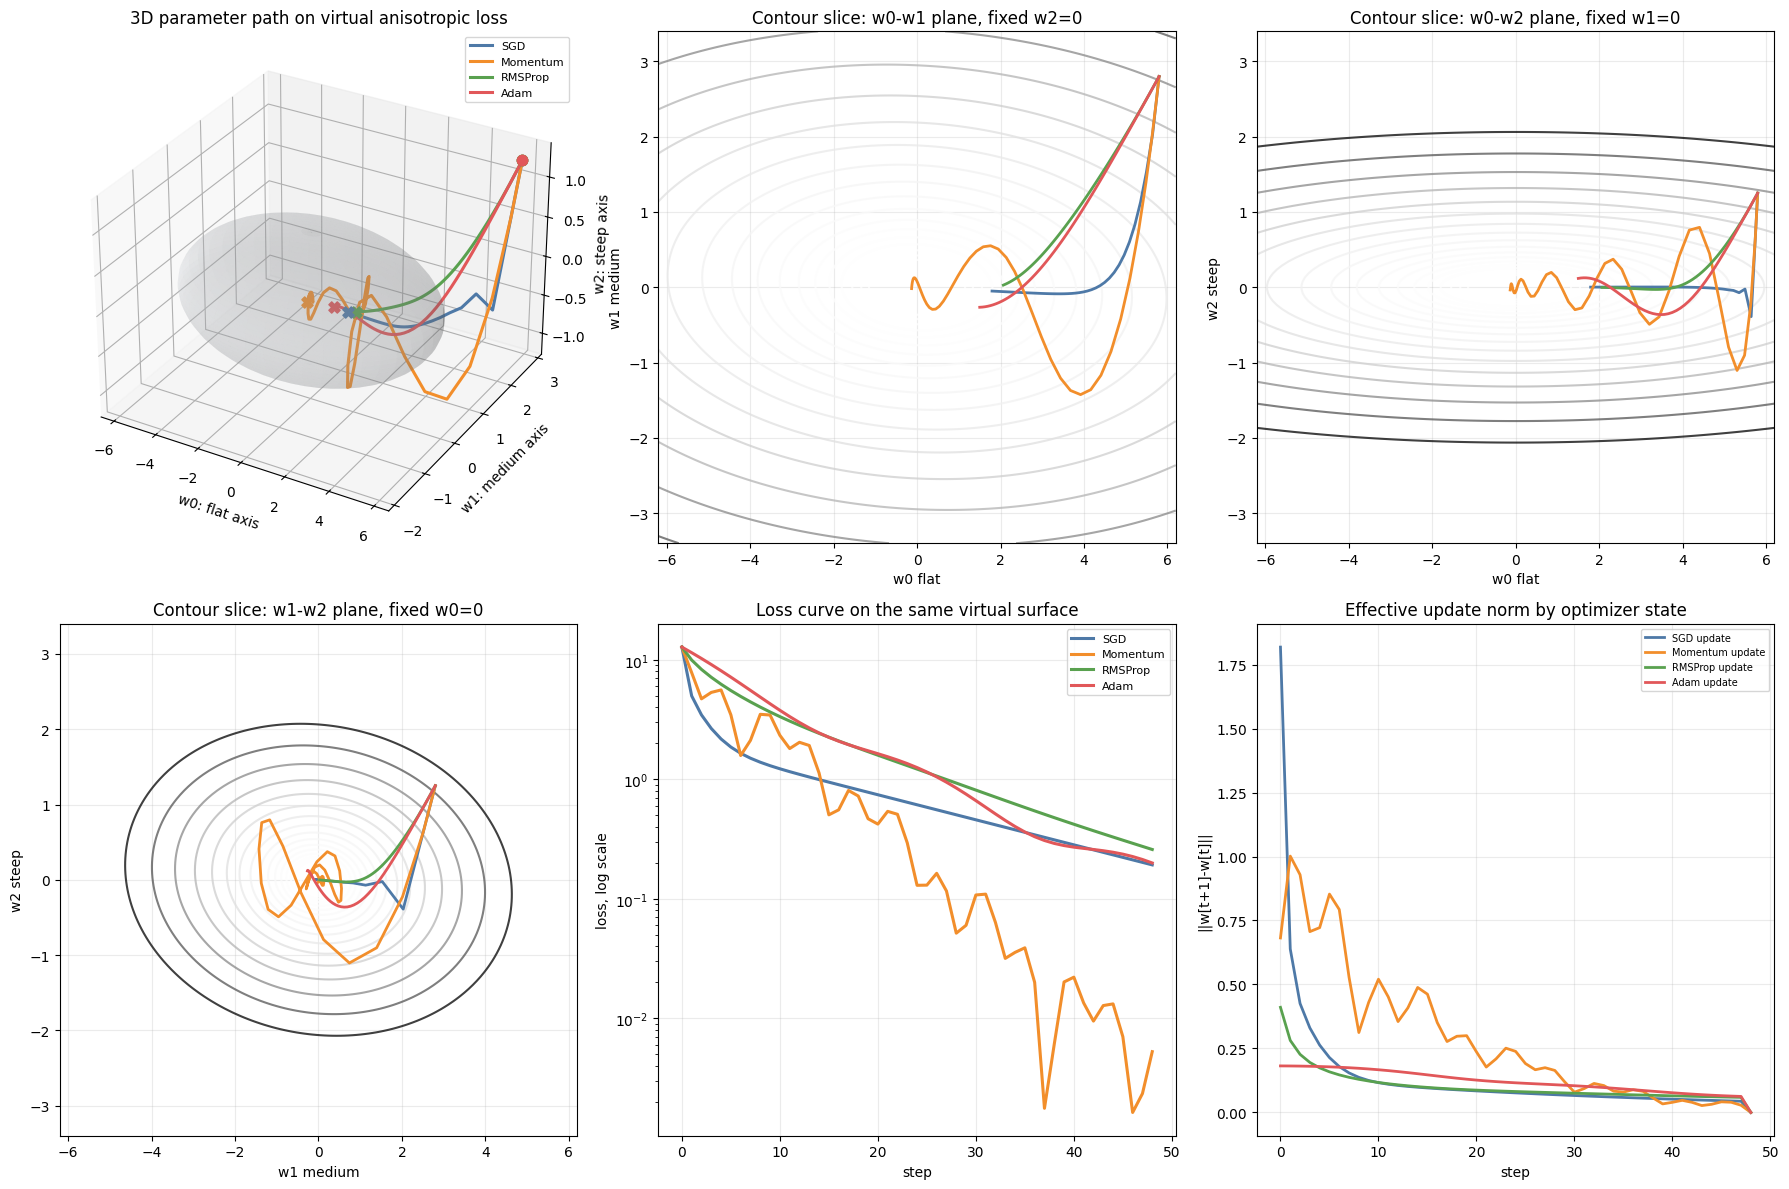

,view,what_to_read,caution
0,3D parameter path,"w0,w1,w2 세 축에서 optimizer가 어떤 공간 경로를 밟는지 본다.",고차원 전체 loss를 완전히 그린 것이 아니라 3D surrogate subspa...
1,w0-w1 contour,완만한 w0 축과 중간 w1 축에서 slow drift와 방향 누적을 본다.,w2를 0으로 고정한 slice라 실제 path의 loss와 완전히 같지는 않다.
2,w0-w2 contour,가파른 w2 축에서 초반 overshoot와 빠른 loss 감소를 본다.,가파른 축은 update norm이 클수록 진동이 잘 보인다.
3,w1-w2 contour,중간/가파른 축이 만날 때 zig-zag가 생기는지 본다.,Momentum은 velocity 때문에 loss 증가 step이 생길 수 있다.
4,loss curve,공간 경로가 실제 loss 감소로 이어졌는지 확인한다.,accuracy가 없는 surrogate이므로 loss/geometry 해석 전용이다.
5,update norm,optimizer state가 실제 step 크기를 어떻게 바꾸는지 본다.,"SGD는 grad_norm과 update_norm이 직접 연결되고, adaptive..."


,answer_step,sentence
0,관찰,같은 시작점과 같은 loss/gradient 함수를 써도 optimizer별 3D ...
1,원인,"SGD는 현재 gradient에 직접 비례하고, Momentum은 velocity,..."
2,제한,이 surface는 Iris/MNIST 실제 손실이 아니라 optimizer upd...
3,결론,Part 2/3의 loss curve 차이는 모델이 다른 데이터를 본 차이가 아니라...


In [16]:
# [INSERTED] Virtual 3D optimizer contour analysis
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# [전역 주석 보강 | 이 cell의 위치]
# 이 코드는 Part 1 optimizer 구현 직후에 들어가는 초반부 bridge다.
# 목적은 "공식 Iris/MNIST 실험 전에 optimizer가 같은 gradient field를 어떻게 다르게 이동하는지"를 3D로 보여주는 것이다.
# 원본 homework의 test_xor/results/mnist_results/sgd_accs/adam_accs 변수는 건드리지 않는다.

from pathlib import Path
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - Matplotlib 3D projection 등록용 import

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

# [가상 3D loss 설계 | 왜 3개 축인가]
# 실제 neural network의 parameter는 W와 b를 모두 펼치면 수백~수천 차원이 된다.
# 사람이 볼 수 있는 공간은 2D/3D뿐이므로, 여기서는 대표 parameter 축 세 개를 잡은 surrogate surface를 만든다.
# w0: 완만한 축. gradient가 작아 SGD가 천천히 이동하는 방향을 표현한다.
# w1: 중간 곡률 축. optimizer가 어느 정도 안정적으로 내려오는 방향이다.
# w2: 가파른 축. step이 크면 초반 overshoot와 zig-zag가 잘 보이는 방향이다.
# A는 positive definite matrix이고, loss는 0.5 * w^T A w 이다. 이때 gradient는 A @ w 이다.
A_virtual3d_ext = np.array([
    [0.12, 0.03, 0.00],
    [0.03, 1.20, 0.25],
    [0.00, 0.25, 6.00],
], dtype=float)

# [수학 helper | loss]
# w_ext는 shape (3,)인 parameter vector다.
# 반환값은 scalar loss이며, 0에 가까울수록 minimum에 가까워진다.
def virtual3d_loss_ext(w_ext):
    return float(0.5 * w_ext @ A_virtual3d_ext @ w_ext)

# [수학 helper | gradient]
# L(w)=0.5*w^T*A*w이고 A가 symmetric이면 gradient는 A*w다.
# optimizer들은 모두 이 같은 gradient 함수를 사용한다.
# 단, 첫 step 이후에는 optimizer별 위치 w가 달라지므로 실제로 관측하는 gradient sequence도 달라진다.
def virtual3d_grad_ext(w_ext):
    return A_virtual3d_ext @ w_ext

# [optimizer simulation | 수식과 코드 연결]
# 여기서는 Network/Dense를 쓰지 않고 3D vector w만 직접 움직인다.
# 이유: optimizer update rule의 차이를 loss geometry 위에서 분리해서 보려는 목적이다.
# SGD: 현재 gradient만 보고 이동한다.
# Momentum: 이전 velocity를 기억한다.
# RMSProp: gradient 제곱 누적값으로 축별 step scale을 조절한다.
# Adam: 1차 moment와 2차 moment를 함께 사용한다.
def simulate_virtual3d_optimizer_ext(name_ext, lr_ext, steps_ext=48, start_ext=None, mu_ext=0.86, rho_ext=0.90, beta1_ext=0.90, beta2_ext=0.985, eps_ext=1e-8):
    if start_ext is None:
        start_ext = np.array([5.8, 2.8, 1.25], dtype=float)

    w_ext = start_ext.astype(float).copy()
    velocity_ext = np.zeros_like(w_ext)
    sq_acc_ext = np.zeros_like(w_ext)
    m_ext = np.zeros_like(w_ext)
    v_ext = np.zeros_like(w_ext)

    rows_ext = []
    prev_loss_ext = virtual3d_loss_ext(w_ext)

    for step_ext in range(steps_ext + 1):
        grad_ext = virtual3d_grad_ext(w_ext)
        loss_ext = virtual3d_loss_ext(w_ext)
        grad_norm_ext = float(np.linalg.norm(grad_ext))
        rows_ext.append({
            "optimizer": name_ext,
            "step": step_ext,
            "w0": float(w_ext[0]),
            "w1": float(w_ext[1]),
            "w2": float(w_ext[2]),
            "loss": loss_ext,
            "grad_norm": grad_norm_ext,
            "loss_increased_from_prev": bool(loss_ext > prev_loss_ext + 1e-12) if step_ext > 0 else False,
            "update_norm": 0.0 if step_ext == 0 else np.nan,
        })

        # 마지막 row는 위치를 기록하기 위한 것이므로 update를 한 번 더 만들지 않는다.
        if step_ext == steps_ext:
            break

        old_w_ext = w_ext.copy()

        if name_ext == "SGD":
            # SGD update: w <- w - lr * grad
            # 현재 위치의 gradient 크기가 곧 step 크기를 거의 직접 결정한다.
            update_ext = -lr_ext * grad_ext
            w_ext = w_ext + update_ext
        elif name_ext == "Momentum":
            # Momentum update: v <- mu*v - lr*grad, w <- w + v
            # 이전 update 방향이 velocity로 남아 있어서 골짜기 중심을 지나칠 수 있다.
            velocity_ext = mu_ext * velocity_ext - lr_ext * grad_ext
            update_ext = velocity_ext.copy()
            w_ext = w_ext + update_ext
        elif name_ext == "RMSProp":
            # RMSProp update: s <- rho*s + (1-rho)*grad^2
            # gradient가 자주 큰 축은 denominator가 커져 step이 자동으로 줄어든다.
            sq_acc_ext = rho_ext * sq_acc_ext + (1 - rho_ext) * (grad_ext ** 2)
            update_ext = -lr_ext * grad_ext / (np.sqrt(sq_acc_ext) + eps_ext)
            w_ext = w_ext + update_ext
        elif name_ext == "Adam":
            # Adam update: m은 방향 평균, v는 gradient 제곱 평균이다.
            # bias correction 때문에 초반 step이 지나치게 작아지는 것을 보정한다.
            t_ext = step_ext + 1
            m_ext = beta1_ext * m_ext + (1 - beta1_ext) * grad_ext
            v_ext = beta2_ext * v_ext + (1 - beta2_ext) * (grad_ext ** 2)
            m_hat_ext = m_ext / (1 - beta1_ext ** t_ext)
            v_hat_ext = v_ext / (1 - beta2_ext ** t_ext)
            update_ext = -lr_ext * m_hat_ext / (np.sqrt(v_hat_ext) + eps_ext)
            w_ext = w_ext + update_ext
        else:
            raise ValueError(f"unknown optimizer: {name_ext}")

        rows_ext[-1]["update_norm"] = float(np.linalg.norm(w_ext - old_w_ext))
        prev_loss_ext = loss_ext

    return pd.DataFrame(rows_ext)

# [비교 조건 | same loss, same start, different update rule]
# 학습률은 3D surrogate에서 경로 차이가 보이도록 설정한 extension-only 값이다.
# 공식 homework의 configs/lrs 값과 무관하며, official score를 바꾸지 않는다.
virtual3d_configs_ext = [
    ("SGD", 0.20),
    ("Momentum", 0.075),
    ("RMSProp", 0.075),
    ("Adam", 0.105),
]
virtual3d_path_tables_ext = [
    simulate_virtual3d_optimizer_ext(name_ext, lr_ext)
    for name_ext, lr_ext in virtual3d_configs_ext
]
virtual3d_paths_ext = pd.concat(virtual3d_path_tables_ext, ignore_index=True)
virtual3d_paths_ext.to_csv(csv_dir_ext / "virtual_3d_optimizer_paths_ext.csv", index=False)

# [평가 지표 | trajectory를 수치로 읽기]
# final_loss: 마지막 loss가 얼마나 낮은가.
# path_length_3d: 3D parameter space에서 실제로 얼마나 돌아갔는가. zig-zag가 크면 길어진다.
# overshoot_count: loss가 이전 step보다 올라간 횟수다. 너무 큰 step이나 inertia가 있으면 늘어난다.
# max_update_norm: 가장 큰 한 번의 parameter 이동 크기다. update 폭발/overshoot 후보를 본다.
eval_rows_ext = []
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    coords_ext = path_df_ext[["w0", "w1", "w2"]].to_numpy()
    segment_norms_ext = np.linalg.norm(np.diff(coords_ext, axis=0), axis=1)
    final_row_ext = path_df_ext.iloc[-1]
    start_loss_ext = float(path_df_ext.iloc[0]["loss"])
    final_loss_ext = float(final_row_ext["loss"])
    eval_rows_ext.append({
        "optimizer": name_ext,
        "start_loss": start_loss_ext,
        "final_loss": final_loss_ext,
        "loss_drop_ratio": 1 - final_loss_ext / start_loss_ext,
        "final_distance_to_origin": float(np.linalg.norm(coords_ext[-1])),
        "path_length_3d": float(segment_norms_ext.sum()),
        "max_update_norm": float(segment_norms_ext.max()),
        "mean_grad_norm": float(path_df_ext["grad_norm"].mean()),
        "overshoot_count_loss_increase": int(path_df_ext["loss_increased_from_prev"].sum()),
    })
virtual3d_eval_ext = pd.DataFrame(eval_rows_ext).sort_values("final_loss")
display(virtual3d_eval_ext)
virtual3d_eval_ext.to_csv(csv_dir_ext / "virtual_3d_optimizer_evaluation_ext.csv", index=False)

# [contour helper | 3D를 2D slice로 자르기]
# 3D parameter space의 contour는 실제로는 ellipsoid level set이다.
# 학생이 읽기 쉽게 w2=0, w1=0, w0=0인 2D slice 세 개를 만든다.
def loss_on_slice_ext(axis_pair_ext, fixed_value_ext=0.0, grid_n_ext=130):
    grid_a_ext = np.linspace(-6.2, 6.2, grid_n_ext)
    grid_b_ext = np.linspace(-3.4, 3.4, grid_n_ext)
    GA_ext, GB_ext = np.meshgrid(grid_a_ext, grid_b_ext)
    Z_ext = np.zeros_like(GA_ext)
    for i_ext in range(grid_n_ext):
        for j_ext in range(grid_n_ext):
            w_ext = np.zeros(3)
            w_ext[axis_pair_ext[0]] = GA_ext[i_ext, j_ext]
            w_ext[axis_pair_ext[1]] = GB_ext[i_ext, j_ext]
            fixed_axis_ext = list({0, 1, 2} - set(axis_pair_ext))[0]
            w_ext[fixed_axis_ext] = fixed_value_ext
            Z_ext[i_ext, j_ext] = virtual3d_loss_ext(w_ext)
    return GA_ext, GB_ext, Z_ext

# [ellipsoid helper | 3D iso-loss surface]
# loss = c인 점들은 0.5*w^T*A*w = c인 ellipsoid를 이룬다.
# 이 반투명 표면은 "minimum 주변 등손실면"이 어떤 방향으로 길게 늘어나는지 보여준다.
def make_iso_loss_ellipsoid_ext(loss_level_ext, n_ext=44):
    eigvals_ext, eigvecs_ext = np.linalg.eigh(A_virtual3d_ext)
    theta_ext = np.linspace(0, 2 * np.pi, n_ext)
    phi_ext = np.linspace(0, np.pi, n_ext)
    TH_ext, PH_ext = np.meshgrid(theta_ext, phi_ext)
    sphere_ext = np.stack([
        np.sin(PH_ext) * np.cos(TH_ext),
        np.sin(PH_ext) * np.sin(TH_ext),
        np.cos(PH_ext),
    ], axis=-1)
    radii_ext = np.sqrt(2 * loss_level_ext / eigvals_ext)
    ellipsoid_ext = sphere_ext @ np.diag(radii_ext) @ eigvecs_ext.T
    return ellipsoid_ext[..., 0], ellipsoid_ext[..., 1], ellipsoid_ext[..., 2]

colors_ext = {"SGD": "#4e79a7", "Momentum": "#f28e2b", "RMSProp": "#59a14f", "Adam": "#e15759"}
contour_levels_ext = np.geomspace(0.08, float(virtual3d_paths_ext["loss"].max()), 18)

fig = plt.figure(figsize=(18, 12))
ax3d_ext = fig.add_subplot(2, 3, 1, projection="3d")

# 3D path: x/y/z가 parameter 축이고, loss는 경로의 높이가 아니라 색/marker 해석으로 따로 읽는다.
# loss를 네 번째 차원으로 완전히 그릴 수 없기 때문에, path는 parameter space에 두고 evaluation table에서 loss를 함께 본다.
iso_x_ext, iso_y_ext, iso_z_ext = make_iso_loss_ellipsoid_ext(loss_level_ext=2.0)
ax3d_ext.plot_surface(iso_x_ext, iso_y_ext, iso_z_ext, color="#d1d5db", alpha=0.18, linewidth=0)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    ax3d_ext.plot(path_df_ext["w0"], path_df_ext["w1"], path_df_ext["w2"], color=colors_ext[name_ext], linewidth=2.2, label=name_ext)
    ax3d_ext.scatter(path_df_ext.iloc[0]["w0"], path_df_ext.iloc[0]["w1"], path_df_ext.iloc[0]["w2"], color=colors_ext[name_ext], s=55, marker="o")
    ax3d_ext.scatter(path_df_ext.iloc[-1]["w0"], path_df_ext.iloc[-1]["w1"], path_df_ext.iloc[-1]["w2"], color=colors_ext[name_ext], s=65, marker="X")
ax3d_ext.set_title("3D parameter path on virtual anisotropic loss")
ax3d_ext.set_xlabel("w0: flat axis")
ax3d_ext.set_ylabel("w1: medium axis")
ax3d_ext.set_zlabel("w2: steep axis")
ax3d_ext.legend(fontsize=8)

# [contour slice 1 | w0-w1]
ax_w0w1_ext = fig.add_subplot(2, 3, 2)
G0_ext, G1_ext, Z01_ext = loss_on_slice_ext((0, 1), fixed_value_ext=0.0)
ax_w0w1_ext.contour(G0_ext, G1_ext, Z01_ext, levels=contour_levels_ext, cmap="Greys", alpha=0.75)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    ax_w0w1_ext.plot(path_df_ext["w0"], path_df_ext["w1"], color=colors_ext[name_ext], linewidth=2, label=name_ext)
ax_w0w1_ext.set_title("Contour slice: w0-w1 plane, fixed w2=0")
ax_w0w1_ext.set_xlabel("w0 flat")
ax_w0w1_ext.set_ylabel("w1 medium")
ax_w0w1_ext.grid(alpha=0.25)

# [contour slice 2 | w0-w2]
ax_w0w2_ext = fig.add_subplot(2, 3, 3)
G0b_ext, G2_ext, Z02_ext = loss_on_slice_ext((0, 2), fixed_value_ext=0.0)
ax_w0w2_ext.contour(G0b_ext, G2_ext, Z02_ext, levels=contour_levels_ext, cmap="Greys", alpha=0.75)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    ax_w0w2_ext.plot(path_df_ext["w0"], path_df_ext["w2"], color=colors_ext[name_ext], linewidth=2)
ax_w0w2_ext.set_title("Contour slice: w0-w2 plane, fixed w1=0")
ax_w0w2_ext.set_xlabel("w0 flat")
ax_w0w2_ext.set_ylabel("w2 steep")
ax_w0w2_ext.grid(alpha=0.25)

# [contour slice 3 | w1-w2]
ax_w1w2_ext = fig.add_subplot(2, 3, 4)
G1b_ext, G2b_ext, Z12_ext = loss_on_slice_ext((1, 2), fixed_value_ext=0.0)
ax_w1w2_ext.contour(G1b_ext, G2b_ext, Z12_ext, levels=contour_levels_ext, cmap="Greys", alpha=0.75)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    ax_w1w2_ext.plot(path_df_ext["w1"], path_df_ext["w2"], color=colors_ext[name_ext], linewidth=2)
ax_w1w2_ext.set_title("Contour slice: w1-w2 plane, fixed w0=0")
ax_w1w2_ext.set_xlabel("w1 medium")
ax_w1w2_ext.set_ylabel("w2 steep")
ax_w1w2_ext.grid(alpha=0.25)

# [loss curve | contour만으로 놓치는 수치]
ax_loss_ext = fig.add_subplot(2, 3, 5)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    ax_loss_ext.plot(path_df_ext["step"], path_df_ext["loss"], color=colors_ext[name_ext], linewidth=2.2, label=name_ext)
ax_loss_ext.set_yscale("log")
ax_loss_ext.set_title("Loss curve on the same virtual surface")
ax_loss_ext.set_xlabel("step")
ax_loss_ext.set_ylabel("loss, log scale")
ax_loss_ext.grid(alpha=0.25)
ax_loss_ext.legend(fontsize=8)

# [norm dashboard | gradient norm vs update norm]
ax_norm_ext = fig.add_subplot(2, 3, 6)
for name_ext, path_df_ext in virtual3d_paths_ext.groupby("optimizer", sort=False):
    update_series_ext = path_df_ext["update_norm"].fillna(0.0)
    ax_norm_ext.plot(path_df_ext["step"], update_series_ext, color=colors_ext[name_ext], linewidth=2, label=f"{name_ext} update")
ax_norm_ext.set_title("Effective update norm by optimizer state")
ax_norm_ext.set_xlabel("step")
ax_norm_ext.set_ylabel("||w[t+1]-w[t]||")
ax_norm_ext.grid(alpha=0.25)
ax_norm_ext.legend(fontsize=7)

plt.tight_layout()
fig.savefig(fig_dir_ext / "virtual_3d_optimizer_contour_analysis_ext.png", dpi=170)
plt.show()

# [해석 보드 | 그래프를 읽는 순서]
virtual3d_reading_guide_ext = pd.DataFrame([
    ["3D parameter path", "w0,w1,w2 세 축에서 optimizer가 어떤 공간 경로를 밟는지 본다.", "고차원 전체 loss를 완전히 그린 것이 아니라 3D surrogate subspace다."],
    ["w0-w1 contour", "완만한 w0 축과 중간 w1 축에서 slow drift와 방향 누적을 본다.", "w2를 0으로 고정한 slice라 실제 path의 loss와 완전히 같지는 않다."],
    ["w0-w2 contour", "가파른 w2 축에서 초반 overshoot와 빠른 loss 감소를 본다.", "가파른 축은 update norm이 클수록 진동이 잘 보인다."],
    ["w1-w2 contour", "중간/가파른 축이 만날 때 zig-zag가 생기는지 본다.", "Momentum은 velocity 때문에 loss 증가 step이 생길 수 있다."],
    ["loss curve", "공간 경로가 실제 loss 감소로 이어졌는지 확인한다.", "accuracy가 없는 surrogate이므로 loss/geometry 해석 전용이다."],
    ["update norm", "optimizer state가 실제 step 크기를 어떻게 바꾸는지 본다.", "SGD는 grad_norm과 update_norm이 직접 연결되고, adaptive 계열은 다르게 움직인다."],
], columns=["view", "what_to_read", "caution"])
display(virtual3d_reading_guide_ext)
virtual3d_reading_guide_ext.to_csv(csv_dir_ext / "virtual_3d_optimizer_reading_guide_ext.csv", index=False)

virtual3d_interpretation_ext = pd.DataFrame([
    ["관찰", "같은 시작점과 같은 loss/gradient 함수를 써도 optimizer별 3D path, contour projection, update norm이 다르게 나타난다."],
    ["원인", "SGD는 현재 gradient에 직접 비례하고, Momentum은 velocity, RMSProp은 squared-gradient accumulator, Adam은 first/second moment를 사용한다."],
    ["제한", "이 surface는 Iris/MNIST 실제 손실이 아니라 optimizer update rule을 분리해 보기 위한 virtual quadratic surrogate다."],
    ["결론", "Part 2/3의 loss curve 차이는 모델이 다른 데이터를 본 차이가 아니라, 같은 param/grad를 optimizer가 다르게 해석한 결과로 읽어야 한다."],
], columns=["answer_step", "sentence"])
display(virtual3d_interpretation_ext)
virtual3d_interpretation_ext.to_csv(csv_dir_ext / "virtual_3d_optimizer_interpretation_ext.csv", index=False)


## [INSERTED] Iris DatasetCard and EDA

이 확장 cell은 Part 2의 official Iris 실험을 바꾸지 않고, 그 실험이 어떤 데이터/출력/loss/metric 계약 위에 놓이는지 EDA로 확인한다.


,item,value,meaning,modeling implication
0,X,"(150, 4)",4 numeric features,Dense input dimension = 4
1,y,"(150,)",3 class labels,Dense output dimension = 3
2,task,multiclass classification,setosa/versicolor/virginica,SoftmaxCE
3,metric,accuracy + macro-F1 + confusion matrix,class-wise mistakes matter,Part 2/diagnostics


0    50
1    50
2    50
Name: class_count, dtype: int64

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


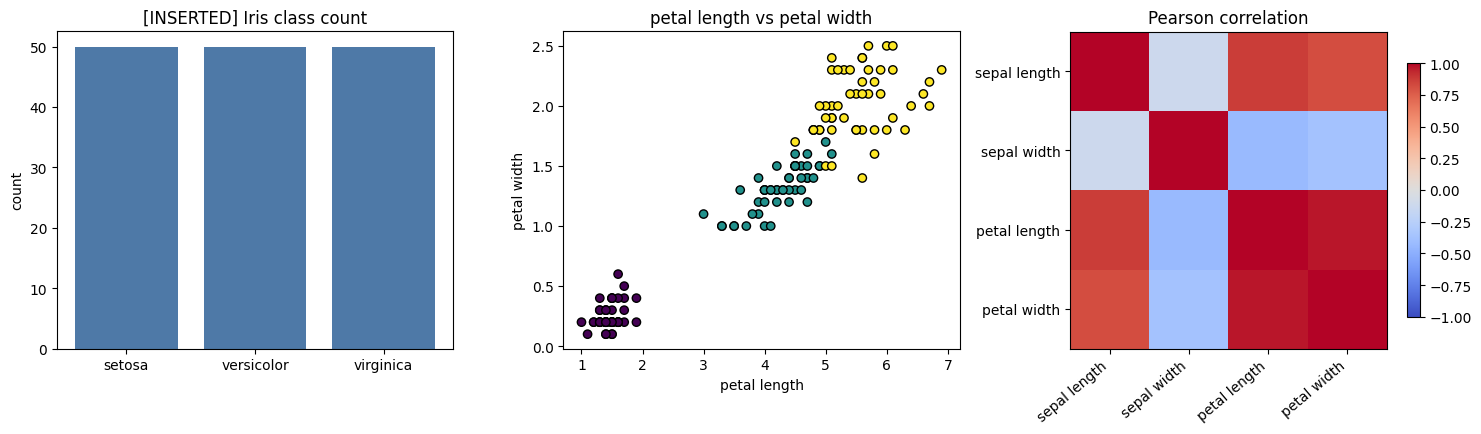

,step,note
0,관찰,class count가 균형이고 petal feature가 class separat...
1,원인,Iris는 4개 numeric feature와 3개 class label을 가진 작...
2,제한,샘플 수가 작아 split seed와 preprocessing 정책의 영향이 있을 ...
3,결론,"Part 2 공식 비교는 Dense(4->16->3), SoftmaxCE, accu..."


In [17]:
# [INSERTED] Iris DatasetCard and EDA
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, f1_score

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

iris_dataset_card_ext = pd.DataFrame([
    ["X", iris.data.shape, "4 numeric features", "Dense input dimension = 4"],
    ["y", iris.target.shape, "3 class labels", "Dense output dimension = 3"],
    ["task", "multiclass classification", "setosa/versicolor/virginica", "SoftmaxCE"],
    ["metric", "accuracy + macro-F1 + confusion matrix", "class-wise mistakes matter", "Part 2/diagnostics"],
], columns=["item", "value", "meaning", "modeling implication"])
display(iris_dataset_card_ext)
iris_dataset_card_ext.to_csv(csv_dir_ext / "iris_dataset_card_ext.csv", index=False)

iris_class_count_ext = pd.Series(iris.target).value_counts().sort_index()
iris_corr_ext = pd.DataFrame(iris.data, columns=iris.feature_names).corr(method="pearson")
display(iris_class_count_ext.rename("class_count"))
display(iris_corr_ext)
iris_corr_ext.to_csv(csv_dir_ext / "iris_feature_correlation_ext.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].bar(iris.target_names, iris_class_count_ext.values, color="#4e79a7")
axes[0].set_title("[INSERTED] Iris class count")
axes[0].set_ylabel("count")

scatter = axes[1].scatter(iris.data[:, 2], iris.data[:, 3], c=iris.target, cmap="viridis", edgecolor="black")
axes[1].set_xlabel("petal length")
axes[1].set_ylabel("petal width")
axes[1].set_title("petal length vs petal width")

im = axes[2].imshow(iris_corr_ext, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(iris.feature_names)))
axes[2].set_yticks(range(len(iris.feature_names)))
axes[2].set_xticklabels([n.replace(" (cm)", "") for n in iris.feature_names], rotation=40, ha="right")
axes[2].set_yticklabels([n.replace(" (cm)", "") for n in iris.feature_names])
axes[2].set_title("Pearson correlation")
fig.colorbar(im, ax=axes[2], shrink=0.8)
plt.tight_layout()
fig.savefig(fig_dir_ext / "iris_datasetcard_eda.png", dpi=160)
plt.show()

iris_eda_interpretation_ext = pd.DataFrame([
    ["관찰", "class count가 균형이고 petal feature가 class separation을 잘 보여준다."],
    ["원인", "Iris는 4개 numeric feature와 3개 class label을 가진 작은 multiclass 문제다."],
    ["제한", "샘플 수가 작아 split seed와 preprocessing 정책의 영향이 있을 수 있다."],
    ["결론", "Part 2 공식 비교는 Dense(4->16->3), SoftmaxCE, accuracy를 쓰고, 확장 진단에서는 macro-F1/confusion을 함께 본다."],
], columns=["step", "note"])
display(iris_eda_interpretation_ext)
iris_eda_interpretation_ext.to_csv(csv_dir_ext / "iris_eda_interpretation_ext.csv", index=False)


## [INSERTED] Iris per-sample CE / margin classification diagnostics

원본 `train_iris()`는 `(losses, test_acc)`만 반환해야 하므로 수정하지 않는다. 대신 확장용 `train_iris_diagnostic_ext()`를 따로 만들어 confusion matrix, per-class F1, per-sample CE, margin을 계산한다.


,optimizer,final_loss,test_accuracy,macro_f1,mean_per_sample_ce,mean_margin
0,MySGD,0.085444,0.977778,0.977753,0.167875,3.743163
1,MyMomentum,0.057353,0.977778,0.977753,0.135573,4.828175
2,MyRMSProp,0.050463,0.977778,0.977753,0.301048,9.458655
3,MyAdam,0.039351,0.977778,0.977753,0.115966,6.534146


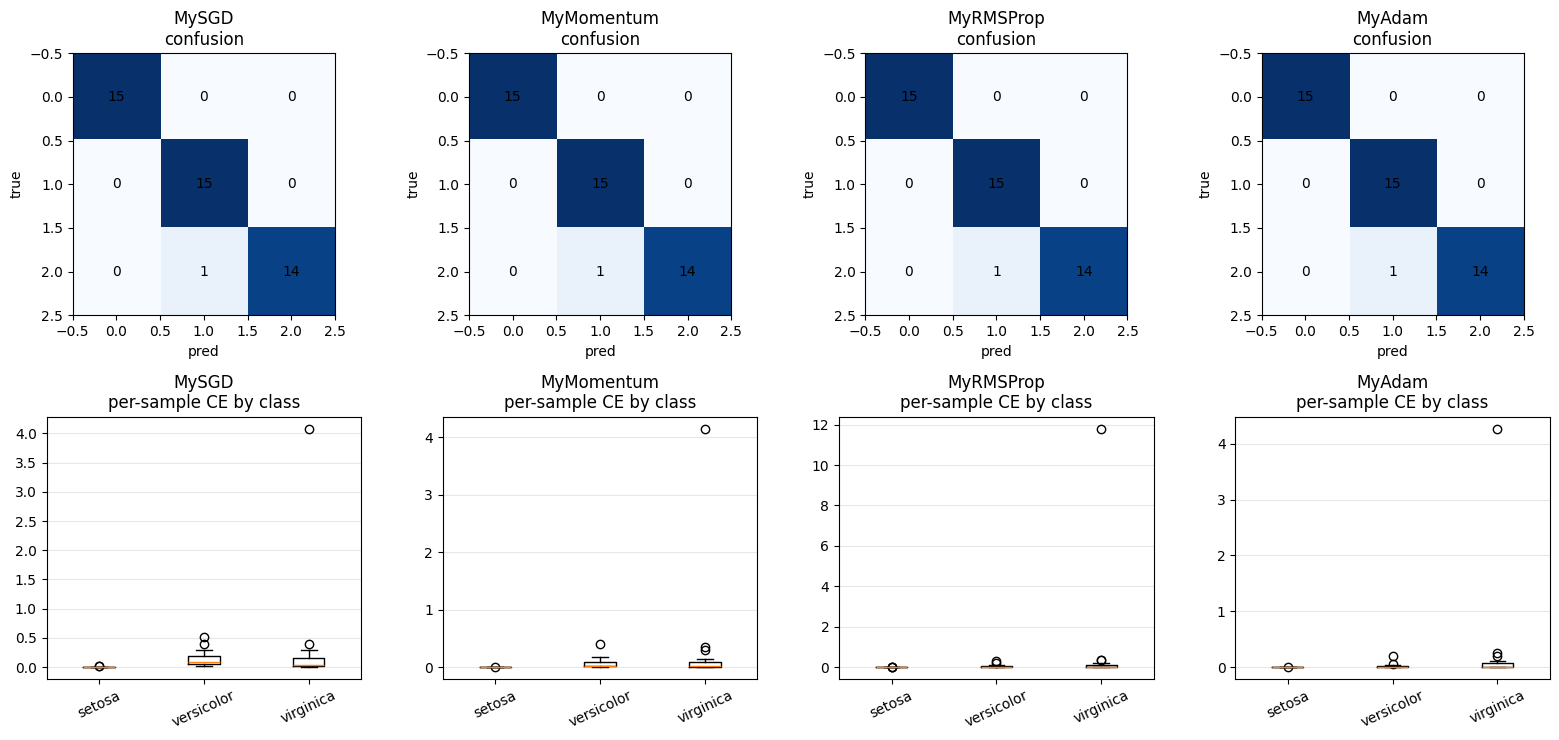

In [18]:
# [INSERTED] Iris per-sample CE / margin classification diagnostics
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, f1_score

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

def softmax_ext(logits_ext):
    shifted_ext = logits_ext - np.max(logits_ext, axis=1, keepdims=True)
    exp_ext = np.exp(shifted_ext)
    return exp_ext / exp_ext.sum(axis=1, keepdims=True)

def train_iris_diagnostic_ext(OptCls, **kw):
    np.random.seed(0)
    net_ext = Network()
    net_ext.add(Dense(4, 16))
    net_ext.add(ReLU())
    net_ext.add(Dense(16, 3))
    loss_fn_ext = SoftmaxCE()
    opt_ext = OptCls(**kw)
    np.random.seed(0)
    history_ext = fit(net_ext, X_train, Y_train, loss_fn_ext, opt_ext, epochs=100, batch_size=16, verbose=False)
    logits_ext = net_ext.forward(X_test)
    probs_ext = softmax_ext(logits_ext)
    y_true_ext = Y_test.argmax(axis=1)
    y_pred_ext = probs_ext.argmax(axis=1)
    p_true_ext = probs_ext[np.arange(len(y_true_ext)), y_true_ext]
    per_sample_ce_ext = -np.log(np.clip(p_true_ext, 1e-12, 1.0))
    other_logits_ext = logits_ext.copy()
    other_logits_ext[np.arange(len(y_true_ext)), y_true_ext] = -np.inf
    margin_ext = logits_ext[np.arange(len(y_true_ext)), y_true_ext] - np.max(other_logits_ext, axis=1)
    ce_margin_df_ext = pd.DataFrame({
        "sample_id": np.arange(len(y_true_ext)),
        "y_true": y_true_ext,
        "y_pred": y_pred_ext,
        "class_name": [iris.target_names[i] for i in y_true_ext],
        "p_true": p_true_ext,
        "per_sample_ce": per_sample_ce_ext,
        "margin": margin_ext,
        "correct": y_true_ext == y_pred_ext,
    })
    return net_ext, history_ext, ce_margin_df_ext, confusion_matrix(y_true_ext, y_pred_ext)

diag_iris_rows_ext = []
diag_ce_margin_tables_ext = []
diag_confusions_ext = {}
for name_ext, OptCls_ext, kw_ext in configs:
    net_ext, hist_ext, ce_margin_df_ext, cm_ext = train_iris_diagnostic_ext(OptCls_ext, **kw_ext)
    ce_margin_df_ext["optimizer"] = name_ext
    diag_ce_margin_tables_ext.append(ce_margin_df_ext)
    diag_confusions_ext[name_ext] = cm_ext
    diag_iris_rows_ext.append({
        "optimizer": name_ext,
        "final_loss": float(hist_ext["loss"][-1]),
        "test_accuracy": float((ce_margin_df_ext["y_true"] == ce_margin_df_ext["y_pred"]).mean()),
        "macro_f1": float(f1_score(ce_margin_df_ext["y_true"], ce_margin_df_ext["y_pred"], average="macro")),
        "mean_per_sample_ce": float(ce_margin_df_ext["per_sample_ce"].mean()),
        "mean_margin": float(ce_margin_df_ext["margin"].mean()),
    })

diag_iris_summary_ext = pd.DataFrame(diag_iris_rows_ext)
diag_iris_ce_margin_ext = pd.concat(diag_ce_margin_tables_ext, ignore_index=True)
display(diag_iris_summary_ext)
diag_iris_summary_ext.to_csv(csv_dir_ext / "iris_ce_margin_diagnostic_summary.csv", index=False)
diag_iris_ce_margin_ext.to_csv(csv_dir_ext / "iris_classification_ce_margin.csv", index=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax_ext, (name_ext, cm_ext) in zip(axes[0], diag_confusions_ext.items()):
    ax_ext.imshow(cm_ext, cmap="Blues")
    ax_ext.set_title(f"{name_ext}\nconfusion")
    ax_ext.set_xlabel("pred")
    ax_ext.set_ylabel("true")
    for i_ext in range(cm_ext.shape[0]):
        for j_ext in range(cm_ext.shape[1]):
            ax_ext.text(j_ext, i_ext, int(cm_ext[i_ext, j_ext]), ha="center", va="center")

for ax_ext, name_ext in zip(axes[1], diag_confusions_ext.keys()):
    data_ext = [diag_iris_ce_margin_ext[(diag_iris_ce_margin_ext["optimizer"] == name_ext) & (diag_iris_ce_margin_ext["y_true"] == cls_ext)]["per_sample_ce"] for cls_ext in range(3)]
    ax_ext.boxplot(data_ext, tick_labels=iris.target_names)
    ax_ext.set_title(f"{name_ext}\nper-sample CE by class")
    ax_ext.tick_params(axis="x", rotation=25)
    ax_ext.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir_ext / "iris_ce_margin_confusion_diagnostics.png", dpi=160)
plt.show()


## [INSERTED] Split-before-fit diagnostic

원본 Part 2의 `X = StandardScaler().fit_transform(iris.data)`는 homework 공식 지시이므로 그대로 유지했다. 이 확장 cell은 연구적으로는 `split first -> fit train only -> transform test`가 더 엄밀하다는 점을 별도 진단으로 보여준다.


,feature,train_mean,test_mean,all_fit_mean,mean_abs_test_coordinate_delta,max_abs_test_coordinate_delta
0,sepal length (cm),5.857143,5.811111,5.843333,0.016393,0.027382
1,sepal width (cm),3.069524,3.028889,3.057333,0.029362,0.050265
2,petal length (cm),3.789524,3.684444,3.758000,0.021297,0.044652
3,petal width (cm),1.197143,1.204444,1.199333,0.003859,0.008689


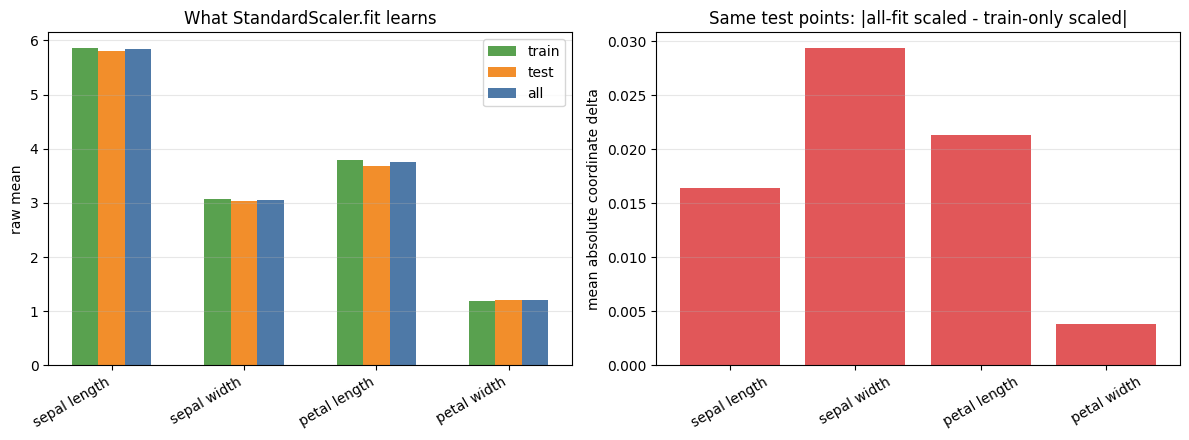

,step,note
0,관찰,"train/test/all의 feature 평균이 다르고, 같은 test sampl..."
1,원인,fit은 scaler의 mean/std state를 학습하므로 test가 fit에 ...
2,제한,"Iris에서는 metric 차이가 작을 수 있지만, evaluation protoc..."
3,결론,"공식 homework는 원문을 따르되, 연구 확장에서는 train-only fit을..."


In [19]:
# [INSERTED] Split-before-fit diagnostic
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

idx_all_ext = np.arange(len(iris.target))
idx_train_ext, idx_test_ext, y_train_ext, y_test_ext = train_test_split(
    idx_all_ext, iris.target, test_size=0.3, random_state=1, stratify=iris.target
)
X_train_raw_ext = iris.data[idx_train_ext].astype(float)
X_test_raw_ext = iris.data[idx_test_ext].astype(float)

scaler_wrong_ext = StandardScaler()
X_all_wrong_ext = scaler_wrong_ext.fit_transform(iris.data.astype(float))
X_test_wrong_ext = X_all_wrong_ext[idx_test_ext]

scaler_right_ext = StandardScaler()
X_train_right_ext = scaler_right_ext.fit_transform(X_train_raw_ext)
X_test_right_ext = scaler_right_ext.transform(X_test_raw_ext)

coord_delta_ext = X_test_wrong_ext - X_test_right_ext
split_fit_diag_ext = pd.DataFrame({
    "feature": iris.feature_names,
    "train_mean": X_train_raw_ext.mean(axis=0),
    "test_mean": X_test_raw_ext.mean(axis=0),
    "all_fit_mean": iris.data.astype(float).mean(axis=0),
    "mean_abs_test_coordinate_delta": np.abs(coord_delta_ext).mean(axis=0),
    "max_abs_test_coordinate_delta": np.abs(coord_delta_ext).max(axis=0),
})
display(split_fit_diag_ext)
split_fit_diag_ext.to_csv(csv_dir_ext / "split_before_fit_diagnostic.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x_ext = np.arange(len(iris.feature_names))
axes[0].bar(x_ext - 0.2, split_fit_diag_ext["train_mean"], width=0.2, label="train", color="#59a14f")
axes[0].bar(x_ext, split_fit_diag_ext["test_mean"], width=0.2, label="test", color="#f28e2b")
axes[0].bar(x_ext + 0.2, split_fit_diag_ext["all_fit_mean"], width=0.2, label="all", color="#4e79a7")
axes[0].set_xticks(x_ext)
axes[0].set_xticklabels([n.replace(" (cm)", "") for n in iris.feature_names], rotation=30, ha="right")
axes[0].set_ylabel("raw mean")
axes[0].set_title("What StandardScaler.fit learns")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar([n.replace(" (cm)", "") for n in iris.feature_names], split_fit_diag_ext["mean_abs_test_coordinate_delta"], color="#e15759")
axes[1].set_title("Same test points: |all-fit scaled - train-only scaled|")
axes[1].set_ylabel("mean absolute coordinate delta")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir_ext / "split_before_fit_diagnostic.png", dpi=160)
plt.show()

split_fit_interpretation_ext = pd.DataFrame([
    ["관찰", "train/test/all의 feature 평균이 다르고, 같은 test sample의 scaled coordinate도 달라진다."],
    ["원인", "fit은 scaler의 mean/std state를 학습하므로 test가 fit에 들어가면 test 분포 정보가 저장된다."],
    ["제한", "Iris에서는 metric 차이가 작을 수 있지만, evaluation protocol 관점의 leakage risk는 남는다."],
    ["결론", "공식 homework는 원문을 따르되, 연구 확장에서는 train-only fit을 원칙으로 둔다."],
], columns=["step", "note"])
display(split_fit_interpretation_ext)


## [INSERTED] Iris preprocessing, data-quality, association, PCA validation audit

이 확장 cell은 원본 Part 2의 official `StandardScaler().fit_transform(iris.data)`를 수정하지 않는다. 대신 연구형 진단으로 `train/validation/test`를 먼저 나누고, preprocessing은 train에서만 `fit`한 뒤 validation/test에는 `transform`만 적용한다.

핵심 질문은 네 가지다.

```text
1. Iris 데이터 품질은 optimizer 비교 전에 어떤 상태인가? missing, duplicate, class balance는 어떤가?
2. Pearson/Spearman/Kendall 상관과 Cramer's V는 어떤 feature가 species와 강하게 연결되는지 어떻게 다르게 보여주는가?
3. PCA projection은 scaling fit 범위가 바뀔 때 validation/test 좌표를 얼마나 다르게 보내는가?
4. train-only scaling으로 optimizer를 비교하면 validation 선택과 final test reporting을 어떻게 분리할 수 있는가?
```

이 cell은 보조 진단이다. 공식 Part 2 점수와 원본 `results`를 대체하지 않는다.


,check,value,why_it_matters
0,n_rows,150.0,sample 수. split 후 class별 표본이 너무 적지 않은지 본다.
1,n_numeric_features,4.0,Dense 입력 차원 Din=4와 직접 연결된다.
2,missing_cells,0.0,"0이면 imputation은 필요 없지만, 원칙은 train-only fit이다."
3,duplicate_rows,1.0,중복이 있으면 split leakage와 과대평가 가능성을 점검한다.
4,class_count_min,50.0,stratified split의 최소 class 표본 수.
5,class_count_max,50.0,class imbalance 확인용 최대 class 표본 수.
6,class_balance_ratio,1.0,1에 가까울수록 class balance가 좋다.


,count,mean,std,min,max,skew,missing_count,missing_rate
sepal length (cm),150.0,5.843333,0.828066,4.3,7.9,0.314911,0,0.0
sepal width (cm),150.0,3.057333,0.435866,2.0,4.4,0.318966,0,0.0
petal length (cm),150.0,3.758000,1.765298,1.0,6.9,-0.274884,0,0.0
petal width (cm),150.0,1.199333,0.762238,0.1,2.5,-0.102967,0,0.0


,method,feature_pair,corr,abs_corr
17,Kendall,petal length (cm) vs petal width (cm),0.806891,0.806891
13,Kendall,sepal length (cm) vs petal length (cm),0.718516,0.718516
14,Kendall,sepal length (cm) vs petal width (cm),0.655309,0.655309
5,Pearson,petal length (cm) vs petal width (cm),0.962865,0.962865
1,Pearson,sepal length (cm) vs petal length (cm),0.871754,0.871754
2,Pearson,sepal length (cm) vs petal width (cm),0.817941,0.817941
11,Spearman,petal length (cm) vs petal width (cm),0.937667,0.937667
7,Spearman,sepal length (cm) vs petal length (cm),0.881898,0.881898
8,Spearman,sepal length (cm) vs petal width (cm),0.834289,0.834289


,feature,binning,cramers_v_with_species,contingency_shape,interpretation
3,petal width (cm),pd.qcut(q=3),0.942242,"(3, 3)",higher means binned feature is more associated...
2,petal length (cm),pd.qcut(q=3),0.924701,"(3, 3)",higher means binned feature is more associated...
0,sepal length (cm),pd.qcut(q=3),0.641049,"(3, 3)",higher means binned feature is more associated...
1,sepal width (cm),pd.qcut(q=3),0.471537,"(3, 3)",higher means binned feature is more associated...


,feature,train_fit_mean,all_fit_mean,all_minus_train_mean,train_fit_scale,all_fit_scale,all_minus_train_scale,mean_abs_test_scaled_delta,max_abs_test_scaled_delta
0,sepal length (cm),5.848889,5.843333,-0.005556,0.826404,0.825301,-0.001102,0.006631,0.008916
1,sepal width (cm),3.075556,3.057333,-0.018222,0.434949,0.434411,-0.000538,0.041988,0.044008
2,petal length (cm),3.744444,3.758000,0.013556,1.764597,1.759404,-0.005193,0.007690,0.011793
3,petal width (cm),1.215556,1.199333,-0.016222,0.758348,0.759693,0.001345,0.021468,0.023958


,PC,train_only_explained_variance_ratio,all_fit_explained_variance_ratio,component_alignment_abs_dot
0,PC1,0.713844,0.729624,0.997598
1,PC2,0.248495,0.228508,0.997716
2,PC3,0.032537,0.036689,0.999876


,PC1_loading,PC2_loading,PC3_loading
sepal length (cm),0.533247,0.344828,0.725062
sepal width (cm),-0.202129,0.938145,-0.250917
petal length (cm),0.587170,-0.016316,-0.130497
petal width (cm),0.574476,0.026682,-0.627930


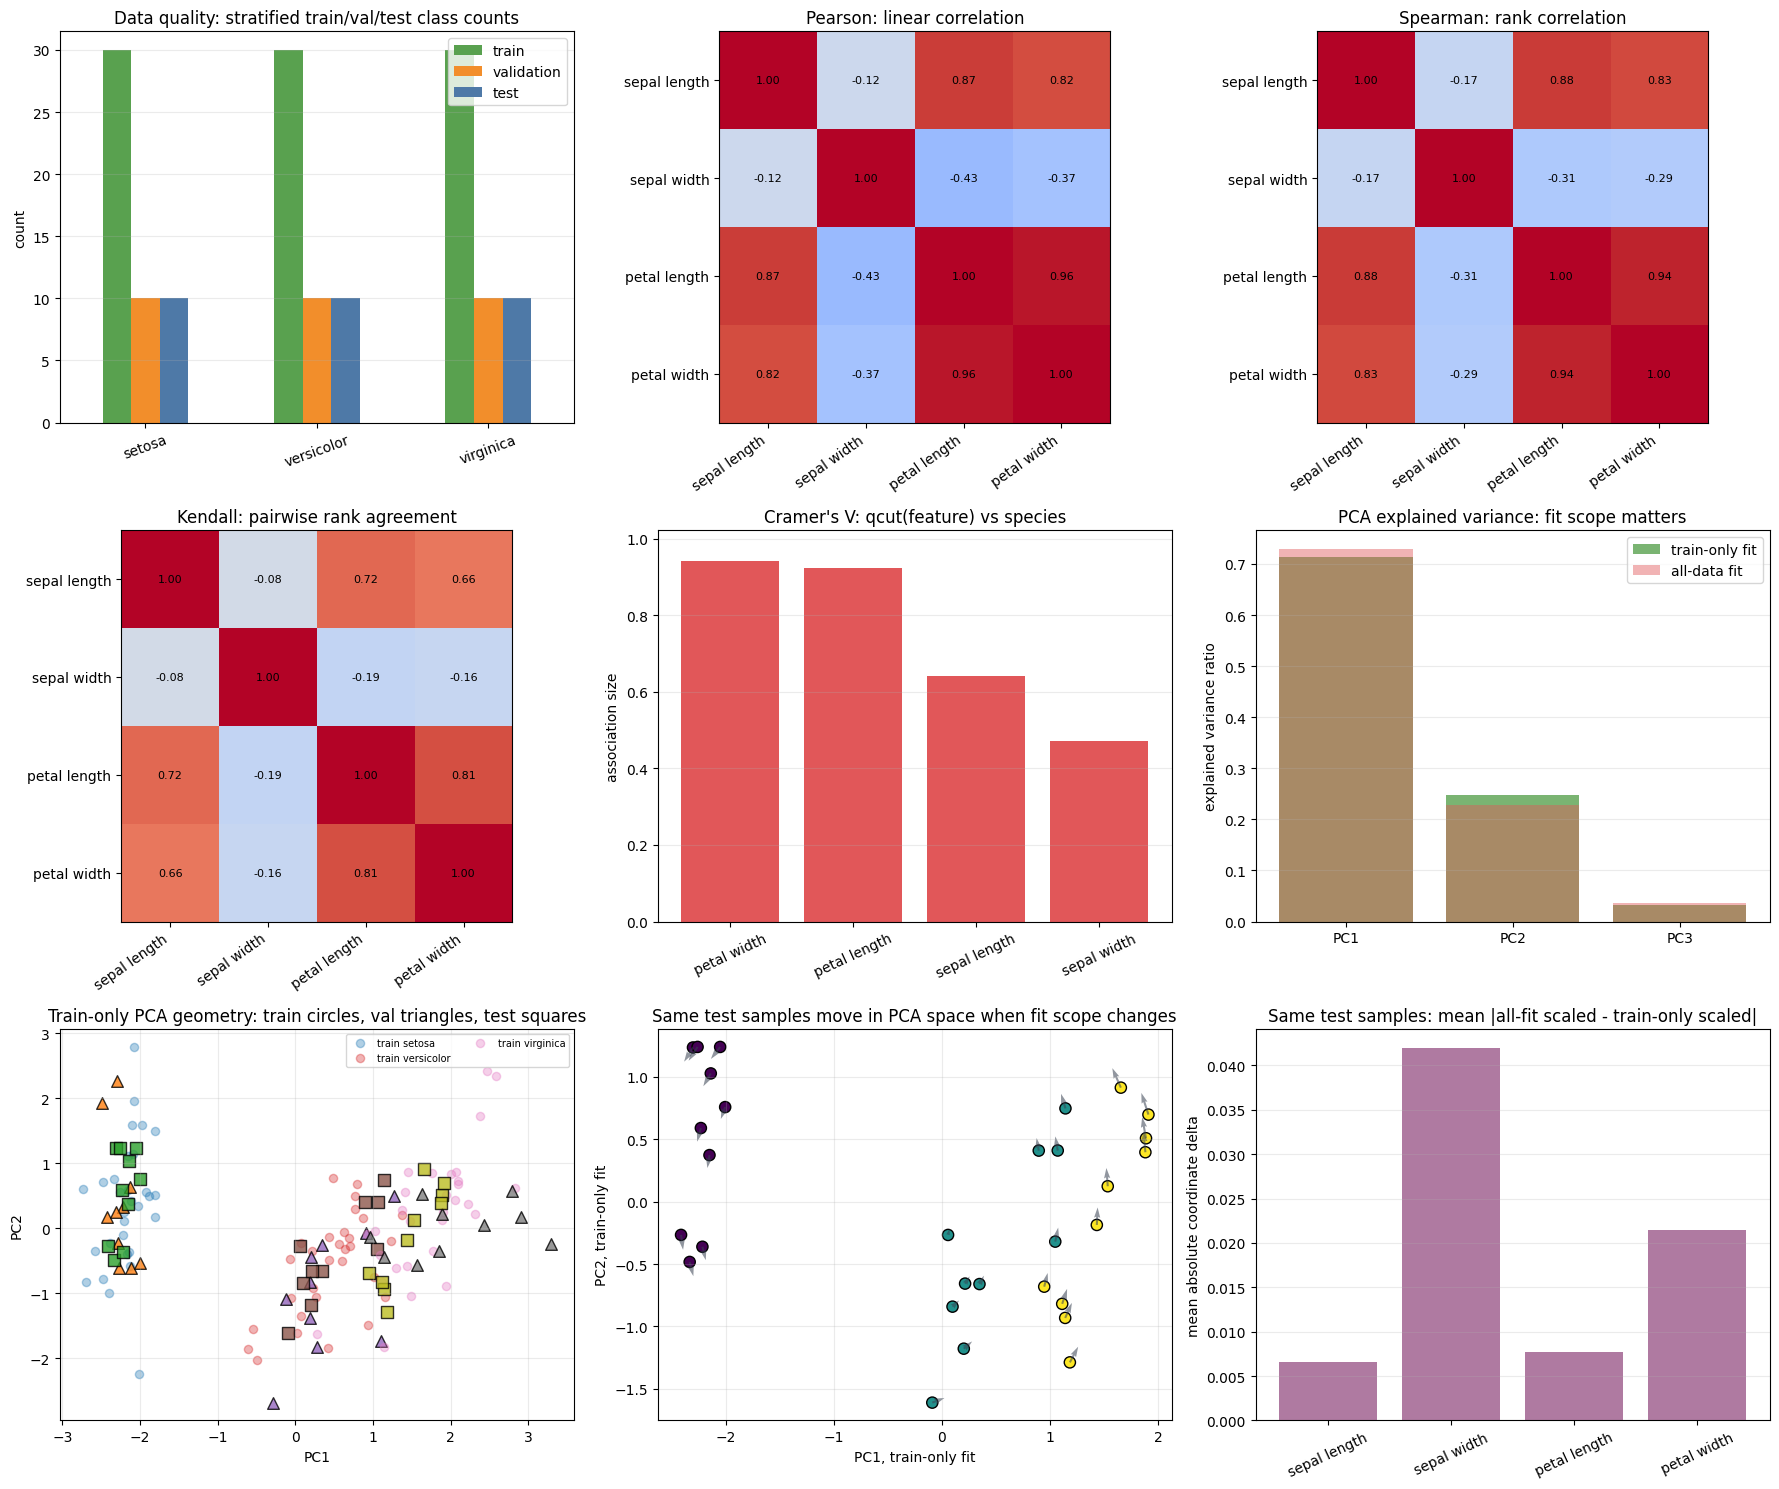

,optimizer,final_train_loss,val_loss,val_accuracy,val_macro_f1,test_loss_final_report_only,test_accuracy_final_report_only,test_macro_f1_final_report_only,selection_metric,test_used_for_selection,selected_by_validation
0,MySGD,0.130895,0.085454,1.000000,1.000000,0.128967,0.966667,0.966583,val_macro_f1,False,True
1,MyMomentum,0.088125,0.067916,0.966667,0.966583,0.085447,0.966667,0.966583,val_macro_f1,False,False
2,MyRMSProp,0.068650,0.049565,0.966667,0.966583,0.066846,0.966667,0.966583,val_macro_f1,False,False
3,MyAdam,0.061071,0.034749,1.000000,1.000000,0.054206,0.966667,0.966583,val_macro_f1,False,True


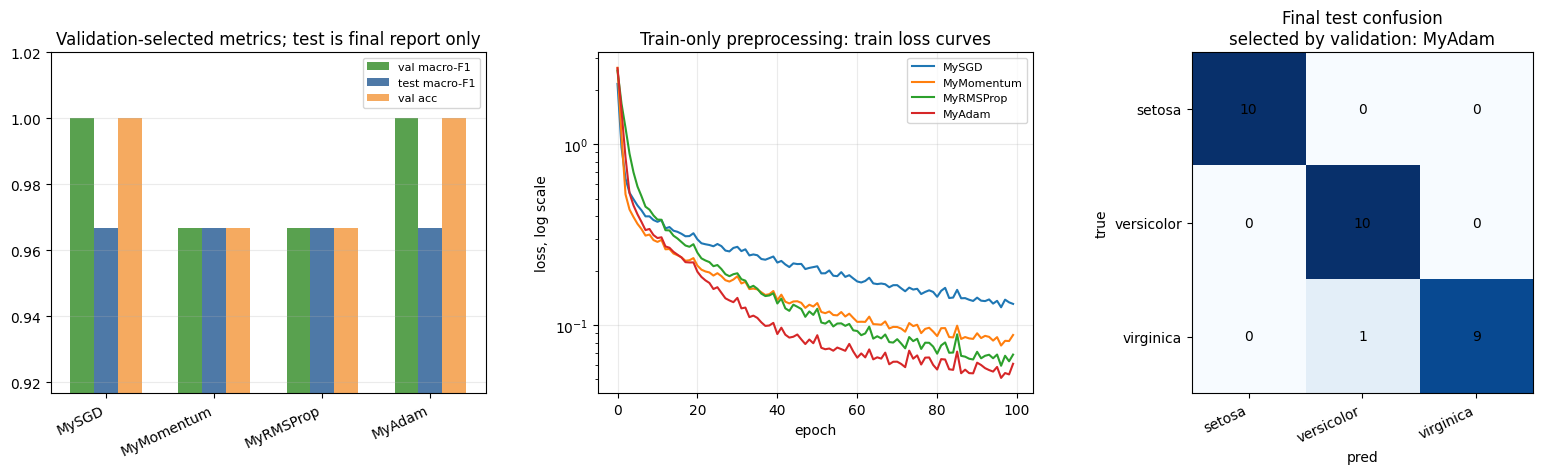

,answer_step,sentence
0,관찰,missing은 없고 class는 균형이다. petal length/width는 P...
1,원인,Iris species는 꽃잎 feature geometry에서 많이 분리된다. s...
2,제한,Iris는 작고 쉬운 데이터라 validation/test metric 차이가 작거...
3,결론,optimizer 비교 전에는 데이터 품질 확인 -> train/val/test s...


In [20]:
# [INSERTED] Iris preprocessing, data-quality, association, PCA validation audit
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: 전처리/정규화가 EDA, PCA, validation/test 결과, 그리고 optimizer 비교 공정성에 어떻게 연결되는지 보인다.
# 원본 Part 2의 official all-fit scaler는 homework 지시사항이므로 그대로 두고, 아래는 extension-only 연구 프로토콜이다.

from pathlib import Path
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

# [데이터 준비 | raw DataFrame]
# iris.data는 NumPy ndarray라 column 이름이 없다.
# DataFrame으로 감싸면 dtype, missing, duplicate, corr 같은 EDA 메소드를 column 단위로 바로 쓸 수 있다.
iris_prep_ext = load_iris()
X_iris_prep_ext = iris_prep_ext.data.astype(float)
y_iris_prep_ext = iris_prep_ext.target.astype(int)
feature_names_ext = list(iris_prep_ext.feature_names)
short_feature_names_ext = [name.replace(" (cm)", "") for name in feature_names_ext]
class_names_ext = list(iris_prep_ext.target_names)
iris_df_ext = pd.DataFrame(X_iris_prep_ext, columns=feature_names_ext)
iris_df_ext["species"] = pd.Categorical.from_codes(y_iris_prep_ext, class_names_ext)

# [데이터 품질성 검사 | quality gate]
# missing_count: 결측치가 있으면 imputer.fit 범위도 split-before-fit 원칙을 따라야 한다.
# duplicate_rows: 중복 행이 많으면 train/test가 거의 같은 샘플을 공유하는 효과가 생길 수 있다.
# class_balance_ratio: multiclass macro-F1를 볼 때 class imbalance가 얼마나 있는지 확인한다.
class_counts_ext = pd.Series(y_iris_prep_ext).value_counts().sort_index()
iris_quality_board_ext = pd.DataFrame([
    ["n_rows", len(iris_df_ext), "sample 수. split 후 class별 표본이 너무 적지 않은지 본다."],
    ["n_numeric_features", len(feature_names_ext), "Dense 입력 차원 Din=4와 직접 연결된다."],
    ["missing_cells", int(iris_df_ext.isna().sum().sum()), "0이면 imputation은 필요 없지만, 원칙은 train-only fit이다."],
    ["duplicate_rows", int(iris_df_ext.duplicated().sum()), "중복이 있으면 split leakage와 과대평가 가능성을 점검한다."],
    ["class_count_min", int(class_counts_ext.min()), "stratified split의 최소 class 표본 수."],
    ["class_count_max", int(class_counts_ext.max()), "class imbalance 확인용 최대 class 표본 수."],
    ["class_balance_ratio", float(class_counts_ext.min() / class_counts_ext.max()), "1에 가까울수록 class balance가 좋다."],
], columns=["check", "value", "why_it_matters"])
display(iris_quality_board_ext)
iris_quality_board_ext.to_csv(csv_dir_ext / "iris_data_quality_board_ext.csv", index=False)

# [feature quality table]
# Pandas describe/mean/std/skew는 feature scale과 분포를 수치로 요약한다.
# StandardScaler는 각 feature의 mean/std를 state로 저장하므로, 이 표가 곧 normalization 전 원자료의 상태다.
iris_feature_quality_ext = iris_df_ext[feature_names_ext].agg(["count", "mean", "std", "min", "max", "skew"]).T
iris_feature_quality_ext["missing_count"] = iris_df_ext[feature_names_ext].isna().sum().values
iris_feature_quality_ext["missing_rate"] = iris_feature_quality_ext["missing_count"] / len(iris_df_ext)
display(iris_feature_quality_ext)
iris_feature_quality_ext.to_csv(csv_dir_ext / "iris_feature_quality_ext.csv")

# [상관계수 3종 | Pearson / Spearman / Kendall]
# Pearson: 선형 관계를 본다. 값 자체의 직선적 증가/감소에 민감하다.
# Spearman: 순위(rank) 관계를 본다. 비선형이더라도 단조 증가/감소면 크게 나온다.
# Kendall: pairwise ordering 일관성을 본다. 작은 데이터에서 순위 안정성을 더 보수적으로 보여준다.
iris_corr_pearson_ext = iris_df_ext[feature_names_ext].corr(method="pearson")
iris_corr_spearman_ext = iris_df_ext[feature_names_ext].corr(method="spearman")
iris_corr_kendall_ext = iris_df_ext[feature_names_ext].corr(method="kendall")
iris_corr_pearson_ext.to_csv(csv_dir_ext / "iris_corr_pearson_ext.csv")
iris_corr_spearman_ext.to_csv(csv_dir_ext / "iris_corr_spearman_ext.csv")
iris_corr_kendall_ext.to_csv(csv_dir_ext / "iris_corr_kendall_ext.csv")

corr_rank_rows_ext = []
for method_name_ext, corr_df_ext in [
    ("Pearson", iris_corr_pearson_ext),
    ("Spearman", iris_corr_spearman_ext),
    ("Kendall", iris_corr_kendall_ext),
]:
    for i_ext, left_ext in enumerate(feature_names_ext):
        for j_ext, right_ext in enumerate(feature_names_ext):
            if j_ext <= i_ext:
                continue
            corr_rank_rows_ext.append({
                "method": method_name_ext,
                "feature_pair": f"{left_ext} vs {right_ext}",
                "corr": float(corr_df_ext.loc[left_ext, right_ext]),
                "abs_corr": float(abs(corr_df_ext.loc[left_ext, right_ext])),
            })
iris_corr_rank_ext = pd.DataFrame(corr_rank_rows_ext).sort_values(["method", "abs_corr"], ascending=[True, False])
display(iris_corr_rank_ext.groupby("method").head(3))
iris_corr_rank_ext.to_csv(csv_dir_ext / "iris_corr_pair_rank_ext.csv", index=False)

# [Cramer's V | categorical association]
# Cramer's V는 원래 categorical-categorical association 크기다.
# Iris feature는 numeric이므로 qcut으로 low/mid/high bin을 만든 뒤 species와의 연관성을 본다.
# 즉 "petal length bin을 알면 species를 얼마나 잘 좁힐 수 있는가"를 보는 EDA 장치다.
def cramers_v_from_table_ext(table_ext):
    observed_ext = table_ext.to_numpy(dtype=float)
    total_ext = observed_ext.sum()
    row_sum_ext = observed_ext.sum(axis=1, keepdims=True)
    col_sum_ext = observed_ext.sum(axis=0, keepdims=True)
    expected_ext = row_sum_ext @ col_sum_ext / total_ext
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2_ext = np.nansum(np.where(expected_ext > 0, (observed_ext - expected_ext) ** 2 / expected_ext, 0.0))
    phi2_ext = chi2_ext / total_ext
    denom_ext = min(observed_ext.shape[0] - 1, observed_ext.shape[1] - 1)
    return float(np.sqrt(phi2_ext / denom_ext)) if denom_ext > 0 else np.nan

cramer_rows_ext = []
for feature_ext in feature_names_ext:
    binned_ext = pd.qcut(iris_df_ext[feature_ext], q=3, duplicates="drop")
    table_ext = pd.crosstab(binned_ext, iris_df_ext["species"])
    cramer_rows_ext.append({
        "feature": feature_ext,
        "binning": "pd.qcut(q=3)",
        "cramers_v_with_species": cramers_v_from_table_ext(table_ext),
        "contingency_shape": str(table_ext.shape),
        "interpretation": "higher means binned feature is more associated with species label",
    })
iris_cramers_v_ext = pd.DataFrame(cramer_rows_ext).sort_values("cramers_v_with_species", ascending=False)
display(iris_cramers_v_ext)
iris_cramers_v_ext.to_csv(csv_dir_ext / "iris_cramers_v_species_ext.csv", index=False)

# [split protocol | train/validation/test]
# test는 final reporting용으로만 남겨두고, optimizer 선택/해석은 validation에서 한다.
# 이 분리 덕분에 "test accuracy가 높으니 이 optimizer를 고르자"라는 test 재사용을 피할 수 있다.
X_trainval_prep_ext, X_test_prep_ext, y_trainval_prep_ext, y_test_prep_ext = train_test_split(
    X_iris_prep_ext, y_iris_prep_ext, test_size=0.20, random_state=0, stratify=y_iris_prep_ext
)
X_train_prep_ext, X_val_prep_ext, y_train_prep_ext, y_val_prep_ext = train_test_split(
    X_trainval_prep_ext, y_trainval_prep_ext, test_size=0.25, random_state=0, stratify=y_trainval_prep_ext
)

# [normalization | train-only StandardScaler]
# StandardScaler.fit은 mean_/scale_을 학습한다. 이 state는 train에서만 배워야 한다.
# transform은 이미 배운 mean_/scale_을 적용하는 단계이므로 validation/test에 허용된다.
scaler_train_scope_ext = StandardScaler()
X_train_scaled_prep_ext = scaler_train_scope_ext.fit_transform(X_train_prep_ext)
X_val_scaled_prep_ext = scaler_train_scope_ext.transform(X_val_prep_ext)
X_test_scaled_prep_ext = scaler_train_scope_ext.transform(X_test_prep_ext)

# [wrong comparator | all-fit scaler]
# 이 값은 official score가 아니라 coordinate shift를 보여주는 비교용이다.
scaler_all_scope_ext = StandardScaler()
X_all_scaled_scope_ext = scaler_all_scope_ext.fit_transform(X_iris_prep_ext)
X_test_all_scaled_scope_ext = scaler_all_scope_ext.transform(X_test_prep_ext)
coordinate_delta_prep_ext = X_test_all_scaled_scope_ext - X_test_scaled_prep_ext
preprocessing_scope_audit_ext = pd.DataFrame({
    "feature": feature_names_ext,
    "train_fit_mean": scaler_train_scope_ext.mean_,
    "all_fit_mean": scaler_all_scope_ext.mean_,
    "all_minus_train_mean": scaler_all_scope_ext.mean_ - scaler_train_scope_ext.mean_,
    "train_fit_scale": scaler_train_scope_ext.scale_,
    "all_fit_scale": scaler_all_scope_ext.scale_,
    "all_minus_train_scale": scaler_all_scope_ext.scale_ - scaler_train_scope_ext.scale_,
    "mean_abs_test_scaled_delta": np.abs(coordinate_delta_prep_ext).mean(axis=0),
    "max_abs_test_scaled_delta": np.abs(coordinate_delta_prep_ext).max(axis=0),
})
display(preprocessing_scope_audit_ext)
preprocessing_scope_audit_ext.to_csv(csv_dir_ext / "iris_preprocessing_scope_audit_ext.csv", index=False)

# [PCA | train-only fit]
# PCA도 y를 쓰지 않는 unsupervised method지만 fit에서 component_/variance_를 배운다.
# 따라서 PCA.fit에도 test가 들어가면 projection 축이 test 분포를 본 상태가 된다.
pca_train_scope_ext = PCA(n_components=3, random_state=0)
train_pca_prep_ext = pca_train_scope_ext.fit_transform(X_train_scaled_prep_ext)
val_pca_prep_ext = pca_train_scope_ext.transform(X_val_scaled_prep_ext)
test_pca_right_ext = pca_train_scope_ext.transform(X_test_scaled_prep_ext)

pca_all_scope_ext = PCA(n_components=3, random_state=0)
pca_all_scope_ext.fit(X_all_scaled_scope_ext)
test_pca_wrong_ext = pca_all_scope_ext.transform(X_test_all_scaled_scope_ext)
pca_component_alignment_ext = np.abs(np.sum(pca_train_scope_ext.components_ * pca_all_scope_ext.components_, axis=1))

pca_variance_ext = pd.DataFrame({
    "PC": ["PC1", "PC2", "PC3"],
    "train_only_explained_variance_ratio": pca_train_scope_ext.explained_variance_ratio_,
    "all_fit_explained_variance_ratio": pca_all_scope_ext.explained_variance_ratio_,
    "component_alignment_abs_dot": pca_component_alignment_ext,
})
pca_loadings_ext = pd.DataFrame(
    pca_train_scope_ext.components_.T,
    index=feature_names_ext,
    columns=["PC1_loading", "PC2_loading", "PC3_loading"],
)
display(pca_variance_ext)
display(pca_loadings_ext)
pca_variance_ext.to_csv(csv_dir_ext / "iris_pca_variance_scope_ext.csv", index=False)
pca_loadings_ext.to_csv(csv_dir_ext / "iris_pca_loadings_train_only_ext.csv")

# [시각화 helper | annotated heatmap]
# Matplotlib imshow는 NumPy matrix를 그대로 색으로 보여준다.
# 여기서는 각 칸에 coefficient 숫자를 직접 적어서 학생이 색과 값을 함께 읽게 한다.
def annotated_heatmap_ext(ax_ext, matrix_ext, labels_ext, title_ext, cmap_ext="coolwarm", vmin_ext=-1, vmax_ext=1):
    im_ext = ax_ext.imshow(matrix_ext, cmap=cmap_ext, vmin=vmin_ext, vmax=vmax_ext)
    ax_ext.set_xticks(np.arange(len(labels_ext)))
    ax_ext.set_yticks(np.arange(len(labels_ext)))
    ax_ext.set_xticklabels(labels_ext, rotation=35, ha="right")
    ax_ext.set_yticklabels(labels_ext)
    ax_ext.set_title(title_ext)
    for i_ext in range(matrix_ext.shape[0]):
        for j_ext in range(matrix_ext.shape[1]):
            value_ext = matrix_ext[i_ext, j_ext]
            ax_ext.text(j_ext, i_ext, f"{value_ext:.2f}", ha="center", va="center", fontsize=8)
    return im_ext

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1) class/split quality board.
split_count_df_ext = pd.DataFrame({
    "train": pd.Series(y_train_prep_ext).value_counts().sort_index(),
    "validation": pd.Series(y_val_prep_ext).value_counts().sort_index(),
    "test": pd.Series(y_test_prep_ext).value_counts().sort_index(),
}).fillna(0)
split_count_df_ext.index = class_names_ext
split_count_df_ext.plot(kind="bar", ax=axes[0, 0], color=["#59a14f", "#f28e2b", "#4e79a7"])
axes[0, 0].set_title("Data quality: stratified train/val/test class counts")
axes[0, 0].set_ylabel("count")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 0].grid(axis="y", alpha=0.25)

# 2~4) correlation heatmaps.
annotated_heatmap_ext(axes[0, 1], iris_corr_pearson_ext.to_numpy(), short_feature_names_ext, "Pearson: linear correlation")
annotated_heatmap_ext(axes[0, 2], iris_corr_spearman_ext.to_numpy(), short_feature_names_ext, "Spearman: rank correlation")
annotated_heatmap_ext(axes[1, 0], iris_corr_kendall_ext.to_numpy(), short_feature_names_ext, "Kendall: pairwise rank agreement")

# 5) Cramer's V with species.
axes[1, 1].bar(
    [name.replace(" (cm)", "") for name in iris_cramers_v_ext["feature"]],
    iris_cramers_v_ext["cramers_v_with_species"],
    color="#e15759",
)
axes[1, 1].set_title("Cramer's V: qcut(feature) vs species")
axes[1, 1].set_ylabel("association size")
axes[1, 1].set_ylim(0, min(1.05, max(0.2, iris_cramers_v_ext["cramers_v_with_species"].max() + 0.08)))
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].grid(axis="y", alpha=0.25)

# 6) PCA variance.
axes[1, 2].bar(pca_variance_ext["PC"], pca_variance_ext["train_only_explained_variance_ratio"], alpha=0.80, label="train-only fit", color="#59a14f")
axes[1, 2].bar(pca_variance_ext["PC"], pca_variance_ext["all_fit_explained_variance_ratio"], alpha=0.45, label="all-data fit", color="#e15759")
axes[1, 2].set_title("PCA explained variance: fit scope matters")
axes[1, 2].set_ylabel("explained variance ratio")
axes[1, 2].legend()
axes[1, 2].grid(axis="y", alpha=0.25)

# 7) train-only PCA scatter with train/validation/test marker separation.
for cls_ext, class_name_ext in enumerate(class_names_ext):
    mask_train_ext = y_train_prep_ext == cls_ext
    mask_val_ext = y_val_prep_ext == cls_ext
    mask_test_ext = y_test_prep_ext == cls_ext
    axes[2, 0].scatter(train_pca_prep_ext[mask_train_ext, 0], train_pca_prep_ext[mask_train_ext, 1], s=35, alpha=0.35, label=f"train {class_name_ext}")
    axes[2, 0].scatter(val_pca_prep_ext[mask_val_ext, 0], val_pca_prep_ext[mask_val_ext, 1], s=70, marker="^", alpha=0.80, edgecolor="black")
    axes[2, 0].scatter(test_pca_right_ext[mask_test_ext, 0], test_pca_right_ext[mask_test_ext, 1], s=70, marker="s", alpha=0.80, edgecolor="black")
axes[2, 0].set_title("Train-only PCA geometry: train circles, val triangles, test squares")
axes[2, 0].set_xlabel("PC1")
axes[2, 0].set_ylabel("PC2")
axes[2, 0].grid(alpha=0.25)
axes[2, 0].legend(fontsize=7, ncol=2)

# 8) PCA coordinate shift: train-only fit -> all-fit.
axes[2, 1].scatter(test_pca_right_ext[:, 0], test_pca_right_ext[:, 1], c=y_test_prep_ext, cmap="viridis", s=65, edgecolor="black")
axes[2, 1].quiver(
    test_pca_right_ext[:, 0],
    test_pca_right_ext[:, 1],
    test_pca_wrong_ext[:, 0] - test_pca_right_ext[:, 0],
    test_pca_wrong_ext[:, 1] - test_pca_right_ext[:, 1],
    angles="xy", scale_units="xy", scale=1, color="#374151", alpha=0.55, width=0.004,
)
axes[2, 1].set_title("Same test samples move in PCA space when fit scope changes")
axes[2, 1].set_xlabel("PC1, train-only fit")
axes[2, 1].set_ylabel("PC2, train-only fit")
axes[2, 1].grid(alpha=0.25)

# 9) scaled coordinate delta by feature.
axes[2, 2].bar(short_feature_names_ext, preprocessing_scope_audit_ext["mean_abs_test_scaled_delta"], color="#af7aa1")
axes[2, 2].set_title("Same test samples: mean |all-fit scaled - train-only scaled|")
axes[2, 2].set_ylabel("mean absolute coordinate delta")
axes[2, 2].tick_params(axis="x", rotation=25)
axes[2, 2].grid(axis="y", alpha=0.25)

plt.tight_layout()
fig.savefig(fig_dir_ext / "iris_preprocessing_association_pca_audit_ext.png", dpi=170)
plt.show()

# [validation/test protocol | optimizer 비교]
# Optimizer는 X/y를 직접 보지 않는다. 하지만 scaler/PCA가 만든 X 좌표가 달라지면 logits, SoftmaxCE gradient, dW/db가 달라진다.
# 따라서 전처리 fit 범위는 optimizer 비교의 공정성 조건이다.
def one_hot_ext(y_ext, k_ext):
    return np.eye(k_ext)[y_ext]

def evaluate_iris_protocol_ext(net_ext, X_eval_ext, y_eval_ext):
    logits_ext = net_ext.forward(X_eval_ext)
    y_pred_ext = logits_ext.argmax(axis=1)
    Y_eval_ext = one_hot_ext(y_eval_ext, 3)
    loss_fn_eval_ext = SoftmaxCE()
    loss_ext = loss_fn_eval_ext.forward(logits_ext, Y_eval_ext)
    return {
        "loss": float(loss_ext),
        "accuracy": float(accuracy_score(y_eval_ext, y_pred_ext)),
        "macro_f1": float(f1_score(y_eval_ext, y_pred_ext, average="macro")),
        "y_pred": y_pred_ext,
    }

def train_iris_valtest_protocol_ext(optimizer_name_ext, OptCls_ext, opt_kwargs_ext, epochs_ext=100):
    np.random.seed(0)
    net_ext = Network()
    net_ext.add(Dense(4, 16, seed=0))
    net_ext.add(ReLU())
    net_ext.add(Dense(16, 3, seed=1))
    loss_fn_ext = SoftmaxCE()
    opt_ext = OptCls_ext(**opt_kwargs_ext)
    np.random.seed(0)
    history_ext = fit(
        net_ext,
        X_train_scaled_prep_ext,
        one_hot_ext(y_train_prep_ext, 3),
        loss_fn_ext,
        opt_ext,
        epochs=epochs_ext,
        batch_size=16,
        verbose=False,
    )
    val_eval_ext = evaluate_iris_protocol_ext(net_ext, X_val_scaled_prep_ext, y_val_prep_ext)
    test_eval_ext = evaluate_iris_protocol_ext(net_ext, X_test_scaled_prep_ext, y_test_prep_ext)
    row_ext = {
        "optimizer": optimizer_name_ext,
        "final_train_loss": float(history_ext["loss"][-1]),
        "val_loss": val_eval_ext["loss"],
        "val_accuracy": val_eval_ext["accuracy"],
        "val_macro_f1": val_eval_ext["macro_f1"],
        "test_loss_final_report_only": test_eval_ext["loss"],
        "test_accuracy_final_report_only": test_eval_ext["accuracy"],
        "test_macro_f1_final_report_only": test_eval_ext["macro_f1"],
        "selection_metric": "val_macro_f1",
        "test_used_for_selection": False,
    }
    return row_ext, history_ext, test_eval_ext["y_pred"]

protocol_rows_ext = []
protocol_histories_ext = {}
protocol_test_preds_ext = {}
for optimizer_name_ext, OptCls_ext, opt_kwargs_ext in configs:
    row_ext, history_ext, test_pred_ext = train_iris_valtest_protocol_ext(optimizer_name_ext, OptCls_ext, opt_kwargs_ext)
    protocol_rows_ext.append(row_ext)
    protocol_histories_ext[optimizer_name_ext] = history_ext
    protocol_test_preds_ext[optimizer_name_ext] = test_pred_ext

iris_validation_test_protocol_ext = pd.DataFrame(protocol_rows_ext)
best_val_macro_f1_ext = iris_validation_test_protocol_ext["val_macro_f1"].max()
iris_validation_test_protocol_ext["selected_by_validation"] = iris_validation_test_protocol_ext["val_macro_f1"] == best_val_macro_f1_ext
display(iris_validation_test_protocol_ext)
iris_validation_test_protocol_ext.to_csv(csv_dir_ext / "iris_validation_test_protocol_ext.csv", index=False)

selected_optimizer_ext = iris_validation_test_protocol_ext.sort_values(
    ["val_macro_f1", "val_accuracy", "final_train_loss"], ascending=[False, False, True]
).iloc[0]["optimizer"]
selected_cm_ext = confusion_matrix(y_test_prep_ext, protocol_test_preds_ext[selected_optimizer_ext])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
metric_x_ext = np.arange(len(iris_validation_test_protocol_ext))
bar_width_ext = 0.22
axes[0].bar(metric_x_ext - bar_width_ext, iris_validation_test_protocol_ext["val_macro_f1"], width=bar_width_ext, label="val macro-F1", color="#59a14f")
axes[0].bar(metric_x_ext, iris_validation_test_protocol_ext["test_macro_f1_final_report_only"], width=bar_width_ext, label="test macro-F1", color="#4e79a7")
axes[0].bar(metric_x_ext + bar_width_ext, iris_validation_test_protocol_ext["val_accuracy"], width=bar_width_ext, label="val acc", color="#f28e2b", alpha=0.75)
metric_values_ext = pd.concat([
    iris_validation_test_protocol_ext["val_macro_f1"],
    iris_validation_test_protocol_ext["test_macro_f1_final_report_only"],
    iris_validation_test_protocol_ext["val_accuracy"],
])
metric_min_ext = max(0.0, float(metric_values_ext.min()) - 0.05)
metric_max_ext = min(1.02, float(metric_values_ext.max()) + 0.03)
if metric_max_ext - metric_min_ext < 0.08:
    center_ext = (metric_max_ext + metric_min_ext) / 2
    metric_min_ext = max(0.0, center_ext - 0.04)
    metric_max_ext = min(1.02, center_ext + 0.04)
axes[0].set_ylim(metric_min_ext, metric_max_ext)
axes[0].set_xticks(metric_x_ext)
axes[0].set_xticklabels(iris_validation_test_protocol_ext["optimizer"], rotation=25, ha="right")
axes[0].set_title("Validation-selected metrics; test is final report only")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.25)

for optimizer_name_ext, history_ext in protocol_histories_ext.items():
    axes[1].plot(history_ext["loss"], label=optimizer_name_ext)
axes[1].set_yscale("log")
axes[1].set_title("Train-only preprocessing: train loss curves")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss, log scale")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].imshow(selected_cm_ext, cmap="Blues")
axes[2].set_title(f"Final test confusion\nselected by validation: {selected_optimizer_ext}")
axes[2].set_xlabel("pred")
axes[2].set_ylabel("true")
axes[2].set_xticks(range(3))
axes[2].set_yticks(range(3))
axes[2].set_xticklabels(class_names_ext, rotation=25, ha="right")
axes[2].set_yticklabels(class_names_ext)
for i_ext in range(selected_cm_ext.shape[0]):
    for j_ext in range(selected_cm_ext.shape[1]):
        axes[2].text(j_ext, i_ext, int(selected_cm_ext[i_ext, j_ext]), ha="center", va="center")

plt.tight_layout()
fig.savefig(fig_dir_ext / "iris_validation_test_protocol_ext.png", dpi=170)
plt.show()

iris_preprocessing_eda_validation_interpretation_ext = pd.DataFrame([
    ["관찰", "missing은 없고 class는 균형이다. petal length/width는 Pearson/Spearman/Kendall에서 강하고, qcut 후 Cramer's V도 species와 강한 연관성을 보인다."],
    ["원인", "Iris species는 꽃잎 feature geometry에서 많이 분리된다. scaling과 PCA는 이 geometry를 다른 좌표계로 옮기는 fit/transform 객체다."],
    ["제한", "Iris는 작고 쉬운 데이터라 validation/test metric 차이가 작거나 tie가 날 수 있다. 그래서 수치보다 프로토콜과 좌표 변화가 핵심이다."],
    ["결론", "optimizer 비교 전에는 데이터 품질 확인 -> train/val/test split -> train-only scaler/PCA fit -> validation 선택 -> final test reporting 순서를 지킨다."],
], columns=["answer_step", "sentence"])
display(iris_preprocessing_eda_validation_interpretation_ext)
iris_preprocessing_eda_validation_interpretation_ext.to_csv(csv_dir_ext / "iris_preprocessing_eda_validation_interpretation_ext.csv", index=False)


## [INSERTED] MNIST/Digits error diagnostics

원본 Part 3 MNIST 결과는 건드리지 않는다. 확장 진단은 실행 시간을 줄이기 위해 `load_digits`를 extension-only fallback으로 사용하며, 이것은 원본 MNIST 실험을 대체하지 않는다.


optimizer,MyAdam,MyRMSProp
class,,
0,0.977778,0.955556
1,0.913043,0.934783
2,0.863636,0.886364
3,0.934783,0.934783
4,0.911111,0.933333
5,0.869565,0.934783
6,0.933333,0.955556
7,1.000000,1.000000
8,0.767442,0.744186


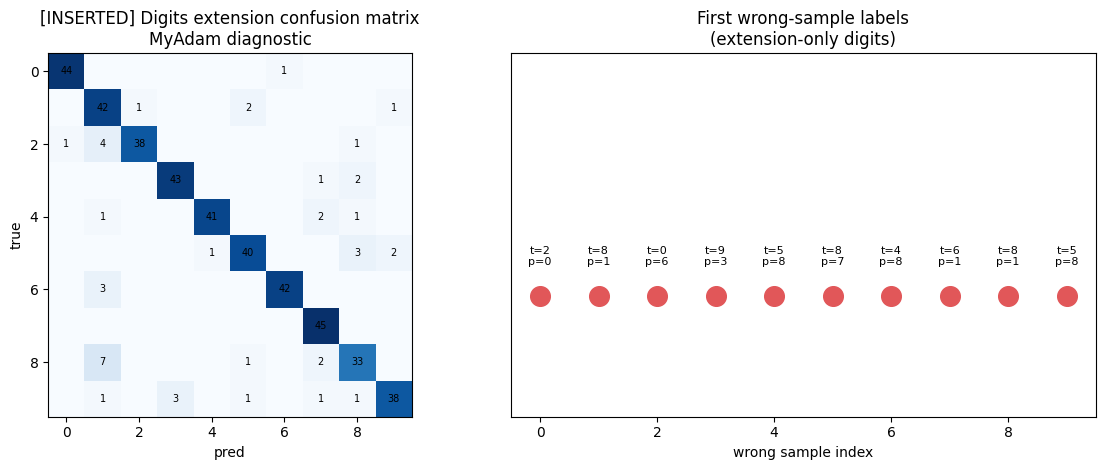

In [21]:
# [INSERTED] MNIST/Digits error diagnostics
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

digits_ext = load_digits()
X_digits_ext = digits_ext.data.astype(float) / 16.0
Y_digits_ext = np.eye(10)[digits_ext.target]
X_digits_train_ext, X_digits_test_ext, Y_digits_train_ext, Y_digits_test_ext = train_test_split(
    X_digits_ext, Y_digits_ext, test_size=0.25, random_state=SEED if 'SEED' in globals() else 0, stratify=digits_ext.target
)

def train_digits_diag_ext(OptCls, **kw):
    np.random.seed(0)
    net_ext = Network()
    net_ext.add(Dense(64, 32))
    net_ext.add(ReLU())
    net_ext.add(Dense(32, 10))
    loss_fn_ext = SoftmaxCE()
    opt_ext = OptCls(**kw)
    np.random.seed(0)
    hist_ext = fit(net_ext, X_digits_train_ext, Y_digits_train_ext, loss_fn_ext, opt_ext, epochs=12, batch_size=64, verbose=False)
    logits_ext = net_ext.forward(X_digits_test_ext)
    probs_ext = softmax_ext(logits_ext)
    y_true_ext = Y_digits_test_ext.argmax(axis=1)
    y_pred_ext = probs_ext.argmax(axis=1)
    return hist_ext, y_true_ext, y_pred_ext

digits_rows_ext = []
for name_ext, OptCls_ext, kw_ext in [("MyAdam", MyAdam, dict(lr=0.001)), ("MyRMSProp", MyRMSProp, dict(lr=0.001))]:
    hist_ext, y_true_ext, y_pred_ext = train_digits_diag_ext(OptCls_ext, **kw_ext)
    cm_ext = confusion_matrix(y_true_ext, y_pred_ext)
    per_class_acc_ext = cm_ext.diagonal() / np.maximum(cm_ext.sum(axis=1), 1)
    for cls_ext, acc_ext in enumerate(per_class_acc_ext):
        digits_rows_ext.append({"optimizer": name_ext, "class": cls_ext, "per_class_accuracy": float(acc_ext)})
    if name_ext == "MyAdam":
        digits_cm_ext = cm_ext
        digits_y_true_ext = y_true_ext
        digits_y_pred_ext = y_pred_ext

digits_class_diag_ext = pd.DataFrame(digits_rows_ext)
display(digits_class_diag_ext.pivot(index="class", columns="optimizer", values="per_class_accuracy"))
digits_class_diag_ext.to_csv(csv_dir_ext / "digits_extension_per_class_accuracy.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].imshow(digits_cm_ext, cmap="Blues")
axes[0].set_title("[INSERTED] Digits extension confusion matrix\nMyAdam diagnostic")
axes[0].set_xlabel("pred")
axes[0].set_ylabel("true")
for i_ext in range(10):
    for j_ext in range(10):
        if digits_cm_ext[i_ext, j_ext] > 0:
            axes[0].text(j_ext, i_ext, int(digits_cm_ext[i_ext, j_ext]), ha="center", va="center", fontsize=7)

wrong_idx_ext = np.where(digits_y_true_ext != digits_y_pred_ext)[0][:10]
if len(wrong_idx_ext) > 0:
    for k_ext, idx_ext in enumerate(wrong_idx_ext[:10]):
        axes[1].scatter(k_ext, 0, s=200, c="#e15759")
        axes[1].text(k_ext, 0.05, f"t={digits_y_true_ext[idx_ext]}\np={digits_y_pred_ext[idx_ext]}", ha="center", fontsize=8)
axes[1].set_xlim(-0.5, 9.5)
axes[1].set_ylim(-0.2, 0.4)
axes[1].set_yticks([])
axes[1].set_title("First wrong-sample labels\n(extension-only digits)")
axes[1].set_xlabel("wrong sample index")
plt.tight_layout()
fig.savefig(fig_dir_ext / "digits_extension_error_diagnostics.png", dpi=160)
plt.show()


## [INSERTED] LR sensitivity table and interpretation board

원본 Part 4 plot에 쓰인 `sgd_accs`, `adam_accs`를 표로 정리하고, best/worst/sensitivity range를 계산한다. 공식 plot을 대체하지 않고 해석 보조판만 제공한다.


,lr,MySGD_test_acc,MyAdam_test_acc,Adam_minus_SGD
0,0.0001,0.422222,0.444444,0.022222
1,0.0010,0.688889,0.955556,0.266667
2,0.0100,0.911111,0.977778,0.066667
3,0.1000,0.977778,0.977778,0.000000


,optimizer,best_lr,best_acc,worst_acc,sensitivity_range
0,MySGD,0.10,0.977778,0.422222,0.555556
1,MyAdam,0.01,0.977778,0.444444,0.533333


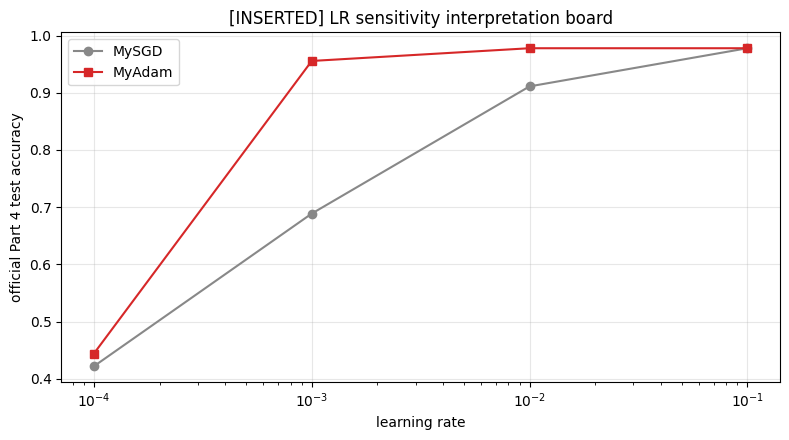

In [22]:
# [INSERTED] LR sensitivity table and interpretation board
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

lr_sensitivity_df_ext = pd.DataFrame({
    "lr": lrs,
    "MySGD_test_acc": sgd_accs,
    "MyAdam_test_acc": adam_accs,
})
lr_sensitivity_df_ext["Adam_minus_SGD"] = lr_sensitivity_df_ext["MyAdam_test_acc"] - lr_sensitivity_df_ext["MySGD_test_acc"]
display(lr_sensitivity_df_ext)
lr_sensitivity_df_ext.to_csv(csv_dir_ext / "lr_sensitivity_official_part4.csv", index=False)

lr_summary_ext = pd.DataFrame([
    ["MySGD", lrs[int(np.argmax(sgd_accs))], float(np.max(sgd_accs)), float(np.min(sgd_accs)), float(np.max(sgd_accs) - np.min(sgd_accs))],
    ["MyAdam", lrs[int(np.argmax(adam_accs))], float(np.max(adam_accs)), float(np.min(adam_accs)), float(np.max(adam_accs) - np.min(adam_accs))],
], columns=["optimizer", "best_lr", "best_acc", "worst_acc", "sensitivity_range"])
display(lr_summary_ext)
lr_summary_ext.to_csv(csv_dir_ext / "lr_sensitivity_summary_ext.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lrs, sgd_accs, "o-", label="MySGD", color="#888")
ax.plot(lrs, adam_accs, "s-", label="MyAdam", color="#d62728")
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("official Part 4 test accuracy")
ax.set_title("[INSERTED] LR sensitivity interpretation board")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir_ext / "lr_sensitivity_interpretation_board.png", dpi=160)
plt.show()


## [INSERTED] V04-style optimizer trajectory and state dashboard

이 확장 cell은 PREP notebook의 V04 시각화 원칙을 homework 하단부 Part 4 해석에 붙인다. 원본 Part 4는 `sgd_accs`, `adam_accs`로 learning-rate sensitivity를 공식 산출한다. 이 cell은 그 공식 결과를 대체하지 않고, 같은 gradient를 네 optimizer가 어떻게 다르게 해석하는지 2D quadratic surface에서 보조 진단한다.

요청한 네 가지 관점을 한 figure pack으로 고정한다.

- `3D surface view`: loss 표면 위를 내려오는 전체 공간감을 확인한다.
- `top contour view`: optimizer별 zig-zag, overshoot, 곡률 방향 이동을 가장 직접적으로 본다.
- `front w0-loss projection`: 완만한 축 `w0`를 따라 loss가 어떻게 줄어드는지 본다.
- `side w1-loss projection`: 가파른 축 `w1`에서 초반 loss 감소와 진동을 본다.

핵심 경계:

```text
Optimizer는 X/y를 보지 않는다.
Optimizer는 param과 grad만 읽고, update rule과 state에 따라 param을 이동시킨다.
```

따라서 여기서 쓰는 2D `w`는 실제 Iris/MNIST weight가 아니라, optimizer update rule을 눈으로 분리하기 위한 synthetic parameter vector다.


,optimizer,step,w0,w1,loss,grad_norm,update_norm,state_norm
45,MySGD,45,0.960365,3.311703e-25,0.092230,0.192073,0.035864,0.000000
91,MyMomentum,45,-0.501832,-9.272764e-02,0.042380,0.384250,0.113996,0.113996
137,MyRMSProp,45,1.326116,1.876666e-02,0.176563,0.275642,0.055935,2.035072
183,MyAdam,45,1.796175,-5.654882e-02,0.329020,0.424516,0.057912,1.594512


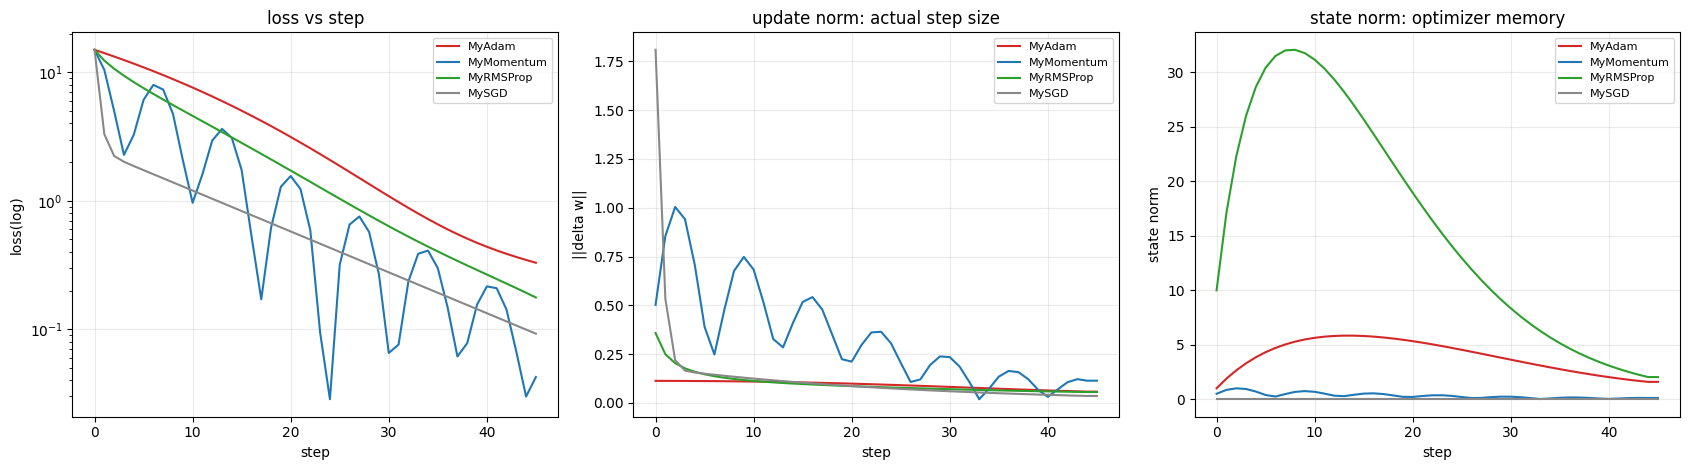

,view,what it reveals,answer sentence cue
0,3D surface view,loss surface 전체 공간감,optimizer path가 valley를 향해 내려오는 전체 방향을 설명한다.
1,top contour view,zig-zag와 overshoot,"w0/w1 평면에서 경로가 흔들리는지, 곡률 방향을 따라 안정적으로 가는지 본다."
2,front w0-loss projection,완만한 축 w0의 loss 감소,w0는 gradient가 작아 천천히 줄 수 있으므로 optimizer state가...
3,side w1-loss projection,가파른 축 w1의 초반 감소/진동,steep direction에서 큰 gradient가 overshoot를 만들거나 ...


,step,interpretation
0,관찰,같은 quadratic gradient를 받아도 네 optimizer의 contou...
1,원인,"SGD는 현재 gradient만 쓰고, Momentum/RMSProp/Adam은 v..."
2,제한,이 surface는 실제 Iris/MNIST loss가 아니라 update rule...
3,결론,Part 4의 lr sensitivity는 단순 lr 숫자 비교가 아니라 updat...


In [23]:
# [INSERTED] V04-style optimizer trajectory and state dashboard
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: Part 4의 lr sensitivity 결과를 "왜 optimizer별 update path가 다른가"로 연결한다.
# 원본 Part 4 변수(lrs, sgd_accs, adam_accs)는 그대로 두고, extension-only synthetic 2D surface를 사용한다.
# 이 cell은 공식 점수 산출을 대체하지 않는다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

# [수학/코드 해설 | quadratic surface]
# L(w)=0.1*w0^2 + 2.0*w1^2는 w0 방향은 완만하고 w1 방향은 가파른 타원형 loss surface다.
# 같은 gradient descent라도 steep direction에서 overshoot/zig-zag가 잘 보이므로 optimizer path 설명에 적합하다.
def quad_loss_hw_ext(w_ext):
    return 0.1 * w_ext[0] ** 2 + 2.0 * w_ext[1] ** 2

def quad_grad_hw_ext(w_ext):
    # analytic gradient: dL/dw0=0.2*w0, dL/dw1=4.0*w1
    return np.array([0.2 * w_ext[0], 4.0 * w_ext[1]])

class VectorLayerExt:
    # [인터페이스 설명 | params_and_grads]
    # homework Optimizer.step(net)은 net.layers를 돌면서 layer.params_and_grads()를 호출한다.
    # 실제 Dense가 아니어도 같은 interface만 제공하면 optimizer가 param/grad pair만 읽는다는 사실을 확인할 수 있다.
    def __init__(self, w_ext):
        self.w_ext = np.array(w_ext, dtype=float)
        self.grad_ext = np.zeros_like(self.w_ext)
    def params_and_grads(self):
        return [(self.w_ext, self.grad_ext)]

class VectorNetExt:
    def __init__(self, w_ext):
        self.layer_ext = VectorLayerExt(w_ext)
        self.layers = [self.layer_ext]

def run_vector_optimizer_path_ext(OptCls_ext, opt_kwargs_ext, start_ext=(5.0, 2.5), steps_ext=45):
    # [실험 원칙 | same start, same gradient]
    # 모든 optimizer는 같은 시작점과 같은 quad_grad를 받는다.
    # path 차이는 gradient 자체가 아니라 update rule/state 차이에서 나온다.
    opt_ext = OptCls_ext(**opt_kwargs_ext)
    net_ext = VectorNetExt(start_ext)
    rows_ext = []
    for step_ext in range(steps_ext + 1):
        w_before_ext = net_ext.layer_ext.w_ext.copy()
        grad_ext = quad_grad_hw_ext(w_before_ext)
        net_ext.layer_ext.grad_ext = grad_ext.copy()
        rows_ext.append({
            "step": step_ext,
            "w0": float(w_before_ext[0]),
            "w1": float(w_before_ext[1]),
            "loss": float(quad_loss_hw_ext(w_before_ext)),
            "grad_norm": float(np.linalg.norm(grad_ext)),
            "update_norm": np.nan,
            "state_norm": np.nan,
        })
        if step_ext == steps_ext:
            break
        opt_ext.step(net_ext)
        update_ext = net_ext.layer_ext.w_ext - w_before_ext
        # [상태 해설 | state_norm]
        # Momentum은 v, RMSProp은 s, Adam은 m/v를 dict state로 가진다.
        # state_norm은 trajectory만으로 보이지 않는 optimizer 내부 기억의 크기를 요약한다.
        state_chunks_ext = []
        for attr_ext in ["v", "s", "m"]:
            state_obj_ext = getattr(opt_ext, attr_ext, None)
            if isinstance(state_obj_ext, dict):
                for value_ext in state_obj_ext.values():
                    state_chunks_ext.append(np.asarray(value_ext).ravel())
        state_norm_ext = float(np.linalg.norm(np.concatenate(state_chunks_ext))) if state_chunks_ext else 0.0
        rows_ext[-1]["update_norm"] = float(np.linalg.norm(update_ext))
        rows_ext[-1]["state_norm"] = state_norm_ext
    return pd.DataFrame(rows_ext)

optimizer_path_specs_ext = [
    ("MySGD", MySGD, dict(lr=0.18)),
    ("MyMomentum", MyMomentum, dict(lr=0.05, mu=0.9)),
    ("MyRMSProp", MyRMSProp, dict(lr=0.08)),
    ("MyAdam", MyAdam, dict(lr=0.08)),
]

trajectory_tables_ext = []
for opt_name_ext, OptCls_ext, kwargs_ext in optimizer_path_specs_ext:
    path_df_ext = run_vector_optimizer_path_ext(OptCls_ext, kwargs_ext)
    path_df_ext["optimizer"] = opt_name_ext
    path_df_ext["lr_used_in_surface"] = kwargs_ext.get("lr")
    trajectory_tables_ext.append(path_df_ext)
optimizer_trajectory_df_ext = pd.concat(trajectory_tables_ext, ignore_index=True)
# [표 안정화 | final row NaN 제거]
# run_vector_optimizer_path_ext는 마지막 위치를 기록하기 위해 마지막 step에서는 update를 한 번 더 수행하지 않는다.
# 그래서 final row의 update_norm/state_norm은 원래 NaN이 될 수 있다.
# 제출용 summary table에서는 보기 나쁘므로 optimizer별 직전 update/state 값을 carry-forward한다.
optimizer_trajectory_df_ext[["update_norm", "state_norm"]] = (
    optimizer_trajectory_df_ext
    .groupby("optimizer")[["update_norm", "state_norm"]]
    .ffill()
    .fillna(0.0)
)
optimizer_trajectory_df_ext.to_csv(csv_dir_ext / "v04_optimizer_trajectory_state_ext.csv", index=False)
display(optimizer_trajectory_df_ext.groupby("optimizer").tail(1)[["optimizer", "step", "w0", "w1", "loss", "grad_norm", "update_norm", "state_norm"]])

# [시각화 | requested 4-view surface pack]
# 사용자가 요청한 네 관점을 같은 optimizer_trajectory_df_ext 원자료에서 만든다.
# 1) 3D surface view: 전체 loss surface 공간감
# 2) top contour view: zig-zag/overshoot를 가장 선명하게 확인
# 3) front w0-loss projection: 완만한 w0 축을 따라 loss가 줄어드는 방식
# 4) side w1-loss projection: 가파른 w1 축에서 초반 loss 감소와 진동
w0_grid_ext = np.linspace(-6, 6, 180)
w1_grid_ext = np.linspace(-3, 3, 180)
W0_ext, W1_ext = np.meshgrid(w0_grid_ext, w1_grid_ext)
Z_ext = 0.1 * W0_ext ** 2 + 2.0 * W1_ext ** 2
colors_ext = {"MySGD": "#888888", "MyMomentum": "#1f77b4", "MyRMSProp": "#2ca02c", "MyAdam": "#d62728"}

fig = plt.figure(figsize=(18, 12))
ax_surface_ext = fig.add_subplot(2, 2, 1, projection="3d")
ax_top_ext = fig.add_subplot(2, 2, 2)
ax_front_ext = fig.add_subplot(2, 2, 3)
ax_side_ext = fig.add_subplot(2, 2, 4)

# [3D surface view]
# plot_surface는 W0/W1 grid와 그 위의 loss Z를 3D 표면으로 만든다.
# path는 (w0,w1,loss) 좌표로 얹어 optimizer가 loss valley를 어떻게 내려오는지 전체 공간감으로 보여준다.
ax_surface_ext.plot_surface(W0_ext, W1_ext, Z_ext, cmap="viridis", alpha=0.35, linewidth=0, antialiased=True)
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_surface_ext.plot(
        group_ext["w0"],
        group_ext["w1"],
        group_ext["loss"],
        marker="o",
        markersize=3,
        lw=2,
        label=opt_name_ext,
        color=colors_ext[opt_name_ext],
    )
ax_surface_ext.view_init(elev=32, azim=-55)
ax_surface_ext.set_title("3D surface view: optimizer path on loss surface")
ax_surface_ext.set_xlabel("w0, shallow axis")
ax_surface_ext.set_ylabel("w1, steep axis")
ax_surface_ext.set_zlabel("loss")
ax_surface_ext.legend(fontsize=8)

# [Top contour view]
# contour는 3D를 위에서 눌러 본 그림이다.
# zig-zag와 overshoot는 높이감보다 경로의 좌우 흔들림을 봐야 하므로 top view가 가장 좋다.
ax_top_ext.contour(W0_ext, W1_ext, Z_ext, levels=28, cmap="viridis")
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_top_ext.plot(group_ext["w0"], group_ext["w1"], marker="o", markersize=3, lw=1.8, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_top_ext.set_title("top contour view: zig-zag and overshoot")
ax_top_ext.set_xlabel("w0, shallow axis")
ax_top_ext.set_ylabel("w1, steep axis")
ax_top_ext.legend(fontsize=8)
ax_top_ext.grid(True, alpha=0.25)

# [Front projection: w0-loss]
# w0는 완만한 축이다. 이 projection은 w0 좌표가 loss 감소와 함께 얼마나 천천히/빠르게 줄어드는지 보여준다.
# 같은 loss 감소라도 w0 이동이 작으면 steep w1 축 조정이 먼저 일어난 것으로 해석할 수 있다.
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_front_ext.plot(group_ext["w0"], group_ext["loss"], marker="o", markersize=3, lw=1.6, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_front_ext.set_yscale("log")
ax_front_ext.set_title("front w0-loss projection: shallow-axis progress")
ax_front_ext.set_xlabel("w0")
ax_front_ext.set_ylabel("loss(log)")
ax_front_ext.legend(fontsize=8)
ax_front_ext.grid(True, alpha=0.25)

# [Side projection: w1-loss]
# w1는 가파른 축이다. 초반 loss 급감이나 진동은 w1-loss projection에서 선명하게 보인다.
# optimizer별 adaptive scaling이 steep direction step을 어떻게 다루는지 비교한다.
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    ax_side_ext.plot(group_ext["w1"], group_ext["loss"], marker="o", markersize=3, lw=1.6, label=opt_name_ext, color=colors_ext[opt_name_ext])
ax_side_ext.set_yscale("log")
ax_side_ext.set_title("side w1-loss projection: steep-axis drop/oscillation")
ax_side_ext.set_xlabel("w1")
ax_side_ext.set_ylabel("loss(log)")
ax_side_ext.legend(fontsize=8)
ax_side_ext.grid(True, alpha=0.25)

plt.tight_layout()
fig.savefig(fig_dir_ext / "v04_optimizer_surface_projection_pack_ext.png", dpi=160)
plt.show()

# [시각화 | state dashboard]
# projection pack이 공간 경로를 보여준다면, state dashboard는 그 경로를 만든 update/state 규모를 보여준다.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for opt_name_ext, group_ext in optimizer_trajectory_df_ext.groupby("optimizer"):
    axes[0].plot(group_ext["step"], group_ext["loss"], label=opt_name_ext, color=colors_ext[opt_name_ext])
    axes[1].plot(group_ext["step"], group_ext["update_norm"], label=opt_name_ext, color=colors_ext[opt_name_ext])
    axes[2].plot(group_ext["step"], group_ext["state_norm"], label=opt_name_ext, color=colors_ext[opt_name_ext])
axes[0].set_yscale("log")
axes[0].set_title("loss vs step")
axes[1].set_title("update norm: actual step size")
axes[2].set_title("state norm: optimizer memory")
for ax_ext in axes:
    ax_ext.set_xlabel("step")
    ax_ext.grid(True, alpha=0.25)
    ax_ext.legend(fontsize=8)
axes[0].set_ylabel("loss(log)")
axes[1].set_ylabel("||delta w||")
axes[2].set_ylabel("state norm")
plt.tight_layout()
fig.savefig(fig_dir_ext / "v04_optimizer_state_dashboard_ext.png", dpi=160)
plt.show()

# [해석 표 | four-view reading guide]
# 이 표는 네 projection을 어떻게 읽어야 하는지 Part 5 답안용 문장으로 바꿔준다.
v04_projection_reading_guide_ext = pd.DataFrame([
    ["3D surface view", "loss surface 전체 공간감", "optimizer path가 valley를 향해 내려오는 전체 방향을 설명한다."],
    ["top contour view", "zig-zag와 overshoot", "w0/w1 평면에서 경로가 흔들리는지, 곡률 방향을 따라 안정적으로 가는지 본다."],
    ["front w0-loss projection", "완만한 축 w0의 loss 감소", "w0는 gradient가 작아 천천히 줄 수 있으므로 optimizer state가 누적 방향을 어떻게 다루는지 본다."],
    ["side w1-loss projection", "가파른 축 w1의 초반 감소/진동", "steep direction에서 큰 gradient가 overshoot를 만들거나 adaptive scaling으로 완화되는지 확인한다."],
], columns=["view", "what it reveals", "answer sentence cue"])
display(v04_projection_reading_guide_ext)
v04_projection_reading_guide_ext.to_csv(csv_dir_ext / "v04_projection_reading_guide_ext.csv", index=False)

v04_optimizer_interpretation_ext = pd.DataFrame([
    ["관찰", "같은 quadratic gradient를 받아도 네 optimizer의 contour path, update norm, state norm이 다르다."],
    ["원인", "SGD는 현재 gradient만 쓰고, Momentum/RMSProp/Adam은 velocity 또는 squared-gradient accumulator를 state로 저장한다."],
    ["제한", "이 surface는 실제 Iris/MNIST loss가 아니라 update rule을 분리하기 위한 synthetic 진단이다."],
    ["결론", "Part 4의 lr sensitivity는 단순 lr 숫자 비교가 아니라 update rule과 state가 step 크기를 바꾸는 현상으로 해석해야 한다."],
], columns=["step", "interpretation"])
display(v04_optimizer_interpretation_ext)
v04_optimizer_interpretation_ext.to_csv(csv_dir_ext / "v04_optimizer_interpretation_ext.csv", index=False)


## [INSERTED] V04 numerical interpretation notes

현재 보는 노드: `V04-style optimizer trajectory and state dashboard`  
관련 강의: 10강 Gradient/Gradient Descent, 12강 Layer abstraction, 13강 Optimizer 책임 분리, 15강 Validation/Generalization  
핵심 연결: 13강에서는 12강의 `Layer.update(lr)`를 optimizer 객체의 `step(net)`으로 분리한다. 즉 layer는 gradient를 만들고, optimizer는 그 gradient로 parameter를 어떻게 움직일지 결정한다.

먼저 표현을 정확히 고정한다.

```text
네 optimizer는 같은 loss surface, 같은 quad_grad 함수, 같은 시작점에서 출발한다.
하지만 update rule/state가 다르기 때문에 path가 갈라지고,
그 결과 이후 step에서 관측하는 gradient sequence도 달라진다.
```

### 1. 3D Surface View

`3D surface view`는 `w0`, `w1`, `loss`를 동시에 보여준다. 이 관점의 장점은 optimizer path가 단순한 평면 선이 아니라 loss 표면 위를 실제로 내려오는 궤적이라는 공간감을 준다는 점이다. 다만 perspective 때문에 zig-zag는 겹쳐 보일 수 있다. 따라서 “내려온다”를 이해할 때 좋고, “얼마나 흔들리는가”는 top contour에서 보는 편이 낫다.

### 2. Top Contour View

`top contour view`는 z축을 제거하고 `(w0, w1)` 평면에서 path를 본다. optimizer별 zig-zag와 overshoot를 확인하기에 가장 좋은 관점이다. 타원형 contour가 가로로 길게 늘어나면 `w0`는 완만한 축, `w1`은 가파른 축이다. Momentum처럼 velocity가 남는 optimizer는 골짜기 중심을 지나쳤다가 돌아오는 흔들림이 더 잘 보인다.

### 3. Front w0-loss Projection

`front w0-loss projection`은 `w1`을 버리고 `w0`와 `loss`만 본다. 이 관점은 완만한 축 `w0`를 따라 loss가 줄어드는 과정을 보여준다. 초반 loss가 크게 줄어도 `w0`가 거의 그대로라면, 실제 감소는 가파른 `w1` 축 조정에서 온 것이라고 해석할 수 있다.

### 4. Side w1-loss Projection

`side w1-loss projection`은 `w0`를 버리고 `w1`와 `loss`만 본다. 가파른 축 `w1`에서 초반 loss 감소와 진동이 가장 선명하게 보인다. 큰 gradient가 있는 축이므로 SGD는 초반에 빠르게 내려가지만, learning rate나 momentum이 크면 overshoot가 생기기 쉽다.

### 5. State Dashboard

`gradient norm`은 현재 위치에서의 gradient 크기이고, `effective update norm`은 실제 parameter가 한 step에서 이동한 거리다. SGD는 `step = -lr * grad`라서 두 패턴이 거의 직접 연결된다. Momentum, RMSProp, Adam은 state를 쓰므로 `grad_norm`과 `step_norm`이 다르게 움직일 수 있다. 이것이 optimizer를 단순히 “빠른 SGD”가 아니라 “gradient를 해석하는 규칙”으로 봐야 하는 이유다.


## [INSERTED] V05-style validation gradient-flow audit

이 확장 cell은 PREP notebook의 V05.5 gradient-flow audit를 homework Part 4/5 하단부에 맞게 축소 적용한다. 공식 Part 2/3/4는 test accuracy를 요구하므로 그대로 둔다. 여기서는 연구 확장 원칙에 따라 Iris를 train/validation으로만 사용하고, test set은 만들더라도 열지 않는다.

핵심 질문은 loss curve가 낮아졌다는 결과가 아니라, 그 과정에서 각 Dense layer의 `dW/db`, update size, ReLU gate가 어떤 상태였는가이다.


,optimizer,dense_index,val_loss,val_macro_f1,mean_grad_norm,update_to_param_ratio,hidden_active_ratio,hidden_dead_unit_ratio,test_used
108,MySGD,0,0.182741,0.973162,0.155396,0.001241,0.524671,0.0,False
109,MySGD,1,0.182741,0.973162,0.226415,0.003524,0.524671,0.0,False
218,MyAdam,0,0.064296,0.973162,0.182845,0.001181,0.560855,0.0,False
219,MyAdam,1,0.064296,0.973162,0.231017,0.001420,0.560855,0.0,False


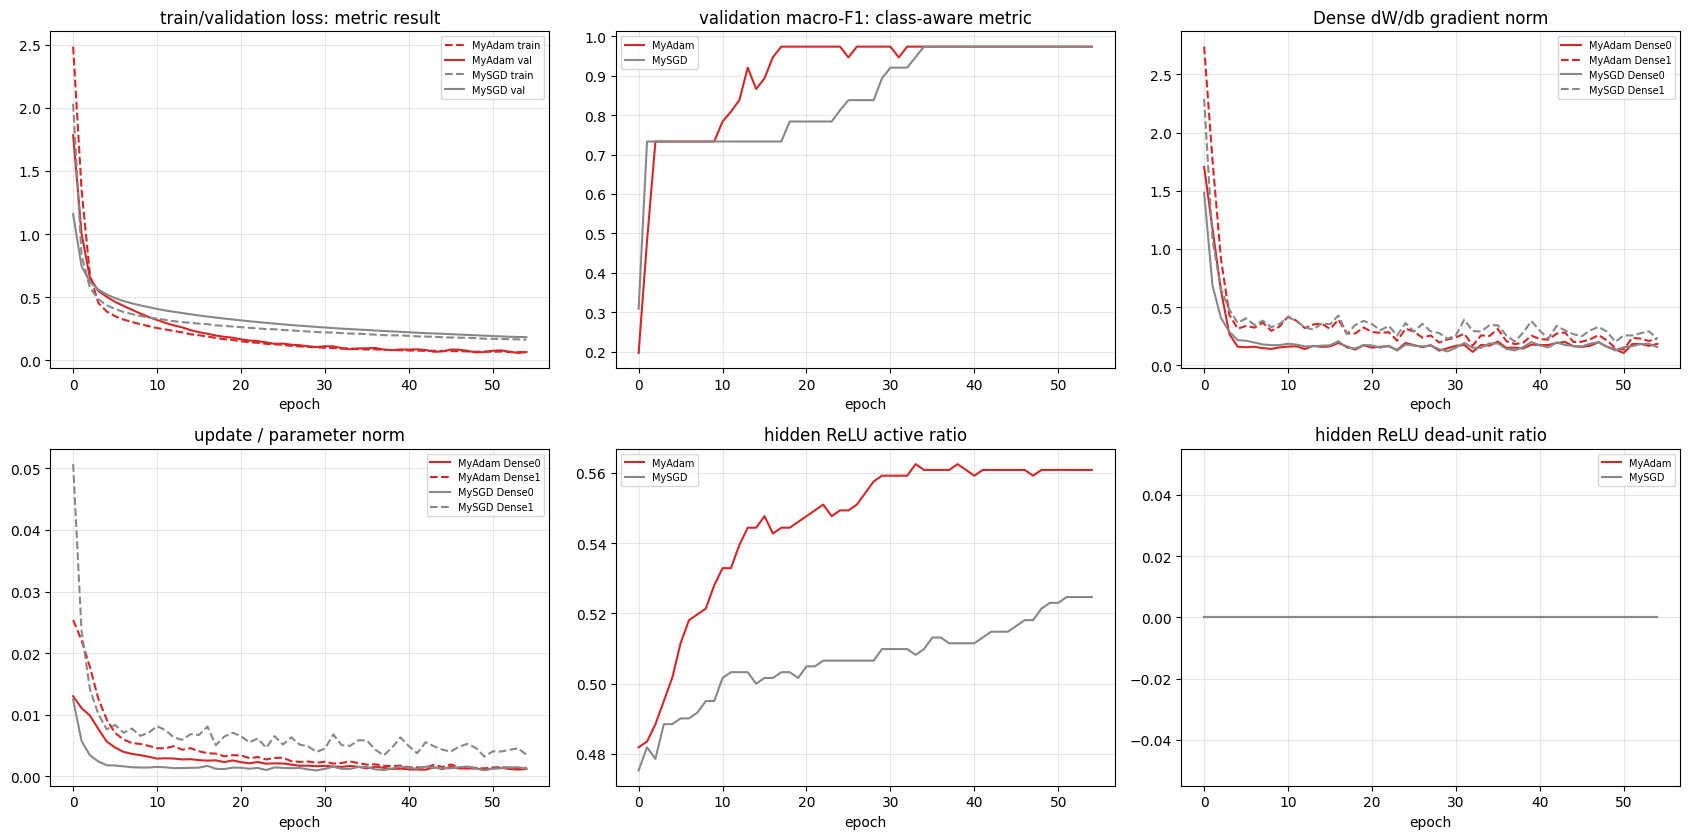

,step,interpretation
0,관찰,"loss와 macro-F1뿐 아니라 Dense별 grad norm, update/p..."
1,원인,"optimizer는 X/y가 아니라 backward가 만든 dW/db를 읽고, st..."
2,제한,이 진단은 validation-only 연구 확장이다. 공식 homework의 te...
3,결론,Part 5 답변에서는 'Adam이 빠르다'만 쓰지 말고 update/grad/st...


In [24]:
# [INSERTED] V05-style validation gradient-flow audit
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: Part 5 답변의 근거를 loss/accuracy에서 layer-level gradient/update/ReLU gate로 확장한다.
# 원본 train_iris는 공식 채점용이므로 수정하지 않고, validation-only extension function을 별도로 만든다.

from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

# [데이터 분리 원칙]
# official homework는 test accuracy를 요구하므로 test를 사용한다.
# 이 extension은 optimizer 선택/원인 진단용이므로 train/validation만 보고 test_used=False로 기록한다.
def make_iris_train_val_only_ext(seed_ext=0):
    iris_ext = load_iris()
    X_raw_ext = iris_ext.data.astype(float)
    y_raw_ext = iris_ext.target.astype(int)
    X_train_ext, X_val_ext, y_train_ext, y_val_ext = train_test_split(
        X_raw_ext, y_raw_ext, test_size=0.25, random_state=seed_ext, stratify=y_raw_ext
    )
    scaler_ext = StandardScaler()
    X_train_ext = scaler_ext.fit_transform(X_train_ext)
    X_val_ext = scaler_ext.transform(X_val_ext)
    Y_train_ext = np.eye(3)[y_train_ext]
    Y_val_ext = np.eye(3)[y_val_ext]
    return X_train_ext, X_val_ext, Y_train_ext, Y_val_ext, y_train_ext, y_val_ext

def flatten_dense_params_ext(net_ext):
    chunks_ext = []
    for layer_ext in net_ext.layers:
        if isinstance(layer_ext, Dense):
            chunks_ext.append(layer_ext.W.ravel())
            chunks_ext.append(layer_ext.b.ravel())
    return np.concatenate(chunks_ext) if chunks_ext else np.array([])

def dense_param_vectors_ext(net_ext):
    vectors_ext = []
    for layer_ext in net_ext.layers:
        if isinstance(layer_ext, Dense):
            vectors_ext.append(np.concatenate([layer_ext.W.ravel(), layer_ext.b.ravel()]))
    return vectors_ext

def evaluate_onehot_ext(net_ext, X_ext, Y_ext):
    loss_fn_ext = SoftmaxCE()
    logits_ext = net_ext.forward(X_ext)
    loss_ext = loss_fn_ext.forward(logits_ext, Y_ext)
    y_true_ext = Y_ext.argmax(axis=1)
    y_pred_ext = logits_ext.argmax(axis=1)
    return {
        "loss": float(loss_ext),
        "accuracy": float(np.mean(y_true_ext == y_pred_ext)),
        "macro_f1": float(f1_score(y_true_ext, y_pred_ext, average="macro")),
    }

def relu_gate_stats_ext(net_ext, X_probe_ext):
    # 첫 Dense pre-activation을 직접 계산한다.
    # ReLU gate가 너무 닫히면 gradient가 hidden representation을 통과하기 어려워진다.
    first_dense_ext = next(layer_ext for layer_ext in net_ext.layers if isinstance(layer_ext, Dense))
    z_ext = X_probe_ext @ first_dense_ext.W.T + first_dense_ext.b
    return float((z_ext > 0).mean()), float(((z_ext <= 0).all(axis=0)).mean())

def train_iris_gradient_flow_ext(OptCls_ext, opt_kwargs_ext, optimizer_name_ext, epochs_ext=55, batch_size_ext=16):
    X_train_ext, X_val_ext, Y_train_ext, Y_val_ext, _, _ = make_iris_train_val_only_ext(seed_ext=0)
    np.random.seed(0)
    net_ext = Network()
    net_ext.add(Dense(4, 16, seed=0))
    net_ext.add(ReLU())
    net_ext.add(Dense(16, 3, seed=1))
    loss_fn_ext = SoftmaxCE()
    opt_ext = OptCls_ext(**opt_kwargs_ext)
    rng_ext = np.random.default_rng(0)
    rows_ext = []

    for epoch_ext in range(epochs_ext):
        order_ext = rng_ext.permutation(len(X_train_ext))
        batch_losses_ext = []
        dense_grad_norms_by_layer_ext = [[], []]
        dense_update_norms_by_layer_ext = [[], []]
        for start_ext in range(0, len(X_train_ext), batch_size_ext):
            idx_ext = order_ext[start_ext:start_ext + batch_size_ext]
            before_vectors_ext = dense_param_vectors_ext(net_ext)
            logits_ext = net_ext.forward(X_train_ext[idx_ext])
            loss_ext = loss_fn_ext.forward(logits_ext, Y_train_ext[idx_ext])
            net_ext.backward(loss_fn_ext.backward())
            dense_layers_ext = [layer_ext for layer_ext in net_ext.layers if isinstance(layer_ext, Dense)]
            for layer_idx_ext, layer_ext in enumerate(dense_layers_ext):
                grad_norm_ext = float(np.sqrt((layer_ext.dW ** 2).sum() + (layer_ext.db ** 2).sum()))
                dense_grad_norms_by_layer_ext[layer_idx_ext].append(grad_norm_ext)
            opt_ext.step(net_ext)
            after_vectors_ext = dense_param_vectors_ext(net_ext)
            for layer_idx_ext, (before_ext, after_ext) in enumerate(zip(before_vectors_ext, after_vectors_ext)):
                dense_update_norms_by_layer_ext[layer_idx_ext].append(float(np.linalg.norm(after_ext - before_ext)))
            batch_losses_ext.append(float(loss_ext))

        val_eval_ext = evaluate_onehot_ext(net_ext, X_val_ext, Y_val_ext)
        active_ratio_ext, dead_unit_ratio_ext = relu_gate_stats_ext(net_ext, X_val_ext)
        dense_layers_ext = [layer_ext for layer_ext in net_ext.layers if isinstance(layer_ext, Dense)]
        for layer_idx_ext, layer_ext in enumerate(dense_layers_ext):
            param_vec_ext = np.concatenate([layer_ext.W.ravel(), layer_ext.b.ravel()])
            param_norm_ext = float(np.linalg.norm(param_vec_ext))
            grad_norm_mean_ext = float(np.mean(dense_grad_norms_by_layer_ext[layer_idx_ext]))
            update_norm_mean_ext = float(np.mean(dense_update_norms_by_layer_ext[layer_idx_ext]))
            rows_ext.append({
                "epoch": epoch_ext,
                "optimizer": optimizer_name_ext,
                "dense_index": layer_idx_ext,
                "train_loss": float(np.mean(batch_losses_ext)),
                "val_loss": val_eval_ext["loss"],
                "val_accuracy": val_eval_ext["accuracy"],
                "val_macro_f1": val_eval_ext["macro_f1"],
                "param_norm": param_norm_ext,
                "mean_grad_norm": grad_norm_mean_ext,
                "mean_update_norm": update_norm_mean_ext,
                "update_to_param_ratio": update_norm_mean_ext / (param_norm_ext + 1e-12),
                "hidden_active_ratio": active_ratio_ext,
                "hidden_dead_unit_ratio": dead_unit_ratio_ext,
                "test_used": False,
            })
    return net_ext, pd.DataFrame(rows_ext)

flow_specs_ext = [
    ("MySGD", MySGD, dict(lr=0.05)),
    ("MyAdam", MyAdam, dict(lr=0.01)),
]
flow_tables_ext = []
for name_ext, OptCls_ext, kwargs_ext in flow_specs_ext:
    _, flow_df_one_ext = train_iris_gradient_flow_ext(OptCls_ext, kwargs_ext, name_ext)
    flow_tables_ext.append(flow_df_one_ext)

grad_flow_df_ext = pd.concat(flow_tables_ext, ignore_index=True)
assert not grad_flow_df_ext["test_used"].any()
grad_flow_df_ext.to_csv(csv_dir_ext / "v05_validation_gradient_flow_audit_ext.csv", index=False)
display(grad_flow_df_ext.groupby(["optimizer", "dense_index"]).tail(1)[["optimizer", "dense_index", "val_loss", "val_macro_f1", "mean_grad_norm", "update_to_param_ratio", "hidden_active_ratio", "hidden_dead_unit_ratio", "test_used"]])

# [시각화 | V05 gradient-flow board]
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
for opt_name_ext, group_ext in grad_flow_df_ext.groupby("optimizer"):
    epoch_view_ext = group_ext.groupby("epoch").agg(
        train_loss=("train_loss", "mean"),
        val_loss=("val_loss", "mean"),
        val_macro_f1=("val_macro_f1", "mean"),
        hidden_active_ratio=("hidden_active_ratio", "mean"),
        hidden_dead_unit_ratio=("hidden_dead_unit_ratio", "mean"),
    ).reset_index()
    color_ext = "#888888" if opt_name_ext == "MySGD" else "#d62728"
    axes[0, 0].plot(epoch_view_ext["epoch"], epoch_view_ext["train_loss"], linestyle="--", color=color_ext, label=f"{opt_name_ext} train")
    axes[0, 0].plot(epoch_view_ext["epoch"], epoch_view_ext["val_loss"], linestyle="-", color=color_ext, label=f"{opt_name_ext} val")
    axes[0, 1].plot(epoch_view_ext["epoch"], epoch_view_ext["val_macro_f1"], color=color_ext, label=opt_name_ext)
    axes[1, 1].plot(epoch_view_ext["epoch"], epoch_view_ext["hidden_active_ratio"], color=color_ext, label=opt_name_ext)
    axes[1, 2].plot(epoch_view_ext["epoch"], epoch_view_ext["hidden_dead_unit_ratio"], color=color_ext, label=opt_name_ext)

for (opt_name_ext, dense_idx_ext), group_ext in grad_flow_df_ext.groupby(["optimizer", "dense_index"]):
    color_ext = "#888888" if opt_name_ext == "MySGD" else "#d62728"
    linestyle_ext = "-" if dense_idx_ext == 0 else "--"
    axes[0, 2].plot(group_ext["epoch"], group_ext["mean_grad_norm"], color=color_ext, linestyle=linestyle_ext, label=f"{opt_name_ext} Dense{dense_idx_ext}")
    axes[1, 0].plot(group_ext["epoch"], group_ext["update_to_param_ratio"], color=color_ext, linestyle=linestyle_ext, label=f"{opt_name_ext} Dense{dense_idx_ext}")

axes[0, 0].set_title("train/validation loss: metric result")
axes[0, 1].set_title("validation macro-F1: class-aware metric")
axes[0, 2].set_title("Dense dW/db gradient norm")
axes[1, 0].set_title("update / parameter norm")
axes[1, 1].set_title("hidden ReLU active ratio")
axes[1, 2].set_title("hidden ReLU dead-unit ratio")
for ax_ext in axes.ravel():
    ax_ext.set_xlabel("epoch")
    ax_ext.grid(True, alpha=0.3)
    ax_ext.legend(fontsize=7)
plt.tight_layout()
fig.savefig(fig_dir_ext / "v05_validation_gradient_flow_audit_ext.png", dpi=160)
plt.show()

grad_flow_interpretation_ext = pd.DataFrame([
    ["관찰", "loss와 macro-F1뿐 아니라 Dense별 grad norm, update/param ratio, ReLU active/dead ratio가 epoch별로 달라진다."],
    ["원인", "optimizer는 X/y가 아니라 backward가 만든 dW/db를 읽고, state와 lr에 따라 실제 update 크기를 조절한다."],
    ["제한", "이 진단은 validation-only 연구 확장이다. 공식 homework의 test accuracy 결과를 대체하지 않는다."],
    ["결론", "Part 5 답변에서는 'Adam이 빠르다'만 쓰지 말고 update/grad/state 관점의 근거를 같이 제시해야 한다."],
], columns=["step", "interpretation"])
display(grad_flow_interpretation_ext)
grad_flow_interpretation_ext.to_csv(csv_dir_ext / "v05_gradient_flow_interpretation_ext.csv", index=False)


## [INSERTED] V05-style Dense2 output ReLU placement ablation

이 확장 cell은 PREP notebook의 `Dense₂ 뒤 ReLU 유무` 실험을 homework 하단부에 삽입형으로 반영한다. 원본 optimizer 비교를 바꾸지 않고, 같은 Iris train/validation split, 같은 Adam/lr, 같은 초기화, 같은 batch order에서 **마지막 Dense(16→3) 뒤에 ReLU를 넣는 경우와 넣지 않는 경우**만 비교한다.

이 실험은 공식 Part 2 test accuracy를 대체하지 않는다. 출력층 activation placement가 loss curve와 score 분포를 어떻게 바꾸는지 보는 validation-only 보조 진단이다.


,condition,value,why
0,dataset,Iris,train/validation only; test_used=False
1,shared architecture,"Dense(4,16)->ReLU->Dense(16,3)",두 variant의 공통 base
2,variant A,Dense2 raw logits -> SoftmaxCE,일반적인 multiclass CE-from-logits 구조
3,variant B,Dense2 -> ReLU -> SoftmaxCE,class score 음수값을 0으로 clipping하는 placement 실험
4,fixed condition,"Adam lr=0.01, same seed, same batch order",한 번에 하나만 바꾸는 ablation 원칙


,variant,relu_after_dense2,best_val_loss,best_val_epoch,final_train_loss,final_val_loss,final_val_accuracy,final_val_macro_f1,final_score_zero_ratio,test_used
0,raw_logits_no_relu_after_Dense2,False,0.037735,79,0.055851,0.037735,0.973684,0.973162,0.000000,False
1,relu_after_Dense2,True,0.763149,79,0.771983,0.763149,0.684211,0.550265,0.868421,False


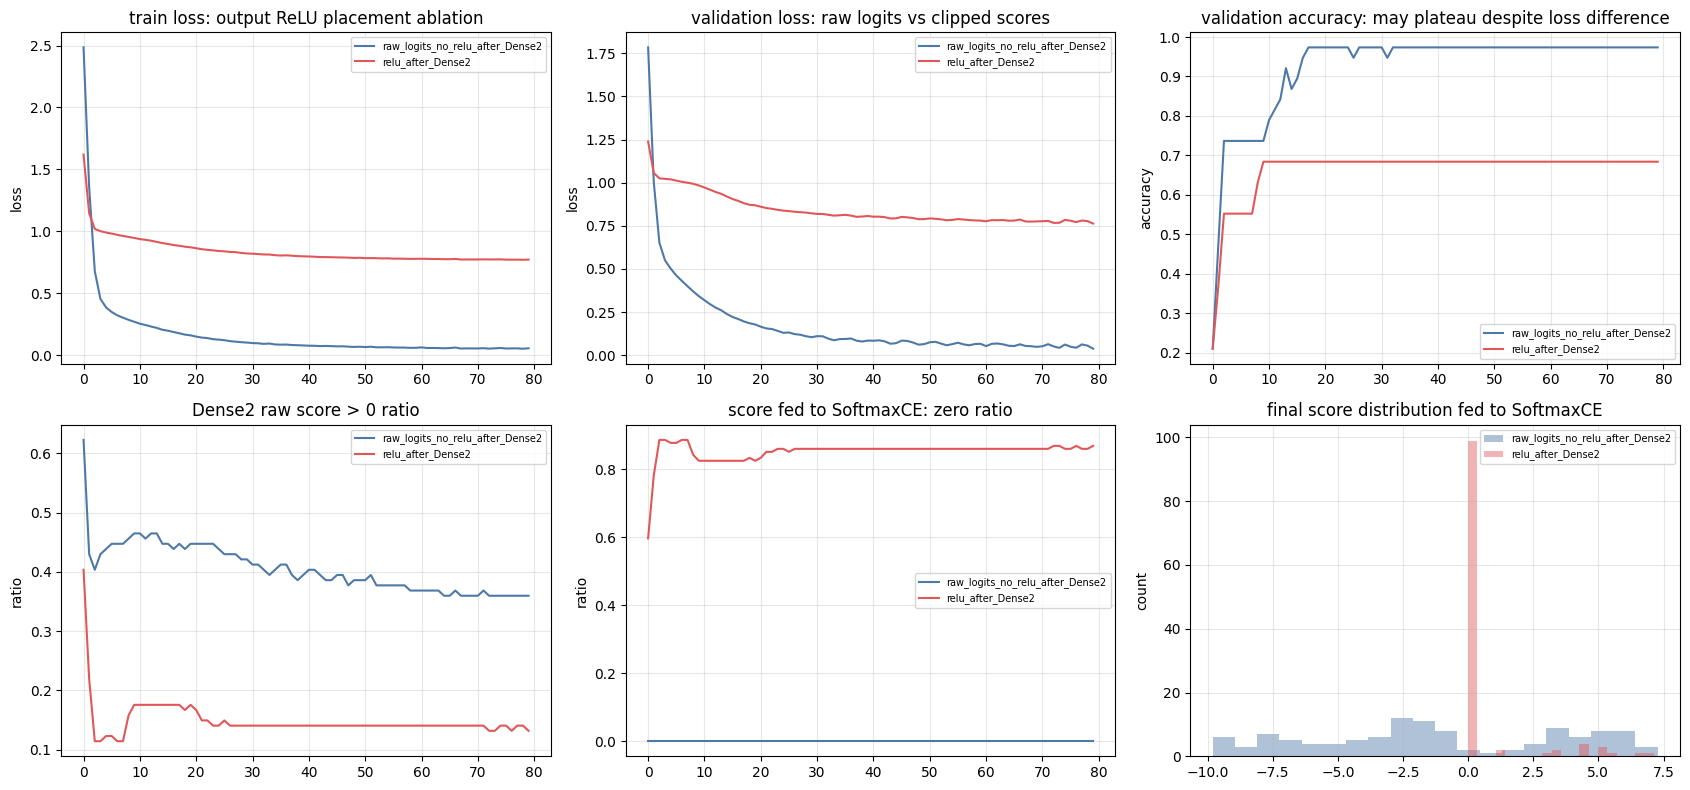

,step,interpretation
0,관찰,같은 Adam/lr에서도 Dense2 뒤 ReLU 유무에 따라 train/val l...
1,원인,출력층 ReLU는 음수 logit을 0으로 잘라 class 간 signed scor...
2,제한,Iris는 작고 쉬워 accuracy가 비슷하게 나올 수 있으므로 loss와 sco...
3,결론,multiclass CE-from-logits 구조에서는 마지막 Dense 뒤 Re...


In [25]:
# [INSERTED] V05-style Dense2 output ReLU placement ablation
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: 같은 optimizer/lr에서 Dense2 뒤 ReLU 유무가 loss/accuracy/score distribution을 어떻게 바꾸는지 본다.
# 원본 train_iris와 공식 results는 변경하지 않는다. 이 cell은 validation-only extension이다.

from pathlib import Path
import pandas as pd
from sklearn.metrics import f1_score

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

DENSE2_RELU_EPOCHS_EXT = 80
DENSE2_RELU_BATCH_EXT = 16
DENSE2_RELU_LR_EXT = 0.01

contract_dense2_relu_ext = pd.DataFrame([
    ["dataset", "Iris", "train/validation only; test_used=False"],
    ["shared architecture", "Dense(4,16)->ReLU->Dense(16,3)", "두 variant의 공통 base"],
    ["variant A", "Dense2 raw logits -> SoftmaxCE", "일반적인 multiclass CE-from-logits 구조"],
    ["variant B", "Dense2 -> ReLU -> SoftmaxCE", "class score 음수값을 0으로 clipping하는 placement 실험"],
    ["fixed condition", "Adam lr=0.01, same seed, same batch order", "한 번에 하나만 바꾸는 ablation 원칙"],
], columns=["condition", "value", "why"])
display(contract_dense2_relu_ext)

X_train_dense2_ext, X_val_dense2_ext, Y_train_dense2_ext, Y_val_dense2_ext, _, _ = make_iris_train_val_only_ext(seed_ext=0)

def make_dense2_variant_net_ext(relu_after_dense2_ext=False):
    # [초기화 원칙]
    # seed를 고정해 두 variant가 같은 W/b에서 출발하게 한다.
    # Dense2 뒤 ReLU 한 줄만 실험 변수로 둔다.
    net_ext = Network()
    net_ext.add(Dense(4, 16, seed=0))
    net_ext.add(ReLU())
    net_ext.add(Dense(16, 3, seed=1))
    if relu_after_dense2_ext:
        net_ext.add(ReLU())
    return net_ext

def dense2_score_diag_ext(net_ext, X_ext):
    out_ext = X_ext
    dense_count_ext = 0
    dense2_raw_ext = None
    score_to_loss_ext = None
    seen_dense2_ext = False
    for layer_ext in net_ext.layers:
        out_ext = layer_ext.forward(out_ext)
        if isinstance(layer_ext, Dense):
            dense_count_ext += 1
            if dense_count_ext == 2:
                dense2_raw_ext = out_ext.copy()
                score_to_loss_ext = out_ext.copy()
                seen_dense2_ext = True
        elif seen_dense2_ext:
            # Dense2 뒤 ReLU가 있으면 이 branch에서 score_to_loss가 clipped 값으로 바뀐다.
            score_to_loss_ext = out_ext.copy()
    return {
        "dense2_raw_positive_ratio": float((dense2_raw_ext > 0).mean()),
        "score_to_loss_zero_ratio": float(np.isclose(score_to_loss_ext, 0.0).mean()),
        "score_to_loss_mean_abs": float(np.abs(score_to_loss_ext).mean()),
        "score_to_loss": score_to_loss_ext.copy(),
    }

def eval_dense2_variant_ext(net_ext):
    logits_or_scores_ext = net_ext.forward(X_val_dense2_ext)
    loss_fn_eval_ext = SoftmaxCE()
    val_loss_ext = loss_fn_eval_ext.forward(logits_or_scores_ext, Y_val_dense2_ext)
    y_true_ext = Y_val_dense2_ext.argmax(axis=1)
    y_pred_ext = logits_or_scores_ext.argmax(axis=1)
    return {
        "val_loss": float(val_loss_ext),
        "val_accuracy": float(np.mean(y_true_ext == y_pred_ext)),
        "val_macro_f1": float(f1_score(y_true_ext, y_pred_ext, average="macro")),
    }

def train_dense2_variant_ext(variant_name_ext, relu_after_dense2_ext):
    net_ext = make_dense2_variant_net_ext(relu_after_dense2_ext=relu_after_dense2_ext)
    opt_ext = MyAdam(lr=DENSE2_RELU_LR_EXT)
    loss_fn_ext = SoftmaxCE()
    rng_ext = np.random.default_rng(0)
    rows_ext = []
    for epoch_ext in range(DENSE2_RELU_EPOCHS_EXT):
        order_ext = rng_ext.permutation(len(X_train_dense2_ext))
        batch_losses_ext = []
        for start_ext in range(0, len(X_train_dense2_ext), DENSE2_RELU_BATCH_EXT):
            idx_ext = order_ext[start_ext:start_ext + DENSE2_RELU_BATCH_EXT]
            logits_or_scores_ext = net_ext.forward(X_train_dense2_ext[idx_ext])
            loss_ext = loss_fn_ext.forward(logits_or_scores_ext, Y_train_dense2_ext[idx_ext])
            net_ext.backward(loss_fn_ext.backward())
            opt_ext.step(net_ext)
            batch_losses_ext.append(float(loss_ext))
        eval_ext = eval_dense2_variant_ext(net_ext)
        score_diag_ext = dense2_score_diag_ext(net_ext, X_val_dense2_ext)
        rows_ext.append({
            "epoch": epoch_ext,
            "variant": variant_name_ext,
            "relu_after_dense2": relu_after_dense2_ext,
            "train_loss": float(np.mean(batch_losses_ext)),
            "val_loss": eval_ext["val_loss"],
            "val_accuracy": eval_ext["val_accuracy"],
            "val_macro_f1": eval_ext["val_macro_f1"],
            "dense2_raw_positive_ratio": score_diag_ext["dense2_raw_positive_ratio"],
            "score_to_loss_zero_ratio": score_diag_ext["score_to_loss_zero_ratio"],
            "score_to_loss_mean_abs": score_diag_ext["score_to_loss_mean_abs"],
            "test_used": False,
        })
    return net_ext, pd.DataFrame(rows_ext), dense2_score_diag_ext(net_ext, X_val_dense2_ext)

dense2_runs_ext = []
for variant_name_ext, relu_flag_ext in [
    ("raw_logits_no_relu_after_Dense2", False),
    ("relu_after_Dense2", True),
]:
    net_dense2_ext, curve_dense2_ext, score_dense2_ext = train_dense2_variant_ext(variant_name_ext, relu_flag_ext)
    dense2_runs_ext.append({
        "variant": variant_name_ext,
        "relu_after_dense2": relu_flag_ext,
        "net": net_dense2_ext,
        "curve": curve_dense2_ext,
        "final_score_to_loss": score_dense2_ext["score_to_loss"],
    })

dense2_relu_curve_df_ext = pd.concat([run_ext["curve"] for run_ext in dense2_runs_ext], ignore_index=True)
assert not dense2_relu_curve_df_ext["test_used"].any()
dense2_relu_curve_df_ext.to_csv(csv_dir_ext / "v05_dense2_relu_placement_curve_ext.csv", index=False)

summary_rows_ext = []
for run_ext in dense2_runs_ext:
    h_ext = run_ext["curve"]
    best_row_ext = h_ext.loc[h_ext["val_loss"].idxmin()]
    final_row_ext = h_ext.tail(1).iloc[0]
    summary_rows_ext.append({
        "variant": run_ext["variant"],
        "relu_after_dense2": run_ext["relu_after_dense2"],
        "best_val_loss": float(best_row_ext["val_loss"]),
        "best_val_epoch": int(best_row_ext["epoch"]),
        "final_train_loss": float(final_row_ext["train_loss"]),
        "final_val_loss": float(final_row_ext["val_loss"]),
        "final_val_accuracy": float(final_row_ext["val_accuracy"]),
        "final_val_macro_f1": float(final_row_ext["val_macro_f1"]),
        "final_score_zero_ratio": float(final_row_ext["score_to_loss_zero_ratio"]),
        "test_used": False,
    })
dense2_relu_summary_ext = pd.DataFrame(summary_rows_ext)
display(dense2_relu_summary_ext)
dense2_relu_summary_ext.to_csv(csv_dir_ext / "v05_dense2_relu_placement_summary_ext.csv", index=False)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
colors_dense2_ext = {"raw_logits_no_relu_after_Dense2": "#4e79a7", "relu_after_Dense2": "#e15759"}
for variant_ext, group_ext in dense2_relu_curve_df_ext.groupby("variant"):
    color_ext = colors_dense2_ext[variant_ext]
    axes[0, 0].plot(group_ext["epoch"], group_ext["train_loss"], label=variant_ext, color=color_ext)
    axes[0, 1].plot(group_ext["epoch"], group_ext["val_loss"], label=variant_ext, color=color_ext)
    axes[0, 2].plot(group_ext["epoch"], group_ext["val_accuracy"], label=variant_ext, color=color_ext)
    axes[1, 0].plot(group_ext["epoch"], group_ext["dense2_raw_positive_ratio"], label=variant_ext, color=color_ext)
    axes[1, 1].plot(group_ext["epoch"], group_ext["score_to_loss_zero_ratio"], label=variant_ext, color=color_ext)
for run_ext in dense2_runs_ext:
    axes[1, 2].hist(run_ext["final_score_to_loss"].ravel(), bins=20, alpha=0.45, label=run_ext["variant"], color=colors_dense2_ext[run_ext["variant"]])

axes[0, 0].set_title("train loss: output ReLU placement ablation")
axes[0, 1].set_title("validation loss: raw logits vs clipped scores")
axes[0, 2].set_title("validation accuracy: may plateau despite loss difference")
axes[1, 0].set_title("Dense2 raw score > 0 ratio")
axes[1, 1].set_title("score fed to SoftmaxCE: zero ratio")
axes[1, 2].set_title("final score distribution fed to SoftmaxCE")
for ax_ext in axes.ravel():
    ax_ext.grid(True, alpha=0.3)
    ax_ext.legend(fontsize=7)
axes[0, 0].set_ylabel("loss")
axes[0, 1].set_ylabel("loss")
axes[0, 2].set_ylabel("accuracy")
axes[1, 0].set_ylabel("ratio")
axes[1, 1].set_ylabel("ratio")
axes[1, 2].set_ylabel("count")
plt.tight_layout()
fig.savefig(fig_dir_ext / "v05_dense2_relu_placement_ablation_ext.png", dpi=160)
plt.show()

dense2_relu_interpretation_ext = pd.DataFrame([
    ["관찰", "같은 Adam/lr에서도 Dense2 뒤 ReLU 유무에 따라 train/val loss와 score zero ratio가 달라진다."],
    ["원인", "출력층 ReLU는 음수 logit을 0으로 잘라 class 간 signed score 차이를 제한하고, 일부 gradient 흐름도 차단할 수 있다."],
    ["제한", "Iris는 작고 쉬워 accuracy가 비슷하게 나올 수 있으므로 loss와 score distribution을 함께 봐야 한다."],
    ["결론", "multiclass CE-from-logits 구조에서는 마지막 Dense 뒤 ReLU를 기본값으로 넣기보다 ablation으로 검증해야 한다."],
], columns=["step", "interpretation"])
display(dense2_relu_interpretation_ext)
dense2_relu_interpretation_ext.to_csv(csv_dir_ext / "v05_dense2_relu_interpretation_ext.csv", index=False)


## [INSERTED] Optimizer scoped box/barplot board

막대그래프와 박스플롯은 전체 범위를 항상 `0~1`로 두면 차이가 묻힌다. 이 cell은 공식 결과를 바꾸지 않고, 보조 진단 plot에서만 y축 범위를 데이터에 맞게 조절한다.

- barplot은 값의 최소/최대 주변에 padding을 둬 차이를 선명하게 보여준다.
- boxplot은 극단값 한두 개가 전체 축을 망치지 않도록 2~98% quantile 기준으로 zoom한다.
- 단, 축을 줄인 plot은 반드시 `zoomed` 또는 `scoped`라고 표시해 과장 오해를 줄인다.


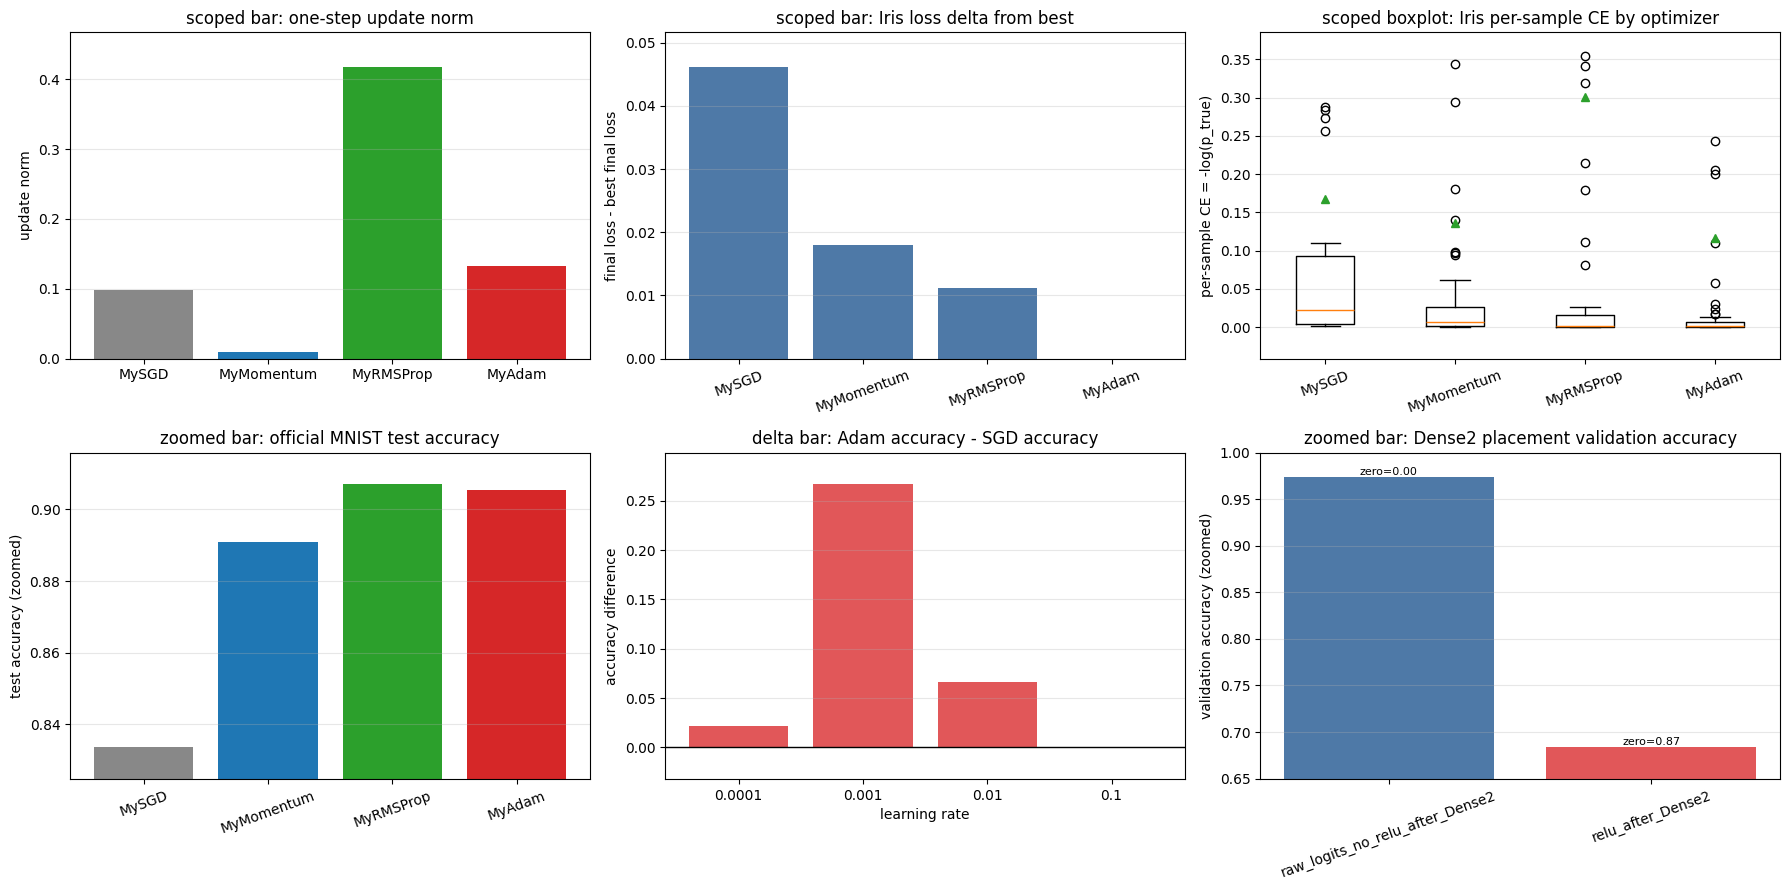

,plot type,when to scope,scope rule,caution
0,barplot,0~1 전체 축에서 차이가 묻힐 때,min/max + padding,zoomed/scoped라고 제목에 명시한다
1,boxplot,outlier 때문에 box 본체가 눌릴 때,2~98% 또는 2~95% quantile,outlier를 제거한 것이 아니라 zoom한 것임을 해석에 남긴다
2,delta bar,두 optimizer 차이를 직접 비교할 때,difference scale centered at 0,원래 absolute metric도 함께 보존한다
3,Dense2 placement,accuracy와 score clipping을 함께 볼 때,accuracy zoom + zero ratio annotation,validation-only extension이라고 명시한다


In [26]:
# [INSERTED] Optimizer scoped box/barplot board
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

# 목적: optimizer 관련 boxplot/barplot에서 차이가 묻히지 않도록 y-axis scope를 데이터 기반으로 조절한다.
# 공식 원본 plot은 그대로 두고, extension-only zoomed/scoped plot을 추가한다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
for _d_ext in [fig_dir_ext, csv_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

def scoped_ylim_ext(values_ext, pad_ratio_ext=0.12, min_span_ext=0.02, lower_bound_ext=None, upper_bound_ext=None):
    # [메소드 설명 | scoped_ylim_ext]
    # 전체 0~1 축이 차이를 숨길 때, 실제 값 범위에 padding을 더해 zoomed y-limit을 만든다.
    # min_span_ext는 값이 거의 같아 y축이 너무 좁아지는 것을 막는 안전장치다.
    arr_ext = np.asarray(values_ext, dtype=float)
    arr_ext = arr_ext[np.isfinite(arr_ext)]
    lo_ext, hi_ext = float(arr_ext.min()), float(arr_ext.max())
    span_ext = max(hi_ext - lo_ext, min_span_ext)
    lo_ext -= span_ext * pad_ratio_ext
    hi_ext += span_ext * pad_ratio_ext
    if lower_bound_ext is not None:
        lo_ext = max(lower_bound_ext, lo_ext)
    if upper_bound_ext is not None:
        hi_ext = min(upper_bound_ext, hi_ext)
    return lo_ext, hi_ext

def scoped_box_ylim_ext(list_of_arrays_ext, q_low_ext=0.02, q_high_ext=0.98, pad_ratio_ext=0.12, min_span_ext=0.02):
    # [메소드 설명 | scoped_box_ylim_ext]
    # boxplot은 극단값이 있으면 본체 box 차이가 잘 안 보인다.
    # quantile 기준으로 zoom하되, outlier가 있다는 사실은 해석 문장에 남긴다.
    arr_ext = np.concatenate([np.asarray(v_ext, dtype=float).ravel() for v_ext in list_of_arrays_ext if len(v_ext) > 0])
    lo_ext, hi_ext = np.quantile(arr_ext, [q_low_ext, q_high_ext])
    span_ext = max(float(hi_ext - lo_ext), min_span_ext)
    return float(lo_ext - span_ext * pad_ratio_ext), float(hi_ext + span_ext * pad_ratio_ext)

# [자료 준비]
# 기존 inserted diagnostics에서 생성된 DataFrame을 재사용한다.
# 없을 경우 fresh execution 순서가 잘못된 것이므로 명시적으로 실패하게 두는 것이 낫다.
official_iris_plot_ext = pd.DataFrame([
    {"optimizer": name_ext, "final_loss": float(losses_ext[-1]), "test_acc": float(acc_ext)}
    for name_ext, (losses_ext, acc_ext) in results.items()
])
official_mnist_plot_ext = pd.DataFrame([
    {"optimizer": name_ext, "final_loss": float(losses_ext[-1]), "test_acc": float(acc_ext)}
    for name_ext, (losses_ext, acc_ext) in mnist_results.items()
])

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1) optimizer one-step update norm bar: update 크기 차이가 보이도록 y축을 update_norm 주변으로 조절한다.
axes[0, 0].bar(optimizer_audit_df_ext["optimizer"], optimizer_audit_df_ext["update_norm"], color=["#888", "#1f77b4", "#2ca02c", "#d62728"])
axes[0, 0].set_ylim(*scoped_ylim_ext(optimizer_audit_df_ext["update_norm"], lower_bound_ext=0))
axes[0, 0].set_title("scoped bar: one-step update norm")
axes[0, 0].set_ylabel("update norm")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2) Iris final loss delta from best: accuracy가 모두 같으므로 loss 차이를 delta로 본다.
iris_loss_delta_ext = official_iris_plot_ext.copy()
iris_loss_delta_ext["loss_delta_from_best"] = iris_loss_delta_ext["final_loss"] - iris_loss_delta_ext["final_loss"].min()
axes[0, 1].bar(iris_loss_delta_ext["optimizer"], iris_loss_delta_ext["loss_delta_from_best"], color="#4e79a7")
axes[0, 1].set_ylim(*scoped_ylim_ext(iris_loss_delta_ext["loss_delta_from_best"], lower_bound_ext=0))
axes[0, 1].set_title("scoped bar: Iris loss delta from best")
axes[0, 1].set_ylabel("final loss - best final loss")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].grid(axis="y", alpha=0.3)

# 3) Iris per-sample CE boxplot by optimizer: class별 boxplot이 아니라 optimizer별 per-sample CE 분포를 zoom한다.
ce_box_data_ext = [
    diag_iris_ce_margin_ext[diag_iris_ce_margin_ext["optimizer"] == opt_ext]["per_sample_ce"].to_numpy()
    for opt_ext in official_iris_plot_ext["optimizer"]
]
axes[0, 2].boxplot(ce_box_data_ext, tick_labels=official_iris_plot_ext["optimizer"], showmeans=True)
axes[0, 2].set_ylim(*scoped_box_ylim_ext(ce_box_data_ext, q_low_ext=0.02, q_high_ext=0.95, min_span_ext=0.05))
axes[0, 2].set_title("scoped boxplot: Iris per-sample CE by optimizer")
axes[0, 2].set_ylabel("per-sample CE = -log(p_true)")
axes[0, 2].tick_params(axis="x", rotation=20)
axes[0, 2].grid(axis="y", alpha=0.3)

# 4) MNIST test accuracy bar: 0~1 전체 축 대신 결과 범위에 맞춘 zoomed axis를 사용한다.
axes[1, 0].bar(official_mnist_plot_ext["optimizer"], official_mnist_plot_ext["test_acc"], color=["#888", "#1f77b4", "#2ca02c", "#d62728"])
axes[1, 0].set_ylim(*scoped_ylim_ext(official_mnist_plot_ext["test_acc"], lower_bound_ext=0, upper_bound_ext=1))
axes[1, 0].set_title("zoomed bar: official MNIST test accuracy")
axes[1, 0].set_ylabel("test accuracy (zoomed)")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].grid(axis="y", alpha=0.3)

# 5) LR sensitivity delta: Adam-SGD 차이를 직접 그리면 lr별 차이가 더 선명하다.
axes[1, 1].bar(lr_sensitivity_df_ext["lr"].astype(str), lr_sensitivity_df_ext["Adam_minus_SGD"], color="#e15759")
lo_delta_ext, hi_delta_ext = scoped_ylim_ext(lr_sensitivity_df_ext["Adam_minus_SGD"], min_span_ext=0.05)
axes[1, 1].set_ylim(min(0, lo_delta_ext), hi_delta_ext)
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set_title("delta bar: Adam accuracy - SGD accuracy")
axes[1, 1].set_ylabel("accuracy difference")
axes[1, 1].set_xlabel("learning rate")
axes[1, 1].grid(axis="y", alpha=0.3)

# 6) Dense2 placement: final val accuracy는 zoomed, score-zero ratio는 annotation으로 함께 표시한다.
axes[1, 2].bar(dense2_relu_summary_ext["variant"], dense2_relu_summary_ext["final_val_accuracy"], color=["#4e79a7", "#e15759"])
axes[1, 2].set_ylim(*scoped_ylim_ext(dense2_relu_summary_ext["final_val_accuracy"], lower_bound_ext=0, upper_bound_ext=1))
axes[1, 2].set_title("zoomed bar: Dense2 placement validation accuracy")
axes[1, 2].set_ylabel("validation accuracy (zoomed)")
axes[1, 2].tick_params(axis="x", rotation=20)
axes[1, 2].grid(axis="y", alpha=0.3)
for idx_ext, row_ext in dense2_relu_summary_ext.reset_index(drop=True).iterrows():
    axes[1, 2].text(idx_ext, row_ext["final_val_accuracy"], f"zero={row_ext['final_score_zero_ratio']:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig.savefig(fig_dir_ext / "optimizer_scoped_bar_box_board_ext.png", dpi=160)
plt.show()

# [해석 보드 | scope를 줄였을 때의 주의]
scoped_axis_policy_ext = pd.DataFrame([
    ["barplot", "0~1 전체 축에서 차이가 묻힐 때", "min/max + padding", "zoomed/scoped라고 제목에 명시한다"],
    ["boxplot", "outlier 때문에 box 본체가 눌릴 때", "2~98% 또는 2~95% quantile", "outlier를 제거한 것이 아니라 zoom한 것임을 해석에 남긴다"],
    ["delta bar", "두 optimizer 차이를 직접 비교할 때", "difference scale centered at 0", "원래 absolute metric도 함께 보존한다"],
    ["Dense2 placement", "accuracy와 score clipping을 함께 볼 때", "accuracy zoom + zero ratio annotation", "validation-only extension이라고 명시한다"],
], columns=["plot type", "when to scope", "scope rule", "caution"])
display(scoped_axis_policy_ext)
scoped_axis_policy_ext.to_csv(csv_dir_ext / "optimizer_scoped_axis_policy_ext.csv", index=False)


## [INSERTED] Evidence board for analysis questions

Part 5 질문 문구는 그대로 유지한다. 이 cell은 답변을 쓰기 위한 근거판이며, 답변 자체를 대체하지 않는다.


In [27]:
# [INSERTED] Evidence board for analysis questions
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd

artifact_root_ext = Path("artifacts")
csv_dir_ext = artifact_root_ext / "csv"
csv_dir_ext.mkdir(parents=True, exist_ok=True)

# [코드 해설 | evidence_board_ext]
# 이 표는 Part 5 Q1~Q4의 원문 질문을 바꾸지 않고, 답변에 어떤 그래프/표를 근거로 쓸지 정리한다.
# 새 V04/V05-style 하단 실험과 scoped plot은 공식 test accuracy를 대체하지 않는 보조 근거다.
evidence_board_ext = pd.DataFrame([
    ["Q1", "Iris/MNIST loss curves + V04 trajectory", "Part 2/3 curve plots, v04_optimizer_surface_projection_pack_ext.png", "Adam/RMSProp often reduce loss faster because state changes actual step size", "official curves use fixed small epoch budgets"],
    ["Q1-early", "virtual 3D contour/path/loss geometry", "virtual_3d_optimizer_contour_analysis_ext.png, virtual_3d_optimizer_evaluation_ext.csv", "same gradient field can produce different optimizer paths before real Iris/MNIST experiments", "surrogate quadratic, not real dataset loss surface"],
    ["Q2", "lr=0.1 comparison + update norm", "Part 4 semilogx plot, optimizer_scoped_bar_box_board_ext.png", "compare MySGD vs MyAdam at lr=0.1, then explain update rule/state", "Iris accuracy can saturate; inspect loss/update norm too"],
    ["Q3", "LR robustness + state dashboard", "lr_sensitivity_df_ext, v04_optimizer_state_dashboard_ext.png", "Adam can look more robust because m/v adapt step scale", "only four lr values and one split"],
    ["Q4", "practical optimizer choice", "official summaries + V05 gradient-flow audit + scoped bars", "start with Adam baseline, then check gradient/update ratios and validation curve", "data geometry, scaling, output activation placement can change ranking"],
    ["Q4-extra", "architecture/activation caution", "v05_dense2_relu_placement_summary_ext.csv", "do not add output ReLU by habit in CE-from-logits classification", "extension-only validation diagnostic, not official score"],
    ["V01.2", "data quality + Pearson/Spearman/Kendall + Cramer's V + PCA + val/test protocol", "iris_preprocessing_association_pca_audit_ext.png, iris_validation_test_protocol_ext.csv", "preprocessing fit scope changes coordinates; validation selects, test reports", "official Part 2 all-fit scaler remains untouched for homework scoring"],
    ["All", "visualization candidate map", "optimizer_visualization_candidate_map_ext.csv", "choose 3D only when it clarifies trajectory/surface geometry", "not every diagnostic needs 3D"],
], columns=["question", "required evidence", "relevant plot/table", "likely answer direction", "caution"])
display(evidence_board_ext)
evidence_board_ext.to_csv(csv_dir_ext / "part5_evidence_board.csv", index=False)


,question,required evidence,relevant plot/table,likely answer direction,caution
0,Q1,Iris/MNIST loss curves + V04 trajectory,"Part 2/3 curve plots, v04_optimizer_surface_pr...",Adam/RMSProp often reduce loss faster because ...,official curves use fixed small epoch budgets
1,Q1-early,virtual 3D contour/path/loss geometry,"virtual_3d_optimizer_contour_analysis_ext.png,...",same gradient field can produce different opti...,"surrogate quadratic, not real dataset loss sur..."
2,Q2,lr=0.1 comparison + update norm,"Part 4 semilogx plot, optimizer_scoped_bar_box...","compare MySGD vs MyAdam at lr=0.1, then explai...",Iris accuracy can saturate; inspect loss/updat...
3,Q3,LR robustness + state dashboard,"lr_sensitivity_df_ext, v04_optimizer_state_das...",Adam can look more robust because m/v adapt st...,only four lr values and one split
4,Q4,practical optimizer choice,official summaries + V05 gradient-flow audit +...,"start with Adam baseline, then check gradient/...","data geometry, scaling, output activation plac..."
5,Q4-extra,architecture/activation caution,v05_dense2_relu_placement_summary_ext.csv,do not add output ReLU by habit in CE-from-log...,"extension-only validation diagnostic, not offi..."
6,V01.2,data quality + Pearson/Spearman/Kendall + Cram...,iris_preprocessing_association_pca_audit_ext.p...,preprocessing fit scope changes coordinates; v...,official Part 2 all-fit scaler remains untouch...
7,All,visualization candidate map,optimizer_visualization_candidate_map_ext.csv,choose 3D only when it clarifies trajectory/su...,not every diagnostic needs 3D


## [INSERTED] Final research conclusion board

이 마지막 확장 cell은 원본 공식 결과와 보조 진단을 한 화면에 요약한다. 원본 채점 기준의 Part 1~5 결과를 대체하지 않는다.


,optimizer,final_loss,test_acc
0,MySGD,0.085444,0.977778
1,MyMomentum,0.057353,0.977778
2,MyRMSProp,0.050463,0.977778
3,MyAdam,0.039351,0.977778


,optimizer,final_loss,test_acc
0,MySGD,0.478496,0.8335
1,MyMomentum,0.242558,0.8910
2,MyRMSProp,0.156582,0.9070
3,MyAdam,0.150897,0.9055


,evidence area,summary,interpretation
0,official Iris,"test accuracy tie at 0.978: MySGD, MyMomentum,...","accuracy is saturated, so do not call the firs..."
1,official MNIST,test accuracy best=MyRMSProp; lowest final los...,RMSProp and Adam are close; report both accura...
2,LR sensitivity,MyAdam,smaller range means less sensitive in this grid
3,split-before-fit,train-only fit for research,official Part 2 kept all-fit scaler because ho...
4,V01.2 preprocessing audit,quality/correlation/Cramer/PCA + validation-te...,extension-only evidence that fit scope changes...
5,diagnostics,confusion/CE-margin/gradient audit,"extension-only evidence, not replacement for s..."
6,V04 optimizer dynamics,trajectory/update/state dashboard,same gradient can produce different paths beca...
7,Early virtual 3D contour,3D parameter path + contour slices + evaluatio...,front-loads optimizer geometry before Iris/MNI...
8,V05 gradient flow,validation-only dW/db and update audit,test_used=False; explains loss/metric curve ca...
9,Dense2 ReLU placement,raw logits vs output ReLU ablation,output activation can change CE score geometry...


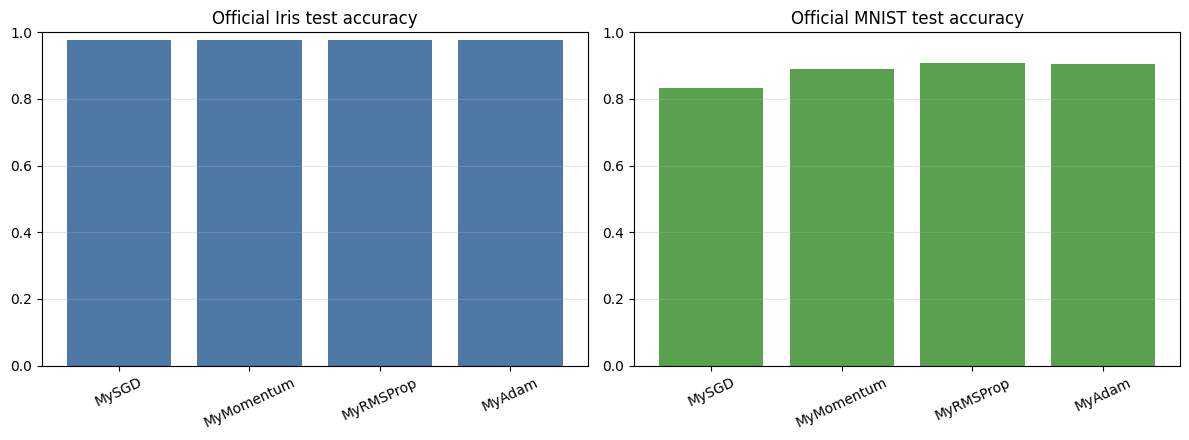

In [28]:
# [INSERTED] Final research conclusion board
# [주석 보강 | inserted-code boundary]
# 이 code cell은 원본 homework 공식 채점 흐름을 대체하지 않는 extension-only 분석/시각화 코드다.
# 원본 Part의 변수와 충돌을 줄이기 위해 *_ext / diag_* / audit_* 계열 이름을 우선 사용한다.
# 읽는 순서: 입력 데이터 또는 이전 결과 확인 -> 보조 지표 계산 -> 시각화/CSV 저장 -> 관찰/원인/제한/결론 해석으로 연결한다.
# Optimizer는 X/y를 직접 보지 않는다. layer가 만든 param/grad를 읽고 update rule에 따라 parameter만 이동한다.

from pathlib import Path
import pandas as pd
import json

artifact_root_ext = Path("artifacts")
fig_dir_ext = artifact_root_ext / "figures"
csv_dir_ext = artifact_root_ext / "csv"
config_dir_ext = artifact_root_ext / "configs"
for _d_ext in [fig_dir_ext, csv_dir_ext, config_dir_ext]:
    _d_ext.mkdir(parents=True, exist_ok=True)

official_iris_summary_ext = pd.DataFrame([
    {"optimizer": name_ext, "final_loss": float(losses_ext[-1]), "test_acc": float(acc_ext)}
    for name_ext, (losses_ext, acc_ext) in results.items()
])
official_mnist_summary_ext = pd.DataFrame([
    {"optimizer": name_ext, "final_loss": float(losses_ext[-1]), "test_acc": float(acc_ext)}
    for name_ext, (losses_ext, acc_ext) in mnist_results.items()
])
official_iris_summary_ext.to_csv(csv_dir_ext / "official_iris_summary.csv", index=False)
official_mnist_summary_ext.to_csv(csv_dir_ext / "official_mnist_summary.csv", index=False)
display(official_iris_summary_ext)
display(official_mnist_summary_ext)

iris_best_acc_ext = official_iris_summary_ext["test_acc"].max()
iris_acc_tie_ext = official_iris_summary_ext[official_iris_summary_ext["test_acc"] == iris_best_acc_ext]["optimizer"].tolist()
iris_lowest_loss_optimizer_ext = official_iris_summary_ext.sort_values("final_loss").iloc[0]["optimizer"]
mnist_best_acc_optimizer_ext = official_mnist_summary_ext.sort_values(["test_acc", "final_loss"], ascending=[False, True]).iloc[0]["optimizer"]
mnist_lowest_loss_optimizer_ext = official_mnist_summary_ext.sort_values("final_loss").iloc[0]["optimizer"]

final_conclusion_board_ext = pd.DataFrame([
    ["official Iris", f"test accuracy tie at {iris_best_acc_ext:.3f}: {', '.join(iris_acc_tie_ext)}; lowest loss={iris_lowest_loss_optimizer_ext}", "accuracy is saturated, so do not call the first sorted row the real best"],
    ["official MNIST", f"test accuracy best={mnist_best_acc_optimizer_ext}; lowest final loss={mnist_lowest_loss_optimizer_ext}", "RMSProp and Adam are close; report both accuracy and loss"],
    ["LR sensitivity", lr_summary_ext.sort_values("sensitivity_range").iloc[0]["optimizer"], "smaller range means less sensitive in this grid"],
    ["split-before-fit", "train-only fit for research", "official Part 2 kept all-fit scaler because homework specified it"],
    ["V01.2 preprocessing audit", "quality/correlation/Cramer/PCA + validation-test protocol", "extension-only evidence that fit scope changes coordinates and model-selection ethics"],
    ["diagnostics", "confusion/CE-margin/gradient audit", "extension-only evidence, not replacement for scoring"],
    ["V04 optimizer dynamics", "trajectory/update/state dashboard", "same gradient can produce different paths because optimizer state changes updates"],
    ["Early virtual 3D contour", "3D parameter path + contour slices + evaluation table", "front-loads optimizer geometry before Iris/MNIST official comparisons"],
    ["V05 gradient flow", "validation-only dW/db and update audit", "test_used=False; explains loss/metric curve causes without replacing official results"],
    ["Dense2 ReLU placement", "raw logits vs output ReLU ablation", "output activation can change CE score geometry even when accuracy is similar"],
    ["Scoped plot policy", "zoomed bars and quantile boxplots", "differences are clearer, but titles/cautions must say scoped or zoomed"],
], columns=["evidence area", "summary", "interpretation"])
display(final_conclusion_board_ext)
final_conclusion_board_ext.to_csv(csv_dir_ext / "final_research_conclusion_board.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(official_iris_summary_ext["optimizer"], official_iris_summary_ext["test_acc"], color="#4e79a7")
axes[0].set_title("Official Iris test accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar(official_mnist_summary_ext["optimizer"], official_mnist_summary_ext["test_acc"], color="#59a14f")
axes[1].set_title("Official MNIST test accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir_ext / "final_official_result_summary.png", dpi=160)
plt.show()

run_config_ext = {
    "ssot_source": "week13_homework (1).ipynb",
    "output_notebook": "ML_W13_HOMEWORK_SSOT_INSERTED.ipynb",
    "official_parts_preserved": True,
    "inserted_cells_are_extension_only": True,
    "mnist_subset_train": 8000,
    "mnist_subset_test": 2000,
    "submission_ready_notebook": "ML_W13_HOMEWORK_SUBMISSION_READY.ipynb",
    "submission_ready_policy": "Original homework flow first; inserted extensions remain in Appendix.",
    "part5_answers_finalized": True,
    "official_protocol_note_promoted": True,
    "official_problem_design_summary_promoted": True,
    "official_iris_tie_handled": True,
}
_ = (config_dir_ext / "ssot_inserted_config.json").write_text(json.dumps(run_config_ext, ensure_ascii=False, indent=2), encoding="utf-8")
